### Simulate ECGs

### imports

In [1]:
!pip install pydicom
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.1/693.1 kB 45.6 MB/s eta 0:00:00


In [2]:
from glob import glob
from sklearn.model_selection import GroupKFold, StratifiedKFold
import cv2
from skimage import io
import torch
from torch import nn
import os
from datetime import datetime
import time
import random
import cv2
import torchvision
from torchvision import transforms
import pandas as pd
import numpy as np
from tqdm import tqdm
from IPython.display import display

import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
from torch.utils.data.sampler import SequentialSampler, RandomSampler
from torch.cuda.amp import autocast, GradScaler
from torch.nn.modules.loss import _WeightedLoss
import torch.nn.functional as F

import sklearn
import warnings
import joblib
from sklearn.metrics import roc_auc_score, log_loss
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings; warnings.filterwarnings('ignore')
import cv2
import pydicom
from scipy.ndimage.interpolation import zoom

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
import numpy as np, pandas as pd, neurokit2 as nk, scipy.signal as sps

from pylab import rcParams
rcParams['figure.figsize'] = 20,5

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
import os
from sklearn.metrics import roc_auc_score
import gc
from sklearn.metrics.pairwise import rbf_kernel


In [3]:
import kagglehub
dataset_path = kagglehub.dataset_download('khyeh0719/ptb-xl-dataset')
dataset_reformatted_path = kagglehub.dataset_download('khyeh0719/ptb-xl-dataset-reformatted')

In [4]:
# Set up device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Preprocessing and ECG Simulation

### Utils

In [5]:
def set_random_seed(seed: int) -> None:
    """Set random seed for reproducibility.

    Args:
        seed: Random seed value
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

In [6]:
class ECGDataPreprocessor:
    """Handles preprocessing of ECG signals and metadata."""

    def __init__(self):
        self.superclass_cols = None
        self.subclass_cols = None
        self.numerical_cols = None
        self.numerical_means = None
        self.scaler = None
        self.categorical_cols = None
        self.label_encoders = None

    def save(self, filename):
        """Save preprocessing parameters to file."""
        data = {
            'superclass_cols': self.superclass_cols,
            'subclass_cols': self.subclass_cols,
            'numerical_cols': self.numerical_cols,
            'numerical_means': self.numerical_means,
            'scaler': self.scaler,
            'categorical_cols': self.categorical_cols,
            'label_encoders': self.label_encoders,
        }
        pd.to_pickle(data, filename)

    def load(self, filename):
        """Load preprocessing parameters from file."""
        data = pd.read_pickle(filename)
        self.superclass_cols = data['superclass_cols']
        self.subclass_cols = data['subclass_cols']
        self.numerical_cols = data['numerical_cols']
        self.numerical_means = data['numerical_means']
        self.scaler = data['scaler']
        self.categorical_cols = data['categorical_cols']
        self.label_encoders = data['label_encoders']

    def fit(self, signals, metadata):
        """Fit preprocessing parameters on training data."""
        signals = signals.copy()
        metadata = metadata.copy()

        self.superclass_cols = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
        self.subclass_cols = [col for col in metadata.columns if 'sub_' in col]

        self.numerical_cols = ['age', 'height', 'weight']
        self.numerical_means = []
        for col in self.numerical_cols:
            metadata[col] = metadata[col].fillna(metadata[col].mean())
            self.numerical_means.append(metadata[col].mean())

        self.scaler = MinMaxScaler().fit(metadata[self.numerical_cols])

        self.categorical_cols = ['sex']
        self.label_encoders = [
            LabelEncoder().fit(metadata[col].fillna('none').astype(str))
            for col in self.categorical_cols
        ]
        return self

    def transform(self, signals, metadata, length=1000):
        """Transform data using fitted parameters."""
        channel_cols = signals.columns.tolist()[1:]
        signals = signals[channel_cols].values.reshape(-1, length, 12)

        metadata = metadata.copy()

        for i, col in enumerate(self.numerical_cols):
            metadata[col] = metadata[col].fillna(self.numerical_means[i])
        metadata[self.numerical_cols] = self.scaler.transform(metadata[self.numerical_cols])
        metadata[self.numerical_cols] = np.clip(metadata[self.numerical_cols], 0., 1.)

        for i, col in enumerate(self.categorical_cols):
            metadata[col] = metadata[col].fillna('none').astype(str)
            metadata[col] = self.label_encoders[i].transform(metadata[col])

        superclass_labels = None
        subclass_labels = None

        if np.isin(self.superclass_cols, metadata.columns).sum() == len(self.superclass_cols):
            superclass_labels = metadata[self.superclass_cols].fillna(0).astype(int)

        if np.isin(self.subclass_cols, metadata.columns).sum() == len(self.subclass_cols):
            subclass_labels = metadata[self.subclass_cols].fillna(0).astype(int)

        return signals, metadata[self.numerical_cols], metadata[self.categorical_cols], superclass_labels, subclass_labels


In [7]:
class ECGDataset(Dataset):
    """Dataset class for ECG signals and metadata."""

    def __init__(self, signals: np.ndarray, numerical_features: np.ndarray,
                 categorical_features: np.ndarray, superclass_labels: np.ndarray = None,
                 subclass_labels: np.ndarray = None):
        """Initialize the dataset.

        Args:
            signals: ECG signal data of shape (n_samples, n_channels, n_timesteps)
            numerical_features: Numerical metadata features
            categorical_features: Categorical metadata features
            superclass_labels: Superclass labels (optional)
            subclass_labels: Subclass labels (optional)
        """
        self.signals = signals
        self.numerical_features = numerical_features
        self.categorical_features = categorical_features
        self.superclass_labels = superclass_labels
        self.subclass_labels = subclass_labels

    def __len__(self) -> int:
        """Return the number of samples in the dataset."""
        return self.signals.shape[0]

    def __getitem__(self, idx: int) -> list:
        """Get a single sample from the dataset.

        Args:
            idx: Index of the sample to retrieve

        Returns:
            List containing signal, numerical features, categorical features, and labels
        """
        signal = torch.tensor(self.signals[idx], dtype=torch.float32)
        num    = torch.tensor(self.numerical_features.iloc[idx].values, dtype=torch.float32)
        cat    = torch.tensor(self.categorical_features.iloc[idx].values, dtype=torch.long)

        sample = [signal, num, cat]
        if self.superclass_labels is not None:
            sup = torch.tensor(self.superclass_labels.iloc[idx].values, dtype=torch.float32)
            sample.append(sup)
        if self.subclass_labels is not None:
            sub = torch.tensor(self.subclass_labels.iloc[idx].values, dtype=torch.float32)
            sample.append(sub)
        return sample

In [8]:

def create_dataloader(signals: np.ndarray, numerical_features: np.ndarray,
                     categorical_features: np.ndarray, superclass_labels: np.ndarray,
                     subclass_labels: np.ndarray, batch_size: int = 128) -> DataLoader:
    """Create a DataLoader for training or validation.

    Args:
        signals: ECG signal data
        numerical_features: Numerical metadata features
        categorical_features: Categorical metadata features
        superclass_labels: Superclass labels
        subclass_labels: Subclass labels
        batch_size: Batch size for the DataLoader

    Returns:
        DataLoader instance
    """
    dataset = ECGDataset(
        signals, numerical_features, categorical_features,
        superclass_labels, subclass_labels
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        pin_memory=False,
        drop_last=False,
        shuffle=True,
        num_workers=4
    )

In [9]:

def plot_confusion_matrices(predictions, targets, preprocessor, save_path=None):
    """Plot confusion matrices for all classes.

    Args:
        predictions: Model predictions
        targets: True labels
        preprocessor: The data preprocessor instance
        save_path: Path to save the plot (optional)
    """
    binary_predictions = (predictions >= 0.5).astype(int)

    class_names = list(preprocessor.superclass_cols) + list(preprocessor.subclass_cols)

    n_rows = int(np.ceil(len(class_names)/4))
    fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
    axes = axes.flatten()

    for i, (class_name, ax) in enumerate(zip(class_names, axes)):
        cm = confusion_matrix(targets[:, i], binary_predictions[:, i])
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        f1 = f1_score(targets[:, i], binary_predictions[:, i])

        im = ax.imshow(cm, cmap=plt.cm.Blues)
        ax.set_title(f'{class_name}\nF1 score = {f1:.4f}')
        ax.set_ylabel('True label')
        ax.set_xlabel('Predicted label')

        for i in range(cm.shape[1]):
            for j in range(cm.shape[0]):
                ax.text(j, i, format(cm[i, j], '.2f'),
                       horizontalalignment="center",
                       color="black")

    for i in range(len(class_names), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

    plt.close()

In [10]:
import scipy.signal as sps

def estimate_noise_psd(signals, lead=1, fs=100, nperseg=256):
    # signals: array of shape (n_traces, n_samples, n_leads)
    psds = []
    for trace in signals:
        f, pxx = sps.welch(trace[:, lead], fs=fs, nperseg=nperseg)
        psds.append(pxx)
    return f, np.mean(psds, axis=0)

In [11]:
from joblib import Parallel, delayed
import multiprocessing as mp
import numpy as np, pandas as pd, neurokit2 as nk

SF, SECONDS, LENGTH = 100, 10, 1000
n_cpu = max(1, mp.cpu_count() - 1)

import numpy as np
import neurokit2 as nk

def generate_batch(label, n=50, sub_batch_size=10):
    # print(f"Generating {n} {label} traces in sub-batches of {sub_batch_size}...")
    all_sigs = []
    all_metas = []

    num_sub_batches = (n + sub_batch_size - 1) // sub_batch_size

    for i in range(num_sub_batches):
        current_batch_size = min(sub_batch_size, n - len(all_sigs))
        if current_batch_size <= 0:
            break

        # print(f"  Generating sub-batch {i+1}/{num_sub_batches} (size {current_batch_size})...")
        num_jobs = max(1, n_cpu // 2)
        # print(f"    Using n_jobs={num_jobs}")
        results = Parallel(n_jobs=num_jobs, backend='multiprocessing')(
            delayed(one_trace)(label) for _ in range(current_batch_size))

        sigs, metas = zip(*results)
        all_sigs.extend(sigs)
        all_metas.extend(metas)
        print(f"  Sub-batch {i+1} done. Total generated: {len(all_sigs)}")

    if not all_sigs:
         return np.empty((0, LENGTH, 12)), pd.DataFrame()

    return np.stack(all_sigs), pd.DataFrame(all_metas)


In [12]:
SF          = 100
SECONDS     = 10
LEADS       = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
IDX         = {l:i for i,l in enumerate(LEADS)}

REAL_STATS = {
    "NORM": {"hr_mean":70.82,"hr_std":9.81,"r_amp_mean":0.735,"r_amp_std":0.315,
             "qrs_mean":32.28,"qrs_std":4.87},
    "MI"  : {"hr_mean":76.49,"hr_std":12.12,"r_amp_mean":0.471,"r_amp_std":0.344,
             "qrs_mean":35.71,"qrs_std":8.79},
}

PATHO = {
    "anterior":{"ST":2.0,"Q":1.0,"T":1.0,"decay":.5,
                "elev":["V2","V3","V4","V5"],"recip":["II","III","aVF"],
                "q":["V1","V2"],"tinv":["V2","V3"]},
    "inferior":{"ST":1.5,"Q":0.8,"T":0.6,"decay":.6,
                "elev":["II","III","aVF"],"recip":["V1","V2","aVL"],
                "q":["II","III"],"tinv":["III","aVF"]},
    "lateral" :{"ST":1.2,"Q":0.6,"T":0.8,"decay":.7,
                "elev":["I","aVL","V5","V6"],"recip":["III","aVF"],
                "q":["I","aVL"],"tinv":["I","aVL"]},
}

LOW, HIGH = 20, 45
bp_b, bp_a = sps.butter(4, [LOW/(SF/2), HIGH/(SF/2)], btype="band")

def _apply_mi_morphology(arr, r_peaks, terr, acute=True):
    """lead‑aware ST/Q/T manipulation (vectorised)"""
    spec = PATHO[terr]
    ST  = 0.1*spec["ST"]*(1 if acute else spec["decay"])
    Qd  = 0.1*spec["Q"] *(1 if acute else spec["decay"])
    Td  = 0.1*spec["T"] *(1 if acute else spec["decay"])
    T   = arr.shape[0]

    for rp in r_peaks:
        st0, st1 = max(0, rp+8),  min(T, rp+12)       # 80‑120 ms
        q0,  q1  = max(0, rp-3),  max(0, rp-1)        # 10‑30 ms pre‑R
        t0,  t1  = max(0, rp+15), min(T, rp+30)       # 150‑300 ms

        for ld in spec["elev"]:  arr[st0:st1, IDX[ld]] +=  ST
        for ld in spec["recip"]: arr[st0:st1, IDX[ld]] -= 0.6*ST
        for ld in spec["q"]    : arr[q0:q1,  IDX[ld]] -=  Qd
        for ld in spec["tinv"] : arr[t0:t1,  IDX[ld]] -=  Td


def _find_peaks_any(ecg_arr):
    """Try Lead II first; if <2 peaks fall back to V2."""
    sig = ecg_arr[:, IDX["II"]]
    try:
        _, info = nk.ecg_peaks(sig, sampling_rate=SF, method="neurokit")
        peaks = info["ECG_R_Peaks"]
        if len(peaks) >= 2:
            return peaks
    except:
        pass
    # fallback to V2
    sig = ecg_arr[:, IDX["V2"]]
    try:
        _, info = nk.ecg_peaks(sig, sampling_rate=SF, method="neurokit")
        return info["ECG_R_Peaks"]
    except:
        return np.array([])



### Loading the Real ECGs

In [13]:

# load data
data_dir = dataset_reformatted_path
train_metadata = pd.read_csv(os.path.join(data_dir, 'train_meta.csv'), index_col=0)
train_signals = pd.read_csv(os.path.join(data_dir, 'train_signal.csv'))

valid_metadata = pd.read_csv(os.path.join(data_dir, 'valid_meta.csv'), index_col=0)
valid_signals = pd.read_csv(os.path.join(data_dir, 'valid_signal.csv'))

test_metadata = pd.read_csv(os.path.join(data_dir, 'test_meta.csv'), index_col=0)
test_signals = pd.read_csv(os.path.join(data_dir, 'test_signal.csv'))


preprocessor = ECGDataPreprocessor()
preprocessor.fit(train_signals, train_metadata)

train_signals, train_numerical, train_categorical, train_superclass, train_subclass = preprocessor.transform(train_signals, train_metadata)
valid_signals, valid_numerical, valid_categorical, valid_superclass, valid_subclass = preprocessor.transform(valid_signals, valid_metadata)
test_signals, test_numerical, test_categorical, test_superclass, test_subclass = preprocessor.transform(test_signals, test_metadata)
preprocessor.save('ecg_preprocessor.pkl')

In [14]:
SF    = 100
LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
lead_to_idx = {l:i for i,l in enumerate(LEADS)}

def compute_ecg_stats_batch(signals, sf=100, lead="II", max_records=None):
    """
    signals:    ndarray, (N, T, 12)
    sf:         sampling rate
    lead:       which lead to measure on
    max_records: cap number of signals to speed up
    """
    idx = lead_to_idx[lead]
    rr_list, amp_list, qrs_list = [], [], []
    N = signals.shape[0]
    picks = np.arange(N) if max_records is None else np.random.choice(N, max_records, replace=False)

    for i in picks:
        sig = signals[i,:,idx]
        try:
            _, info = nk.ecg_peaks(sig, sampling_rate=sf)
            peaks = info["ECG_R_Peaks"]
        except:
            continue
        if len(peaks)<2:
            continue

        rr_list.extend(np.diff(peaks)/sf)
        amps = sig[peaks]
        amp_list.extend(amps)

        window = int(0.05*sf)
        for rp, amp in zip(peaks, amps):
            thr = amp*0.5
            left, right = max(0, rp-window), min(len(sig)-1, rp+window)
            l_idxs = np.where(sig[left:rp] < thr)[0]
            r_idxs = np.where(sig[rp:right] < thr)[0]
            l_cross = left + l_idxs[-1] if l_idxs.size else rp
            r_cross = rp + r_idxs[0]     if r_idxs.size else rp
            w = (r_cross - l_cross)/sf*1000
            if 20 < w < 150:
                qrs_list.append(w)

    rr_arr, amp_arr, qrs_arr = map(np.array, (rr_list, amp_list, qrs_list))
    return {
        "hr_mean":    60/rr_arr.mean() if rr_arr.size else np.nan,
        "hr_std":     60*rr_arr.std()  if rr_arr.size else np.nan,
        "r_amp_mean": amp_arr.mean()   if amp_arr.size else np.nan,
        "r_amp_std":  amp_arr.std()    if amp_arr.size else np.nan,
        "qrs_mean":   qrs_arr.mean()   if qrs_arr.size else np.nan,
        "qrs_std":    qrs_arr.std()    if qrs_arr.size else np.nan,
    }

def class_stats(signals, sup_df, sf=SF, lead="II"):
    lbl = sup_df.values if hasattr(sup_df, "values") else sup_df
    norm_i = np.where((lbl[:,0]==1)&(lbl[:,1]==0))[0]
    mi_i   = np.where( lbl[:,1]==1)[0]
    stats_norm = compute_ecg_stats_batch(signals[norm_i], sf, lead)
    stats_mi   = compute_ecg_stats_batch(signals[mi_i],  sf, lead)
    return stats_norm, stats_mi

real_sup = train_superclass if isinstance(train_superclass, pd.DataFrame) \
           else pd.DataFrame(train_superclass, columns=["NORM","MI","STTC","CD","HYP"])
stats_real_norm, stats_real_mi = class_stats(train_signals, real_sup)

print("\n=====ECG stats=====")
print("Healthy:")
for k,v in stats_real_norm.items(): print(f"  {k:12s}: {v:.3f}")
print("MI:")
for k,v in stats_real_mi.items():   print(f"  {k:12s}: {v:.3f}")



=====ECG stats=====
Healthy:
  hr_mean     : 70.820
  hr_std      : 9.814
  r_amp_mean  : 0.722
  r_amp_std   : 0.329
  qrs_mean    : 32.141
  qrs_std     : 5.091
MI:
  hr_mean     : 76.485
  hr_std      : 12.115
  r_amp_mean  : 0.448
  r_amp_std   : 0.326
  qrs_mean    : 35.555
  qrs_std     : 8.843


In [15]:
REAL_STATS = {
    "NORM": {
        "hr_mean":   70.820,    "hr_std":   9.814,
        "r_amp_mean":0.735,     "r_amp_std":0.315,
        "qrs_mean": 32.282,     "qrs_std":  4.868,
    },
    "MI": {
        "hr_mean":   76.485,    "hr_std":  12.115,
        "r_amp_mean":0.471,     "r_amp_std":0.344,
        "qrs_mean": 35.713,     "qrs_std":  8.786,
    }
}

### Synthetic 12‑Lead ECG Generator

This function generates a synthetic 12-lead ECG trace with realistic morphology and class-specific artifacts for either **normal (NORM)** or **myocardial infarction (MI)** cases. It builds on NeuroKit2’s `ecg_simulate` engine and enhances the base signal with layered physiological realism and pathology-aware distortions.

#### Morphology Construction
- Each ECG beat is modeled using Gaussian waveforms for the P, Q, R, S, and T waves.
- The timing (`ti`), amplitude (`ai`), and width (`bi`) of these waves are sampled from normal distributions parameterized by real patient statistics (`REAL_STATS`).
- R-wave amplitude and QRS duration are explicitly drawn from class-specific distributions (NORM or MI).

#### MI-Specific Modifications
When the label is `"MI"`, additional infarction-relevant features are introduced:
- **Deeper Q-waves** and **inverted/skewed T-waves**
- **Sharpened and irregular R-peaks**
- **Broader or narrowed wave durations**
- **Beat-to-beat amplitude jitter** and **timing asymmetry** (simulated by shifting wave segments per lead)
- **ST-segment elevation**, voltage spikes, and occasional **R-peak suppression**
- **Irregular RR intervals** to simulate rhythm instability

#### Signal-Level Artifacts
The signal is further enriched with:
- **Baseline wander** (0.3 Hz sinusoid, simulating breathing)
- **Mains hum** (50/60 Hz sinusoid based on sampling rate)
- **Muscle noise (EMG)**: bandpass-filtered Gaussian noise (20–45 Hz) with stronger intensity for MI cases
- **Random transient distortions** injected near R-peaks for MI traces

#### Fade-In Smoothing
To avoid artificial signal onset artifacts:
- A fade-in ramp is applied over the first 1–2 seconds (`fade_len`).
- For NORM signals, a **nonlinear power ramp** ensures a smooth increase in amplitude.
- For MI signals, the fade is randomized to preserve clinical variability.

#### Final Processing
- Each lead is **recentered to zero median**.
- The signal is scaled to match clinical voltage ranges (typically 0–2 mV).
- The function returns both:
  - `ecg_values`: a 2D NumPy array (`[timesteps, 12]`)
  - `metadata`: a dictionary containing age, sex, height, weight, and binary diagnostic labels (`NORM`, `MI`, `STTC`, `CD`, `HYP`)

This generator is ideal for producing **pretraining data** for generative or discriminative ECG models, enabling the creation of physiologically grounded, diverse, and diagnosis-specific synthetic datasets.


In [16]:
SF = 100
SECONDS = 10
LENGTH  = SF * SECONDS
SEX_CATEGORIES = preprocessor.label_encoders[0].classes_

LOW_FREQ, HIGH_FREQ = 20, 45
bp_b, bp_a = sps.butter(
    N=4,
    Wn=[LOW_FREQ/(SF/2), HIGH_FREQ/(SF/2)],
    btype="bandpass"
)


REAL_META_MEANS = train_numerical.mean().to_dict()
REAL_META_STDS  = train_numerical.std().to_dict()

real_sex_probs = train_categorical['sex'].value_counts(normalize=True).sort_index().values
SEX_CATEGORIES  = preprocessor.label_encoders[0].classes_

def one_trace(label: str):
    """
    Generate a synthetic 12-lead ECG trace with realistic morphology and artifacts.

    Args:
        label (str): Either "MI" (myocardial infarction) or "NORM" (normal)

    Returns:
        tuple: (ecg_values, metadata)
            - ecg_values: 12-lead ECG data as numpy array
            - metadata: Dictionary containing demographic and diagnostic information
    """

    ti = np.random.normal([-70, -15, 0, 15, 100], 3)

    ai = np.random.normal([1.2, -5, 30, -7.5, 0.75],
                         [0.24, 1.0, 6.0, 1.5, 0.15])
    ai[2] = np.random.normal(
        REAL_STATS[label]["r_amp_mean"],
        REAL_STATS[label]["r_amp_std"]
    )

    bi = np.random.normal([0.25, 0.10, 0.10, 0.10, 0.40],
                         [0.05]*5)
    bi[2] = np.random.normal(
        REAL_STATS[label]["qrs_mean"]/1000,
        REAL_STATS[label]["qrs_std"]/1000
    )

    if label == "MI":
        ai[1] *= np.random.uniform(2.0, 4.0)
        ai[4] *= -np.random.uniform(1.0, 4.0)
        bi += np.random.uniform(0.05, 0.20, size=5)

        ai[2] *= np.random.uniform(1.2, 1.5)
        bi[2] *= np.random.uniform(0.7, 0.9)

        bi *= np.random.uniform(0.6, 0.8, size=5)
        ai *= np.random.uniform(1.5, 2)
        beat_variations = np.random.uniform(0.5, 2.5, size=5)
        ai *= beat_variations

    else:
        bi *= np.random.uniform(0.75, 0.9, size=5)
    stats = REAL_STATS[label]
    hr = float(np.clip(
        np.random.normal(stats["hr_mean"], stats["hr_std"]),
        stats["hr_mean"] - 1.5*stats["hr_std"],
        stats["hr_mean"] + 1.5*stats["hr_std"]
    ))
    hr = float(np.clip(hr,
                40 if label=="NORM" else 50,
                180 if label=="NORM" else 150))
    rr_mean = 60.0 / hr
    rr_std  = rr_mean * (stats["hr_std"] / stats["hr_mean"])

    if label == "MI":
      ecg = nk.ecg_simulate(
        duration=SECONDS,
        sampling_rate=SF,
        method="multileads",
        ti=ti, ai=ai, bi=bi,
        heart_rate=hr, heart_rate_std=rr_std,
        lfhfratio=0.8,
        noise=0.035
      )
    else:
            ecg = nk.ecg_simulate(
        duration=SECONDS,
        sampling_rate=SF,
        method="multileads",
        ti=ti, ai=ai, bi=bi,
        heart_rate=hr, heart_rate_std=rr_std,
        lfhfratio=0.8,
        noise=0.015
      )


    t = np.arange(len(ecg)) / SF
    ecg += 0.05 * np.sin(2*np.pi*0.3*t)[:,None]

    fade_len = SF * 2
    if label == "MI":
        start_amp = np.random.uniform(0.7, 1.2)
        end_amp   = np.random.uniform(0.9, 1.2)
        fade = np.linspace(start_amp, end_amp, fade_len)[:, None]

    else:
        start_amp = 0.1
        end_amp   = 1.0
        fade_curve = np.linspace(0, 1, fade_len)
        fade_shape = np.power(fade_curve, 1.2)
        fade = (start_amp + (end_amp - start_amp) * fade_shape)[:, None]




    ecg.iloc[:fade_len] *= fade
    if label == "MI":
        _, rpeaks = nk.ecg_peaks(ecg.values[:, 1], sampling_rate=SF)
        peaks = rpeaks["ECG_R_Peaks"]

        for i, pk in enumerate(peaks):
            amp_factor = np.random.uniform(0.7, 1.3)
            window = slice(max(0, pk - 30), min(len(ecg), pk + 50))
            ecg.iloc[window] *= amp_factor

            jitter = np.random.randint(-4, 4)
            for lead in np.random.choice(ecg.columns, size=6, replace=False):
                lead_data = ecg[lead].values
                seg = lead_data[window]
                if len(seg) > abs(jitter):
                    if jitter > 0:
                        lead_data[window] = np.pad(seg[jitter:], (0, jitter), mode='constant')
                    elif jitter < 0:
                        lead_data[window] = np.pad(seg[:jitter], (-jitter, 0), mode='constant')
                    ecg[lead] = lead_data

        for lead in np.random.choice(ecg.columns, size=4, replace=False):
            ecg[lead] += 0.01 * np.random.randn(len(ecg))





        _, rpeaks = nk.ecg_peaks(ecg.values[:,1], sampling_rate=SF)
        for pk in rpeaks["ECG_R_Peaks"]:
            st_start = pk + int(0.02 * SF)
            st_end   = pk + int(0.10 * SF)
            if st_end < len(ecg):
                ecg.iloc[st_start:st_end] += np.random.uniform(0.1, 0.3)

        t_idx = 4
        bi[t_idx] *= np.random.uniform(1.1, 1.4)

        for _ in range(3):
            size = np.random.randint(3, 8)
            pos  = np.random.randint(0, len(ecg) - size)
            lead = np.random.choice(ecg.columns)
            window = slice(pos, pos + size)
            spike  = np.hanning(size) * np.random.uniform(0.5, 1.0)
            ecg.iloc[window, ecg.columns.get_loc(lead)] += spike







    ecg *= np.random.normal(1.0, 0.025, size=12)
    hum = 50 if SF%50==0 else 60
    ecg += 0.02 * np.sin(2*np.pi*hum*t)[:,None]

    if label == "MI":
        muscle = np.random.normal(scale=np.random.uniform(0.06, 0.11), size=ecg.shape)
    else:
        muscle = np.random.normal(scale=np.random.uniform(0.02, 0.045), size=ecg.shape)
    muscle = sps.filtfilt(bp_b, bp_a, muscle, axis=0)
    ecg += muscle

    if label == "MI":
        _, rpeaks = nk.ecg_peaks(ecg.values[:,1], sampling_rate=SF)
        peaks = rpeaks["ECG_R_Peaks"]

        for pk in np.random.choice(peaks, size=min(3, len(peaks)), replace=False):
            width = int(0.05 * SF)
            start = max(0, pk - width//2)
            end = min(len(ecg), pk + width//2)
            shape = np.hanning(end-start) * np.random.uniform(0.2, 0.5)
            ecg.values[start:end] += shape[:,None]

        if len(peaks) >= 3:
            for pk in np.random.choice(peaks, size=min(6, len(peaks)), replace=False):
                width = np.random.randint(2, 5)
                amp   = np.random.uniform(0.8, 1.4) * np.sign(np.random.randn())
                leads = np.random.choice(ecg.columns, size=5, replace=False)

                for lead in leads:
                    start = pk
                    end = min(len(ecg), pk + width)
                    segment_len = end - start

                    if segment_len < 2:
                        continue

                    spike = np.hanning(segment_len) * amp
                    target = ecg.loc[start:end, lead].values

                    if len(target) == len(spike):
                        ecg.loc[start:end, lead] = target + spike




        for _ in range(4):
            center = np.random.randint(SF, len(ecg)-SF)
            shift  = np.random.randint(-6, 6)
            for lead in ecg.columns:
                orig = ecg[lead].values
                warp = np.roll(orig, shift)
                mix = np.random.beta(1.2, 1.2)
                segment = slice(center - SF//2, center + SF//2)
                if segment.stop < len(ecg):
                    ecg[lead].values[segment] = (
                        mix * orig[segment] + (1 - mix) * warp[segment]
                    )

        drop_chance = 0.4
        for pk in peaks:
            if np.random.rand() < drop_chance:
                leads = np.random.choice(ecg.columns, size=4, replace=False)
                for lead in leads:
                    window = slice(max(0, pk-2), min(len(ecg), pk+2))
                    ecg.loc[window, lead] *= np.random.uniform(0.2, 0.5)


    ecg = ecg.subtract(ecg.median(axis=0), axis=1)

    ecg *= 0.5


    raw_age    = np.random.normal(REAL_META_MEANS['age'],   REAL_META_STDS['age'])
    raw_height = np.random.normal(REAL_META_MEANS['height'],REAL_META_STDS['height'])
    raw_weight = np.random.normal(REAL_META_MEANS['weight'],REAL_META_STDS['weight'])

    age    = float(np.clip(raw_age,    0.0, 1.0))
    height = float(np.clip(raw_height, 0.0, 1.0))
    weight = float(np.clip(raw_weight, 0.0, 1.0))

    sex = np.random.choice(SEX_CATEGORIES, p=real_sex_probs)

    meta = {
        "age":    age,
        "height": height,
        "weight": weight,
        "sex":    sex,
        "NORM":   int(label == "NORM"),
        "MI":     int(label == "MI"),
        "STTC":   0, "CD": 0, "HYP": 0
    }

    return ecg.values.astype("float32"), meta

### Generate

balanced set

In [ ]:
print("generating NORM traces")
healthy_sig, healthy_meta = generate_batch("NORM", n=250)
gc.collect()
np.save("healthy_sig.npy", healthy_sig)
healthy_meta.to_pickle("healthy_meta.pkl")

generating NORM traces
  Sub-batch 1 done. Total generated: 10


imbalanced

In [ ]:
print("generating NORM traces")
healthy_sig, healthy_meta = generate_batch("NORM", n=600)
gc.collect()
np.save("healthy_sig.npy", healthy_sig)
healthy_meta.to_pickle("healthy_meta.pkl")

generating NORM traces
  Sub-batch 1 done. Total generated: 10
  Sub-batch 2 done. Total generated: 20
  Sub-batch 3 done. Total generated: 30
  Sub-batch 4 done. Total generated: 40
  Sub-batch 5 done. Total generated: 50
  Sub-batch 6 done. Total generated: 60
  Sub-batch 7 done. Total generated: 70
  Sub-batch 8 done. Total generated: 80
  Sub-batch 9 done. Total generated: 90
  Sub-batch 10 done. Total generated: 100
  Sub-batch 11 done. Total generated: 110
  Sub-batch 12 done. Total generated: 120
  Sub-batch 13 done. Total generated: 130
  Sub-batch 14 done. Total generated: 140
  Sub-batch 15 done. Total generated: 150
  Sub-batch 16 done. Total generated: 160
  Sub-batch 17 done. Total generated: 170
  Sub-batch 18 done. Total generated: 180
  Sub-batch 19 done. Total generated: 190
  Sub-batch 20 done. Total generated: 200
  Sub-batch 21 done. Total generated: 210
  Sub-batch 22 done. Total generated: 220
  Sub-batch 23 done. Total generated: 230
  Sub-batch 24 done. Total ge

balanced

In [ ]:
print("generating MI traces")
mi_sig, mi_meta = generate_batch("MI", n=250)
gc.collect()
np.save("mi_sig.npy", mi_sig)
mi_meta.to_pickle("mi_meta.pkl")

generating MI traces
  Sub-batch 1 done. Total generated: 10
  Sub-batch 2 done. Total generated: 20
  Sub-batch 3 done. Total generated: 30
  Sub-batch 4 done. Total generated: 40
  Sub-batch 5 done. Total generated: 50
  Sub-batch 6 done. Total generated: 60
  Sub-batch 7 done. Total generated: 70
  Sub-batch 8 done. Total generated: 80
  Sub-batch 9 done. Total generated: 90
  Sub-batch 10 done. Total generated: 100
  Sub-batch 11 done. Total generated: 110
  Sub-batch 12 done. Total generated: 120
  Sub-batch 13 done. Total generated: 130
  Sub-batch 14 done. Total generated: 140
  Sub-batch 15 done. Total generated: 150
  Sub-batch 16 done. Total generated: 160
  Sub-batch 17 done. Total generated: 170
  Sub-batch 18 done. Total generated: 180
  Sub-batch 19 done. Total generated: 190
  Sub-batch 20 done. Total generated: 200
  Sub-batch 21 done. Total generated: 210
  Sub-batch 22 done. Total generated: 220
  Sub-batch 23 done. Total generated: 230
  Sub-batch 24 done. Total gene

imabalanced

In [ ]:
print("generating MI traces")
mi_sig, mi_meta = generate_batch("MI", n=300)
gc.collect()
np.save("mi_sig.npy", mi_sig)
mi_meta.to_pickle("mi_meta.pkl")

generating MI traces
  Sub-batch 1 done. Total generated: 10
  Sub-batch 2 done. Total generated: 20
  Sub-batch 3 done. Total generated: 30
  Sub-batch 4 done. Total generated: 40
  Sub-batch 5 done. Total generated: 50
  Sub-batch 6 done. Total generated: 60
  Sub-batch 7 done. Total generated: 70
  Sub-batch 8 done. Total generated: 80
  Sub-batch 9 done. Total generated: 90
  Sub-batch 10 done. Total generated: 100
  Sub-batch 11 done. Total generated: 110
  Sub-batch 12 done. Total generated: 120
  Sub-batch 13 done. Total generated: 130
  Sub-batch 14 done. Total generated: 140
  Sub-batch 15 done. Total generated: 150
  Sub-batch 16 done. Total generated: 160
  Sub-batch 17 done. Total generated: 170
  Sub-batch 18 done. Total generated: 180
  Sub-batch 19 done. Total generated: 190
  Sub-batch 20 done. Total generated: 200
  Sub-batch 21 done. Total generated: 210
  Sub-batch 22 done. Total generated: 220
  Sub-batch 23 done. Total generated: 230
  Sub-batch 24 done. Total gene

do one of balanced or imbalanced and then run the code below

In [ ]:
healthy_sig = np.load("healthy_sig.npy")
healthy_meta = pd.read_pickle("healthy_meta.pkl")
mi_sig     = np.load("mi_sig.npy")
mi_meta    = pd.read_pickle("mi_meta.pkl")

X_syn   = np.concatenate([healthy_sig, mi_sig])
meta_syn = pd.concat([healthy_meta, mi_meta], ignore_index=True)

del healthy_sig, healthy_meta, mi_sig, mi_meta
gc.collect()

22

In [ ]:
sig_df = pd.DataFrame(
        X_syn.reshape(len(X_syn), -1),
        columns=[f"sig{i}" for i in range(1, LENGTH * 12 + 1)]
    )
sig_df.insert(0, "record_id", np.arange(len(sig_df)))

syn_X, syn_num, syn_cat, syn_sup, _ = preprocessor.transform(sig_df, meta_syn, length=LENGTH)


### save and load

In [ ]:
save_path = "synthetic_data_900_imbalanced_v3.npz"
print(f"save data to {save_path}...")
np.savez(save_path, signals=syn_X, numerical=syn_num, categorical=syn_cat, superclass=syn_sup)

save data to synthetic_data_900_imbalanced_v3.npz...


In [17]:
data = np.load("synthetic_data_900_imbalanced_v3.npz")

syn_X   = data["signals"]
syn_num = pd.DataFrame(data["numerical"],
                       columns=["age","height","weight"])
syn_cat = pd.DataFrame(data["categorical"],
                       columns=["sex"])
syn_sup = pd.DataFrame(data["superclass"],
                       columns=["NORM","MI","STTC","CD","HYP"])

print("signals:", syn_X.shape, syn_X.dtype)
print("numerical:", syn_num.shape, syn_num.dtypes.tolist())
print("categorical:", syn_cat.shape, syn_cat.dtypes.tolist())
print("superclass:", syn_sup.shape, syn_sup.sum().to_dict())


signals: (900, 1000, 12) float32
numerical: (900, 3) [dtype('float64'), dtype('float64'), dtype('float64')]
categorical: (900, 1) [dtype('int64')]
superclass: (900, 5) {'NORM': 600, 'MI': 300, 'STTC': 0, 'CD': 0, 'HYP': 0}


### Analysis Tests

In [ ]:
def compute_mmd(X_real, X_syn, gamma=None, normalize=True):
    X = X_real.reshape(X_real.shape[0], -1)
    Y = X_syn .reshape(X_syn .shape[0], -1)

    if normalize:
        mean, std = X.mean(), X.std()
        X = (X - mean) / std
        Y = (Y - mean) / std

    if gamma is None:
        idx = np.random.choice(X.shape[0], min(500, X.shape[0]), replace=False)
        D = np.sum((X[idx][:,None,:] - X[idx][None,:,:])**2, axis=2)
        median_sq = np.median(D)
        gamma = 1.0 / (2 * median_sq + 1e-8)

    # RBF kernel MMD^2
    K_XX = rbf_kernel(X, X, gamma=gamma)
    K_YY = rbf_kernel(Y, Y, gamma=gamma)
    K_XY = rbf_kernel(X, Y, gamma=gamma)

    return K_XX.mean() + K_YY.mean() - 2 * K_XY.mean()

def mmd_per_class(train_signals, train_superclass, syn_X, syn_sup):
    results = {}
    for cls_name, col in [("NORM", 0), ("MI", 1)]:
        real_mask = train_superclass[:, col] == 1
        syn_mask  = syn_sup[:, col] == 1

        X_real = train_signals[real_mask]
        X_syn  = syn_X[syn_mask]

        if len(X_syn) == 0 or len(X_real) == 0:
            results[cls_name] = np.nan
            continue

        mmd2 = compute_mmd(X_real, X_syn, normalize=False)
        results[cls_name] = mmd2

    return results

per_class_mmd2 = mmd_per_class(train_signals,
                               train_superclass.values,
                               syn_X,
                               syn_sup.values)

for cls, mmd2 in per_class_mmd2.items():
    print(f"{cls:5s} MMD^2 = {mmd2:.2e}")


NORM  MMD^2 = 9.52e-02
MI    MMD^2 = 7.30e-02


In [ ]:
real_age_mean, real_age_std = train_numerical['age'].mean(), train_numerical['age'].std()
real_height_mean, real_height_std = train_numerical['height'].mean(), train_numerical['height'].std()
real_weight_mean, real_weight_std = train_numerical['weight'].mean(), train_numerical['weight'].std()

real_sex_distribution = train_categorical['sex'].value_counts(normalize=True)


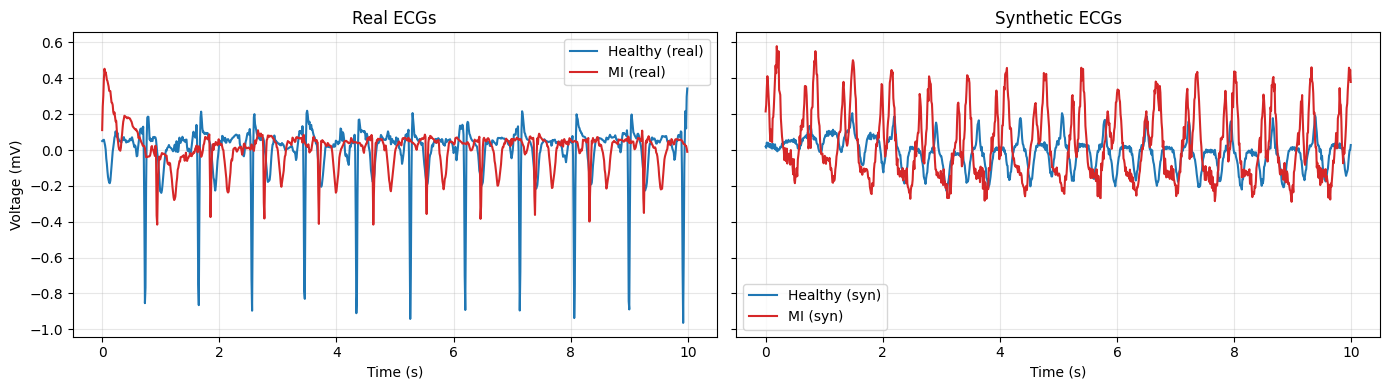

In [ ]:
real_norm_ids = np.where((train_superclass.values[:,0]==1)&(train_superclass.values[:,1]==0))[0]
real_mi_ids   = np.where(train_superclass.values[:,1]==1)[0]
syn_norm_ids  = np.where((syn_sup.values[:,0]==1)&(syn_sup.values[:,1]==0))[0]
syn_mi_ids    = np.where(syn_sup.values[:,1]==1)[0]

real_norm_idx = random.choice(real_norm_ids)
real_mi_idx   = random.choice(real_mi_ids)
syn_norm_idx  = random.choice(syn_norm_ids)
syn_mi_idx    = random.choice(syn_mi_ids)

real_norm = train_signals[real_norm_idx]
real_mi   = train_signals[real_mi_idx]
syn_norm  = syn_X[syn_norm_idx]
syn_mi    = syn_X[syn_mi_idx]

fs = 100
lead = 3   # Lead II
t = np.arange(real_norm.shape[0]) / fs

fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)

# Real
axes[0].plot(t, real_norm[:,lead], label="Healthy (real)", color="C0")
axes[0].plot(t, real_mi[:,lead],   label="MI (real)",      color="C3")
axes[0].set_title("Real ECGs")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Voltage (mV)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Synthetic
axes[1].plot(t, syn_norm[:,lead], label="Healthy (syn)", color="C0")
axes[1].plot(t, syn_mi[:,lead],   label="MI (syn)",      color="C3")
axes[1].set_title("Synthetic ECGs")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


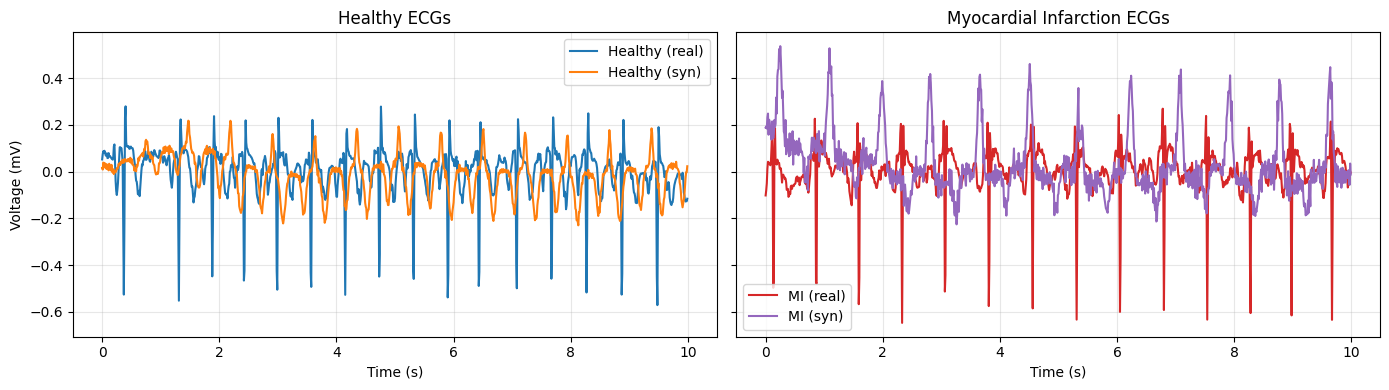

In [ ]:
real_norm_ids = np.where((train_superclass.values[:,0]==1)&(train_superclass.values[:,1]==0))[0]
real_mi_ids   = np.where(train_superclass.values[:,1]==1)[0]
syn_norm_ids  = np.where((syn_sup.values[:,0]==1)&(syn_sup.values[:,1]==0))[0]
syn_mi_ids    = np.where(syn_sup.values[:,1]==1)[0]

real_norm_idx = random.choice(real_norm_ids)
real_mi_idx   = random.choice(real_mi_ids)
syn_norm_idx  = random.choice(syn_norm_ids)
syn_mi_idx    = random.choice(syn_mi_ids)

real_norm = train_signals[real_norm_idx]
real_mi   = train_signals[real_mi_idx]
syn_norm  = syn_X[syn_norm_idx]
syn_mi    = syn_X[syn_mi_idx]

fs = 100
lead = 3   # Lead II
t = np.arange(real_norm.shape[0]) / fs

fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)

axes[0].plot(t, real_norm[:,lead], label="Healthy (real)", color="C0")
axes[0].plot(t, syn_norm[:,lead],  label="Healthy (syn)",  color="C1")
axes[0].set_title("Healthy ECGs")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Voltage (mV)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, real_mi[:,lead], label="MI (real)", color="C3")
axes[1].plot(t, syn_mi[:,lead],  label="MI (syn)",  color="C4")
axes[1].set_title("Myocardial Infarction ECGs")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


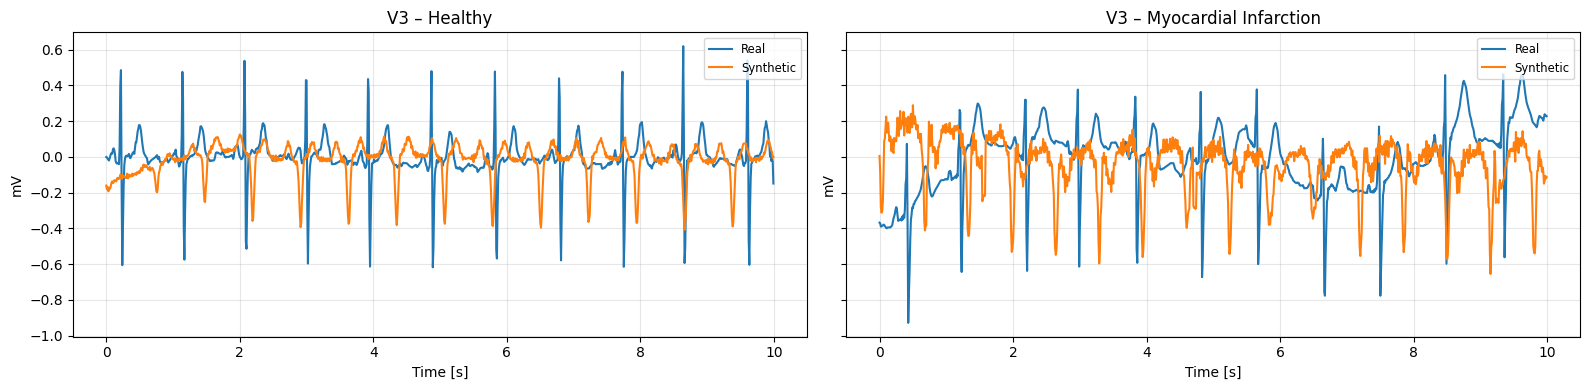

In [ ]:
from scipy.signal import find_peaks

real_norm_idx = np.where(
    (train_superclass.values[:,0] == 1) &
    (train_superclass.values[:,1] == 0)
)[0][0]

real_mi_idx = np.where(train_superclass.values[:,1] == 1)[0][0]

real_norm = train_signals[real_norm_idx]
real_mi   = train_signals[real_mi_idx]

syn_norm_idx = np.where(
    (syn_sup.values[:,0] == 1) &
    (syn_sup.values[:,1] == 0)
)[0][0]

syn_mi_idx = np.where(syn_sup.values[:,1] == 1)[0][1]

syn_norm = syn_X[syn_norm_idx]
syn_mi   = syn_X[syn_mi_idx]

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
def compute_hr_and_peaks(sig_lead, fs=100):
    """
    Detect R‑peaks in a single lead and compute heart rate.

    Args:
      sig_lead: 1D numpy array (voltage)
      fs: sampling frequency (Hz)
    Returns:
      hr: estimated heart rate (bpm)
      peaks: indices of detected peaks
    """
    thr = np.mean(sig_lead) + 0.3 * np.std(sig_lead)
    peaks, _ = find_peaks(sig_lead, height=thr, distance=fs*0.4)
    duration_min = len(sig_lead) / fs / 60.0
    hr = len(peaks) / duration_min
    return hr, peaks

def detect_peaks(sig, fs=100):
    thr = np.mean(sig) + 0.3 * np.std(sig)
    peaks, _ = find_peaks(sig, height=thr, distance=fs*0.4)
    return peaks

def match_peaks(real_peaks, syn_peaks, tol_samples=5):
    """Return (matched, real_only, syn_only) indices."""
    matched = []
    syn_used = set()
    for r in real_peaks:
        diffs = np.abs(syn_peaks - r)
        idx = np.argmin(diffs)
        if diffs[idx] <= tol_samples:
            matched.append((r, syn_peaks[idx]))
            syn_used.add(syn_peaks[idx])
    real_only = [r for r in real_peaks if r not in {m[0] for m in matched}]
    syn_only  = [s for s in syn_peaks  if s not in syn_used]
    return matched, real_only, syn_only

lead = 8
fs   = 100
t    = np.arange(real_norm.shape[0]) / fs

r_norm_peaks = detect_peaks(real_norm[:,lead], fs)
s_norm_peaks = detect_peaks(syn_norm[:,lead],  fs)
r_mi_peaks   = detect_peaks(real_mi[:,lead],   fs)
s_mi_peaks   = detect_peaks(syn_mi[:,lead],    fs)

tol = int(0.05 * fs)
m_norm, r_norm_only, s_norm_only = match_peaks(r_norm_peaks, s_norm_peaks, tol)
m_mi,   r_mi_only,   s_mi_only   = match_peaks(r_mi_peaks,   s_mi_peaks,   tol)

def plot_ticks(ax, peak_idxs, color, label, bottom=-1.0, top=1.0, alpha=0.5):
    ax.vlines(t[peak_idxs], ymin=bottom, ymax=top,
              color=color, alpha=alpha, linewidth=1, label=label)

fig, axes = plt.subplots(1, 2, figsize=(16,4), sharey=True)

for ax, real_sig, syn_sig, m, r_only, s_only, title_suffix in [
    (axes[0], real_norm, syn_norm, m_norm, r_norm_only, s_norm_only, "Healthy"),
    (axes[1], real_mi,   syn_mi,   m_mi,   r_mi_only,   s_mi_only,   "Myocardial Infarction")
]:
    ax.plot(t, real_sig[:,lead], label="Real",  color="C0")
    ax.plot(t, syn_sig[:,lead],  label="Synthetic", color="C1")

    lead_name = LEAD_NAMES[lead]
    ax.set_title(f"{lead_name} – {title_suffix}")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("mV")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize="small")

plt.tight_layout()
plt.show()

In [ ]:

from scipy.stats import ks_2samp

def compute_ks(X_norm, X_mi, lead=None):
    """
    Compute the two‑sample Kolmogorov–Smirnov statistic D between
    the 'normal' and 'MI' sets. If lead is None, flattens entire trace;
    otherwise compares R‑peak amplitudes on that lead.
    Returns the KS D statistic.
    """
    if lead is None:
        X = X_norm.reshape(X_norm.shape[0], -1)
        Y = X_mi .reshape(X_mi .shape[0], -1)
        a = X.ravel()
        b = Y.ravel()
    else:
        a = []
        for x in X_norm:
            _, info = nk.ecg_peaks(x[:,lead], sampling_rate=SF)
            a.extend(x[ info["ECG_R_Peaks"], lead ])
        b = []
        for y in X_mi:
            _, info = nk.ecg_peaks(y[:,lead], sampling_rate=SF)
            b.extend(y[ info["ECG_R_Peaks"], lead ])
        a = np.array(a)
        b = np.array(b)

    D, _ = ks_2samp(a, b, alternative='two-sided', mode='auto')
    return D

def ks_per_domain(train_signals, train_superclass, syn_X, syn_sup, lead=None):
    """
    Compute KS D for real MI vs. norm, and for synthetic MI vs. norm,
    returned in a dict keyed by ("REAL","SYNTH").
    """
    results = {"REAL": {}, "SYNTH": {}}
    real_norm = train_superclass[:,0] == 1
    real_mi   = train_superclass[:,1] == 1
    syn_norm  = syn_sup[:,0] == 1
    syn_mi    = syn_sup[:,1] == 1

    Xr = train_signals[real_norm]
    Yr = train_signals[real_mi]
    Xs = syn_X      [syn_norm]
    Ys = syn_X      [syn_mi]

    results["REAL"]["KS_D"]    = compute_ks(Xr, Yr, lead=lead)
    results["SYNTH"]["KS_D"]   = compute_ks(Xs, Ys, lead=lead)
    return results

ks_full = ks_per_domain(train_signals, train_superclass.values,
                        syn_X,         syn_sup.values,
                        lead=None)
print("Flattened‑signal KS:")
print(ks_full)



Flattened‑signal KS:
{'REAL': {'KS_D': np.float64(0.06643259034828092)}, 'SYNTH': {'KS_D': np.float64(0.21003133333333332)}}


=== KS Test.  ===
   Lead   KS_stat        p_value
0     I  0.960110   0.000000e+00
1    II  0.750192   0.000000e+00
2   III  0.251247  1.686477e-160
3   aVR  0.398599  6.279574e-321
4   aVL  0.804072   0.000000e+00
5   aVF  0.417975  1.630417e-322
6    V1  0.326792  6.625850e-212
7    V2  0.553332   0.000000e+00
8    V3  0.845083   0.000000e+00
9    V4  0.922997   0.000000e+00
10   V5  0.951363   0.000000e+00
11   V6  0.941015   0.000000e+00

=== PSD Relative Error (0.5-40 Hz) ===
   Lead  PSD_rel_error
0     I       0.706978
1    II       0.825809
2   III       0.682660
3   aVR       0.814086
4   aVL       0.658733
5   aVF       0.805256
6    V1       0.727362
7    V2       0.854877
8    V3       0.898117
9    V4       0.884308
10   V5       0.866657
11   V6       0.795551


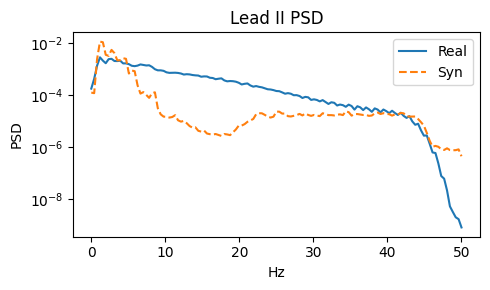

In [ ]:
N_syn = syn_X.shape[0]
idx_real = random.sample(range(train_signals.shape[0]), k=N_syn)
real_small = train_signals[idx_real]

def highpass(ecg, fs=SF):
    b, a = sps.butter(4, 0.5/(fs/2), btype="high")
    return sps.filtfilt(b, a, ecg, axis=0)

real_pp = np.stack([highpass(x, fs=SF) for x in real_small])
syn_pp  = np.stack([highpass(x, fs=SF) for x in syn_X])

LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

ks_results = []
def extract_ramps(traces, lead):
    amps = []
    for x in traces:
        _, info = nk.ecg_peaks(x[:,lead], sampling_rate=SF)
        peaks = info["ECG_R_Peaks"]
        if len(peaks) > 0:
            amps.extend(x[peaks, lead])
    return np.array(amps)

for i, lead in enumerate(LEADS):
    rv = extract_ramps(real_pp, i)
    sv = extract_ramps(syn_pp, i)
    stat, p = ks_2samp(rv, sv, alternative='two-sided', mode='auto')
    ks_results.append((lead, stat, p))
ks_df = pd.DataFrame(ks_results, columns=["Lead","KS_stat","p_value"])
print("=== KS Test.  ===")
print(ks_df)

def mean_psd(traces, lead):
    P = []
    for x in traces:
        _, Pxx = sps.welch(x[:,lead], fs=SF, nperseg=256)
        P.append(Pxx)
    return np.mean(P, axis=0)

psd_results = []
freqs = None
for i, lead in enumerate(LEADS):
    P_real = mean_psd(real_pp, i)
    P_syn  = mean_psd(syn_pp, i)
    if freqs is None:
        freqs = sps.welch(real_pp[0,:,i], fs=SF, nperseg=256)[0]
    band = (freqs >= 0.5) & (freqs <= 40)
    rel_err = np.mean(np.abs(P_real[band] - P_syn[band]) / (P_real[band] + 1e-8))
    psd_results.append((lead, rel_err))
psd_df = pd.DataFrame(psd_results, columns=["Lead","PSD_rel_error"])
print("\n=== PSD Relative Error (0.5-40 Hz) ===")
print(psd_df)

f = freqs
plt.figure(figsize=(5,3))
plt.semilogy(f, mean_psd(real_pp, 1), label="Real")
plt.semilogy(f, mean_psd(syn_pp, 1),  label="Syn", linestyle="--")
plt.title("Lead II PSD")
plt.xlabel("Hz"); plt.ylabel("PSD")
plt.legend(); plt.tight_layout(); plt.show()

def compute_hr(ecg_lead):
    bp = sps.butter(3, [5/(SF/2), 40/(SF/2)], btype="band")
    filtered = sps.filtfilt(bp[0], bp[1], ecg_lead)
    _, info = nk.ecg_peaks(filtered, sampling_rate=SF)
    rpeaks = info.get("ECG_R_Peaks", [])
    if len(rpeaks) < 2:
        return np.nan
    rr = np.diff(rpeaks)/SF
    return 60.0 / rr.mean()



In [ ]:
N_syn = syn_X.shape[0]
idx_real = random.sample(range(train_signals.shape[0]), k=N_syn)
real_small = train_signals[idx_real]

def highpass(ecg, fs=SF):
    b, a = sps.butter(4, 0.5/(fs/2), btype="high")
    return sps.filtfilt(b, a, ecg, axis=0)

real_pp = np.stack([highpass(x, fs=SF) for x in real_small])
syn_pp  = np.stack([highpass(x, fs=SF) for x in syn_X])

LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

# 2) KS‑test per lead
ks_results = []
for i, lead in enumerate(LEADS):
    rv = real_pp[:,:,i].ravel()
    sv = syn_pp[:,:,i].ravel()
    stat, p = ks_2samp(rv, sv)
    ks_results.append((lead, stat, p))
ks_df = pd.DataFrame(ks_results, columns=["Lead","KS_stat","p_value"])
print("=== KS Testt ===")
print(ks_df)



=== KS Testt ===
   Lead   KS_stat  p_value
0     I  0.191266      0.0
1    II  0.166090      0.0
2   III  0.181556      0.0
3   aVR  0.169100      0.0
4   aVL  0.204790      0.0
5   aVF  0.221532      0.0
6    V1  0.174602      0.0
7    V2  0.100940      0.0
8    V3  0.158684      0.0
9    V4  0.162020      0.0
10   V5  0.187856      0.0
11   V6  0.206064      0.0


In [ ]:
mean_ks = ks_df["KS_stat"].mean()
std_ks  = ks_df["KS_stat"].std()
print(f"Mean KS: {mean_ks:.3f} ± {std_ks:.3f}")

Mean KS: 0.177 ± 0.031


In [ ]:
def extract_basic_features(X):
    """
    X: array of shape (n_traces, n_samples, 12)
    returns: DataFrame of shape (n_traces, 36) with columns
             {lead}_mean, {lead}_std, {lead}_ptp
    """
    rows = []
    for trace in X:
        feats = {}
        for i, name in enumerate(LEAD_NAMES):
            sig = trace[:, i]
            feats[f"{name}_mean"] = sig.mean()
            feats[f"{name}_std" ] = sig.std()
            feats[f"{name}_ptp" ] = sig.max() - sig.min()
        rows.append(feats)
    return pd.DataFrame(rows)

real_norm_idx = np.where(train_superclass["NORM"].values == 1)[0]
real_mi_idx   = np.where(train_superclass["MI"  ].values == 1)[0]
syn_norm_idx  = np.where(syn_sup      ["NORM"].values == 1)[0]
syn_mi_idx    = np.where(syn_sup      ["MI"  ].values == 1)[0]

N = min(len(real_norm_idx), len(real_mi_idx), len(syn_norm_idx), len(syn_mi_idx))
print(f"Using N={N} per group")

real_norm = train_signals[real_norm_idx[:N]]
real_mi   = train_signals[real_mi_idx  [:N]]
syn_norm  = syn_X       [syn_norm_idx [:N]]
syn_mi    = syn_X       [syn_mi_idx   [:N]]

def intra_ks_group(X):
    feats = extract_basic_features(X)
    h = len(feats)//2
    s,p = ks_2samp(feats.iloc[:h].values.flatten(),
                  feats.iloc[h:2*h].values.flatten())
    return s, p

print("Intra KS real_norm:", intra_ks_group(real_norm))
print("Intra KS syn_norm: ", intra_ks_group(syn_norm))
print("Intra KS real_mi:  ", intra_ks_group(real_mi))
print("Intra KS syn_mi:   ", intra_ks_group(syn_mi))

Using N=250 per group
Intra KS real_norm: (np.float64(0.017777777777777778), np.float64(0.4756376633455239))
Intra KS syn_norm:  (np.float64(0.007555555555555556), np.float64(0.9995302256824842))
Intra KS real_mi:   (np.float64(0.011333333333333334), np.float64(0.9347744836479681))
Intra KS syn_mi:    (np.float64(0.01911111111111111), np.float64(0.38382643974419817))


## Model Implementations

### Transformer

In [22]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, balanced_accuracy_score, confusion_matrix
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)]

def create_weighted_loss(loader, device):
    print("Computing class weights for loss function...")
    y_counts = {0: 0, 1: 0}

    for _, _, _, y in tqdm(loader, desc="Counting classes"):
        y = y.squeeze(1).numpy()
        values, counts = np.unique(y, return_counts=True)
        for value, count in zip(values, counts):
            y_counts[value] += count

    total = sum(y_counts.values())
    pos_ratio = y_counts[1] / total
    neg_ratio = y_counts[0] / total

    gamma = 0.2

    print(f"Class distribution - Neg: {y_counts[0]}, Pos: {y_counts[1]}")
    print(f"Class ratios - Neg: {neg_ratio:.4f}, Pos: {pos_ratio:.4f}")

    pos_weight = torch.tensor([neg_ratio/pos_ratio], device=device)
    print(f"Using class weighted BCE with pos_weight={pos_weight.item():.4f}")
    print(f"Adding mild focal weighting (gamma={gamma})")

    def weighted_bce(logits, targets):
        return F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=pos_weight,
            reduction='mean'
        )

    def mild_focal_bce(logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=pos_weight,
            reduction='none'
        )

        if gamma > 0:
            p_t = torch.exp(-bce)
            focal_weight = (1-p_t)**gamma
            return (focal_weight * bce).mean()
        else:
            return bce.mean()

    return mild_focal_bce


def random_mask_segments(x, mask_ratio=0.15, seg_len=25):
    B, T, C = x.shape
    N_mask = int(mask_ratio * T / seg_len)
    mask = torch.zeros(B, T, dtype=torch.bool, device=x.device)

    for i in range(B):
        intervals = torch.randperm(T - seg_len)[:N_mask]
        for start in intervals:
            mask[i, start:start + seg_len] = True

    mask = mask.unsqueeze(-1).expand(-1, -1, C)
    x_masked = x.clone()
    x_masked[mask] = 0.0
    return x_masked, mask

def augment_ecg(signal, strength='mild', num_features=None, cat_features=None, labels=None):
    batch_size, time_steps, channels = signal.shape
    device = signal.device

    augmented = signal.clone()

    if strength == 'mild':
        amplitude_scale_range = (0.9, 1.1)
        time_mask_prob = 0.1
        time_mask_ratio = 0.03
        noise_std_range = (0.005, 0.005)
        add_wander = False
        lead_dropout_prob = 0

    elif strength == 'medium':
        amplitude_scale_range = (0.85, 1.15)
        time_mask_prob = 0.15
        time_mask_ratio = 0.05
        noise_std_range = (0.008, 0.02)
        add_wander = True
        lead_dropout_prob = 0.03

    else:
        amplitude_scale_range = (0.8, 1.2)
        time_mask_prob = 0
        time_mask_ratio = 0
        noise_std_range = (0.01, 0.03)
        add_wander = True
        lead_dropout_prob = 0.05

    amplitude_scale = torch.empty(batch_size, 1, 1, device=device).uniform_(*amplitude_scale_range)
    augmented = augmented * amplitude_scale

    if time_mask_prob > 0:
        mask_applied = torch.rand(batch_size, device=device) < time_mask_prob
        if mask_applied.any():
            mask_width = int(time_steps * time_mask_ratio)
            for i in range(batch_size):
                if mask_applied[i]:
                    start_idx = torch.randint(0, time_steps - mask_width, (1,), device=device)
                    augmented[i, start_idx:start_idx+mask_width, :] = 0

    if add_wander:
        wander_amplitude = torch.empty(batch_size, 1, 1, device=device).uniform_(0.0, 0.05)
        wander = torch.sin(torch.linspace(0, 6*np.pi, time_steps, device=device))
        wander = wander.reshape(1, -1, 1).repeat(batch_size, 1, channels)
        wander = wander * wander_amplitude
        augmented = augmented + wander

    if noise_std_range[1] > 0:
        if noise_std_range[0] == noise_std_range[1]:
            noise_std = noise_std_range[0]
        else:
            noise_std = torch.empty(batch_size, 1, 1, device=device).uniform_(*noise_std_range)
        noise = torch.randn_like(augmented) * noise_std
        augmented = augmented + noise

    if lead_dropout_prob > 0:
        lead_mask = torch.rand(batch_size, 1, channels, device=device) > lead_dropout_prob
        augmented = augmented * lead_mask

    if num_features is not None or cat_features is not None or labels is not None:
        return augmented, num_features, cat_features, labels
    else:
        return augmented

class MultiScaleMAE(nn.Module):
    def __init__(self, n_leads=12, hidden_dim=64, kernel_sizes=[3, 5, 9, 15, 25],
                 d_model=64, n_heads=4, n_layers=4, decoder_dim=64):
        super().__init__()
        self.input_proj = nn.Conv1d(n_leads, hidden_dim, kernel_size=1)
        self.conv_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=k, padding=k//2),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.1),
                nn.Dropout(0.2)
            ) for k in kernel_sizes
        ])
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.decoder = nn.Sequential(
            nn.Linear(d_model, decoder_dim),
            nn.ReLU(),
            nn.Linear(decoder_dim, n_leads)
        )
        self.fusion = nn.Linear(len(kernel_sizes) * hidden_dim * 2, d_model)
        self.kernel_sizes = kernel_sizes

    def forward(self, x, return_encoded=False):
        B, T, C = x.shape
        x = x.transpose(1, 2)
        x = self.input_proj(x)

        features = []
        for block in self.conv_blocks:
            out = block(x)
            maxp = F.adaptive_max_pool1d(out, 1).squeeze(-1)
            avgp = F.adaptive_avg_pool1d(out, 1).squeeze(-1)
            features.append(torch.cat([maxp, avgp], dim=1))

        feat = torch.cat(features, dim=1)
        z = self.fusion(feat).unsqueeze(1)
        z = self.pos_enc(z)
        encoded = self.encoder(z)
        encoded = encoded.expand(-1, T, -1)
        recon = self.decoder(encoded)

        if return_encoded:
            return recon, encoded
        return recon

class ECGMAEClassifier(nn.Module):
    def __init__(self, n_leads, d_model=64, n_heads=4, n_layers=2, decoder_dim=64,
                categorical_sizes=None, emb_size=16, numerical_size=0,
                dropout=0.3, encoder_dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_leads, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, batch_first=True,
            dropout=encoder_dropout
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.decoder = nn.Sequential(
            nn.Linear(d_model, decoder_dim),
            nn.Dropout(encoder_dropout),
            nn.ReLU(),
            nn.Linear(decoder_dim, n_leads)
        )
        self.embeddings = None
        self.dropout = nn.Dropout(dropout)
        if categorical_sizes:
            self.embeddings = nn.ModuleList([
                nn.Embedding(sz, emb_size) for sz in categorical_sizes
            ])
        cls_input_size = d_model
        if self.embeddings:
            cls_input_size += emb_size * len(categorical_sizes)
        if numerical_size > 0:
            cls_input_size += numerical_size

        self.classifier = nn.Sequential(
            nn.Linear(cls_input_size, cls_input_size // 2),
            nn.BatchNorm1d(cls_input_size // 2),
            nn.Dropout(dropout),
            nn.ReLU(),
            nn.Linear(cls_input_size // 2, 1)
        )

    def forward(self, x_masked, num=None, cat=None):
        x = self.input_proj(x_masked)
        x = self.pos_enc(x)
        z = self.encoder(x)
        recon = self.decoder(z)
        z_avg = z.mean(dim=1)
        z_avg = self.dropout(z_avg)

        if self.embeddings is not None and cat is not None:
            emb = torch.cat([e(cat[:,i]) for i,e in enumerate(self.embeddings)], dim=1)
            features = [z_avg, emb]
            if num is not None:
                features.append(num)
            combined = torch.cat(features, dim=1)
        else:
            combined = z_avg

        cls_logits = self.classifier(combined).squeeze(-1)
        return recon, cls_logits

def pretrain_mae(syn_train_loader: DataLoader, device, syn_val_loader=None, mask_ratio=0.15, seg_len=25,
                 epochs=4, lr=1e-4, save_path="mae_pre.bin", seed=42, strength='mild'):
    set_random_seed(seed)
    model = MultiScaleMAE(n_leads=12).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    scaler = GradScaler()
    best_loss = float('inf')
    best_model_state = None
    patience = 2
    patience_counter = 0

    print(f"\n=== Starting MAE Pretraining ===")
    print(f"Model: 4 layers")
    print(f"Training: {epochs} epochs (max), mask_ratio={mask_ratio}, segment_length={seg_len}")
    if syn_val_loader:
        print(f"Using separate validation set for early stopping")

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        total_samples = 0

        pbar = tqdm(syn_train_loader, desc=f"Epoch {epoch}")
        for sig, _, _, _ in pbar:
            sig = sig.to(device)
            batch_size = sig.size(0)
            total_samples += batch_size
            sig = augment_ecg(sig,
                             strength=strength,
                             num_features=None,
                             cat_features=None,
                             labels=None)

            sig_masked, mask = random_mask_segments(sig, mask_ratio, seg_len)

            optimizer.zero_grad()
            with autocast():
                recon = model(sig_masked)
                loss = loss_fn(recon[mask], sig[mask])
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * batch_size
            pbar.set_postfix({"loss": total_loss/total_samples})

        avg_loss = total_loss / total_samples
        print(f"[MAE] Train Epoch {epoch}  Loss: {avg_loss:.6f}")

        if syn_val_loader:
            model.eval()
            val_loss = 0.0
            val_samples = 0

            with torch.no_grad():
                for sig, _, _, _ in tqdm(syn_val_loader, desc="Validation"):
                    sig = sig.to(device)
                    val_batch_size = sig.size(0)
                    val_samples += val_batch_size
                    sig_masked, mask = random_mask_segments(sig, mask_ratio, seg_len)
                    recon = model(sig_masked)
                    loss = loss_fn(recon[mask], sig[mask])
                    val_loss += loss.item() * val_batch_size

            val_avg_loss = val_loss / val_samples
            print(f"[MAE] Val Epoch {epoch}  Loss: {val_avg_loss:.6f}")
            if val_avg_loss < best_loss:
                best_loss = val_avg_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
                print(f"[MAE] New best model saved with validation loss: {val_avg_loss:.6f}")
            else:
                patience_counter += 1
                print(f"[MAE] No improvement for {patience_counter}/{patience} epochs")
            if patience_counter >= patience:
                print(f"[MAE] Early stopping triggered after {epoch} epochs")
                break
        else:
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
                print(f"[MAE] New best model saved with loss: {avg_loss:.6f}")
            else:
                patience_counter += 1
                print(f"[MAE] No improvement for {patience_counter}/{patience} epochs")
            if patience_counter >= patience:
                print(f"[MAE] Early stopping triggered after {epoch} epochs")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    torch.save(model.state_dict(), save_path)
    return save_path

def pretrain_joint_mae(syn_loader_tuple, device, categorical_sizes=None, numerical_size=0,
                      mask_ratio=0.15, seg_len=25, alpha=0.2, epochs=4, lr=5e-5,
                      save_path="joint_mae_classifier.bin",
                      dropout=0.5, encoder_dropout=0.3, l2_reg=3e-3, use_augmentation=True, seed=42, strength='mild'):
    set_random_seed(seed)
    syn_train_loader, syn_val_loader = syn_loader_tuple
    n_layers = 2
    model = ECGMAEClassifier(
        n_leads=12,
        d_model=64,
        n_heads=4,
        n_layers=n_layers,
        decoder_dim=64,
        categorical_sizes=categorical_sizes,
        emb_size=16,
        numerical_size=numerical_size,
        dropout=dropout,
        encoder_dropout=encoder_dropout
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=l2_reg)
    num_steps = epochs * len(syn_train_loader)
    warmup_steps = int(0.1 * num_steps)

    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, num_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = GradScaler()
    cls_loss_fn = create_weighted_loss(syn_train_loader, device)
    recon_loss_fn = nn.MSELoss()

    print(f"\n=== Starting Joint MAE+Classification Training ===")
    print(f"Model: {n_layers} layers, head dropout={dropout}, encoder dropout={encoder_dropout}, L2 reg={l2_reg}")
    print(f"Training: {epochs} epochs (max), alpha={alpha}, augmentation={use_augmentation}, LR={lr}")
    print(f"Using separate validation set for early stopping")
    best_val_loss = float('inf')
    patience = 2
    patience_counter = 0
    best_model_state = None
    max_grad_norm = 1.0

    for epoch in range(1, epochs+1):
        current_alpha = min(0.2 + (epoch-1) * 0.4, 1.0)
        model.train()
        total_loss = 0.0
        recon_losses = 0.0
        cls_losses = 0.0
        total_samples = 0

        pbar = tqdm(syn_train_loader, desc=f"Epoch {epoch}")
        for sig, num, cat, y in pbar:
            sig = sig.to(device)
            y = y.to(device).float().squeeze(1)
            batch_size = sig.size(0)
            total_samples += batch_size
            if num is not None:
                num = num.to(device).float()
            if cat is not None:
                cat = cat.to(device).long()
            if use_augmentation:
                augmented_result = augment_ecg(sig,
                                 strength=strength,
                                 num_features=num,
                                 cat_features=cat,
                                 labels=y)
                if isinstance(augmented_result, tuple):
                    sig = augmented_result[0]
                    num = augmented_result[1]
                    cat = augmented_result[2]
                    y = augmented_result[3]
                else:
                    sig = augmented_result

            sig_masked, mask = random_mask_segments(sig, mask_ratio, seg_len)

            optimizer.zero_grad()
            with autocast():
                recon, logits = model(sig_masked, num, cat)
                loss_recon = recon_loss_fn(recon[mask], sig[mask])
                loss_cls = cls_loss_fn(logits, y)
                loss = loss_recon + current_alpha * loss_cls

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            recon_losses += loss_recon.item() * batch_size
            cls_losses += loss_cls.item() * batch_size
            total_loss += loss.item() * batch_size
            pbar.set_postfix({
                "loss": total_loss/total_samples,
                "recon": recon_losses/total_samples,
                "cls": cls_losses/total_samples,
                "alpha": current_alpha,
                "lr": scheduler.get_last_lr()[0]
            })

        avg_loss = total_loss / total_samples
        avg_recon = recon_losses / total_samples
        avg_cls = cls_losses / total_samples

        print(f"[Joint] Train Epoch {epoch}  Total: {avg_loss:.4f}  Recon: {avg_recon:.4f}  Cls: {avg_cls:.4f}")
        model.eval()
        val_total_loss = 0.0
        val_recon_losses = 0.0
        val_cls_losses = 0.0
        val_samples = 0
        all_logits, all_y = [], []

        with torch.no_grad():
            for sig, num, cat, y in tqdm(syn_val_loader, desc="Validation"):
                sig = sig.to(device)
                y = y.to(device).float().squeeze(1)
                val_batch_size = sig.size(0)
                val_samples += val_batch_size
                if num is not None:
                    num = num.to(device).float()
                if cat is not None:
                    cat = cat.to(device).long()
                sig_masked, mask = random_mask_segments(sig, mask_ratio * 0.7, seg_len)
                recon, logits = model(sig_masked, num, cat)
                loss_recon = recon_loss_fn(recon[mask], sig[mask])
                loss_cls = cls_loss_fn(logits, y)
                loss = loss_recon + current_alpha * loss_cls
                val_recon_losses += loss_recon.item() * val_batch_size
                val_cls_losses += loss_cls.item() * val_batch_size
                val_total_loss += loss.item() * val_batch_size
                all_logits.append(logits.cpu())
                all_y.append(y.cpu())

        val_avg_loss = val_total_loss / val_samples
        val_avg_recon = val_recon_losses / val_samples
        val_avg_cls = val_cls_losses / val_samples

        logits = torch.cat(all_logits).sigmoid().numpy()
        y_gt = torch.cat(all_y).numpy()

        fpr, tpr, thresholds = roc_curve(y_gt, logits)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]

        preds = (logits >= optimal_threshold).astype(int)
        acc = (preds == y_gt).mean()

        try:
            auc = roc_auc_score(y_gt, logits)
        except ValueError:
            auc = 0.5

        tn, fp, fn, tp = confusion_matrix(y_gt, preds).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"[Joint] Val Epoch {epoch}  Loss: {val_avg_loss:.4f}  Recon: {val_avg_recon:.4f}  Cls: {val_avg_cls:.4f}")
        print(f"[Joint] Val Metrics - Acc: {acc:.4f}, AUC: {auc:.4f}, Sens: {sensitivity:.4f}, Spec: {specificity:.4f}")

        val_score = val_avg_loss - (auc * 0.1)

        if val_score < best_val_loss:
            best_val_loss = val_score
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"[Joint] New best model saved with validation score: {val_score:.4f}")
        else:
            patience_counter += 1
            print(f"[Joint] No improvement for {patience_counter}/{patience} epochs")

        if auc > 0.98 and (sensitivity > 0.95 and specificity > 0.95):
            print("[Joint] WARNING: Validation metrics appear too good, may indicate overfitting!")
            print("[Joint] Consider adding more regularization or reducing model capacity.")

        if patience_counter >= patience:
            print(f"[Joint] Early stopping triggered after {epoch} epochs")
            break

    print("Joint pretraining complete!")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    torch.save(model.state_dict(), save_path)
    return save_path


def train_epoch_with_clipping(model, loader, optimizer, loss_fn, device, scheduler=None, clip_value=1.0):
    model.train()
    scaler = GradScaler()
    total = 0
    for sig, num, cat, y in tqdm(loader, desc="  Train"):
        sig, num, cat = sig.to(device), num.to(device), cat.to(device)
        y = y.to(device).float().squeeze(1)

        optimizer.zero_grad()
        with autocast():
            logits = model(sig, num, cat)   # (B,)
            loss   = loss_fn(logits, y)     # both are now (B,)
        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)

        scaler.step(optimizer)
        scaler.update()
        total += loss.item() * sig.size(0)
    return total / len(loader.dataset)

class MultiScaleECGClassifier(nn.Module):
    def __init__(self, n_leads=12, hidden_dim=64, numerical_size=0, categorical_sizes=None, emb_size=16, kernel_sizes=[3,5,9,15,25], d_model=64, n_heads=4, n_layers=4):
        super().__init__()

        self.kernel_sizes = kernel_sizes

        self.input_proj = nn.Conv1d(n_leads, hidden_dim, kernel_size=1)

        self.conv_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=k, padding=k//2),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.1),
                nn.Dropout(0.2)
            ) for k in [3, 5, 9, 15, 25]
        ])

        self.res_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.1)
            ) for _ in range(5)
        ])

        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        self.embeddings = None
        if categorical_sizes:
            self.embeddings = nn.ModuleList([
                nn.Embedding(sz, emb_size) for sz in categorical_sizes
            ])

        feature_dim = hidden_dim * 2 * 5
        if self.embeddings:
            feature_dim += emb_size * len(categorical_sizes)
        if numerical_size > 0:
            feature_dim += numerical_size

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.LayerNorm(feature_dim // 2),
            nn.Dropout(0.5),
            nn.LeakyReLU(0.1),
            nn.Linear(feature_dim // 2, feature_dim // 4),
            nn.LayerNorm(feature_dim // 4),
            nn.Dropout(0.3),
            nn.LeakyReLU(0.1),
            nn.Linear(feature_dim // 4, 1)
        )

        self.fusion   = nn.Linear(len(kernel_sizes)*hidden_dim*2, d_model)
        self.pos_enc  = PositionalEncoding(d_model)
        enc_layer     = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.decoder = nn.Linear(d_model, n_leads)


    def forward(self, sig, num=None, cat=None):
        x = sig.transpose(1, 2)

        x = self.input_proj(x)

        scale_features = []
        for i, (conv, res) in enumerate(zip(self.conv_blocks, self.res_blocks)):
            x_res = res(x)
            x_conv = conv(x)
            x_combined = x_conv + x_res

            max_feat = self.global_max_pool(x_combined).squeeze(-1)
            avg_feat = self.global_avg_pool(x_combined).squeeze(-1)

            scale_feat = torch.cat([max_feat, avg_feat], dim=1)
            scale_features.append(scale_feat)

        x = torch.cat(scale_features, dim=1)

        if self.embeddings is not None and cat is not None:
            emb = torch.cat([e(cat[:,i]) for i,e in enumerate(self.embeddings)], dim=1)
            features = [x, emb]

            if num is not None:
                features.append(num)

            combined = torch.cat(features, dim=1)
        else:
            combined = x

        return self.classifier(combined).squeeze(-1)

# def load_weights_for_multiscale_model(pretrain_path, model, device):
#     pretrained = torch.load(pretrain_path, map_location=device)
#     target_dict = model.state_dict()
#     transfer_dict = {}

#     if "input_proj.weight" in pretrained:
#         input_weight = pretrained["input_proj.weight"]
#         if "input_proj.weight" in target_dict and input_weight.shape == target_dict["input_proj.weight"].shape:
#             transfer_dict["input_proj.weight"] = input_weight

#     if "input_proj.bias" in pretrained and "input_proj.bias" in target_dict:
#         if pretrained["input_proj.bias"].shape == target_dict["input_proj.bias"].shape:
#             transfer_dict["input_proj.bias"] = pretrained["input_proj.bias"]

#     for k, v in pretrained.items():
#         if k.startswith("embeddings.") and k in target_dict:
#             transfer_dict[k] = v

#     target_dict.update(transfer_dict)
#     model.load_state_dict(target_dict)

#     return len(transfer_dict)


def load_weights_for_multiscale_model(pretrain_path, model, device):
    src = torch.load(pretrain_path, map_location=device)
    dst = model.state_dict()
    loaded = 0
    for k, v in src.items():
        if k in dst and v.shape == dst[k].shape:
            dst[k] = v
            loaded += 1
    model.load_state_dict(dst)
    print(f"transferred {loaded}/{len(dst)} tensors from {pretrain_path}")
    return loaded


def train_multiscale_model(train_loader, valid_loader, test_loader,
                          categorical_sizes, numerical_size,
                          device, pretrain_path=None, seed=42,
                          learning_rate=3e-4, weight_decay=0.01,
                          max_epochs=12, early_stop_patience=4,
                          gradient_clip_norm=1.0,
                          scheduler_T0=5, scheduler_T_mult=1, eta_min=0.0):
    set_random_seed(seed)

    model = MultiScaleECGClassifier(
        n_leads=12,
        hidden_dim=64,
        numerical_size=numerical_size,
        categorical_sizes=categorical_sizes,
        emb_size=16
    ).to(device)

    if pretrain_path:
        num_loaded = load_weights_for_multiscale_model(pretrain_path, model, device)
        print(f" Loaded {num_loaded} tensors from pretrained model")

    print("Computing dataset statistics for balanced loss...")
    pos_count, neg_count = 0, 0
    for _, _, _, y in train_loader:
        y = y.squeeze(1).numpy()
        pos_count += (y == 1).sum()
        neg_count += (y == 0).sum()

    pos_weight = torch.tensor([neg_count / pos_count], device=device)
    print(f"Class counts - Pos: {pos_count}, Neg: {neg_count}, Pos weight: {pos_weight.item():.4f}")

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=scheduler_T0,
        T_mult=scheduler_T_mult,
        eta_min=eta_min
    )

    def weighted_focal_loss(logits, targets, gamma=1.0):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=pos_weight,
            reduction='none'
        )

        pt = torch.exp(-bce)
        focal_weight = (1 - pt) ** gamma
        return (focal_weight * bce).mean()

    best_auc = 0
    best_threshold = 0.5
    best_epoch = 0
    patience_counter = 0

    print(f"\n=== Training Multi-Scale Model {'with pretraining' if pretrain_path else 'from scratch'} ===")
    print(f"LR: {learning_rate}, Weight decay: {weight_decay}")

    freeze_epochs = 2                 # <-- new hyper-param if you like
    for p in model.input_proj.parameters(): p.requires_grad = False
    for p in model.conv_blocks.parameters(): p.requires_grad = False


    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0

        for sig, num, cat, y in tqdm(train_loader, desc=f"Epoch {epoch}"):
            sig = sig.to(device)
            num = num.to(device) if num is not None else None
            cat = cat.to(device) if cat is not None else None
            y = y.to(device).float().squeeze(1)

            batch_size = sig.size(0)

            if np.random.random() < 0.5 and pretrain_path is not None:
                scale_factor = torch.rand(batch_size, 1, 1, device=device) * 0.4 + 0.8
                sig = sig * scale_factor

                noise = torch.randn_like(sig) * 0.02
                sig = sig + noise

            optimizer.zero_grad()
            logits = model(sig, num, cat)
            loss = weighted_focal_loss(logits, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_norm)

            optimizer.step()
            train_loss += loss.item() * batch_size

        if epoch == freeze_epochs and pretrain_path is not None:
            for p in model.input_proj.parameters(): p.requires_grad = True
            for p in model.conv_blocks.parameters(): p.requires_grad = True

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        avg_train_loss = train_loss / len(train_loader.dataset)
        print(f"Train Loss: {avg_train_loss:.6f}, LR: {current_lr:.6f}")

        model.eval()
        val_loss = 0
        all_logits, all_y = [], []

        with torch.no_grad():
            for sig, num, cat, y in tqdm(valid_loader, desc="Validation"):
                sig = sig.to(device)
                num = num.to(device) if num is not None else None
                cat = cat.to(device) if cat is not None else None
                y = y.to(device).float().squeeze(1)

                logits = model(sig, num, cat)
                loss = weighted_focal_loss(logits, y, gamma=0.5)

                val_loss += loss.item() * sig.size(0)
                all_logits.append(logits.cpu())
                all_y.append(y.cpu())

        val_loss = val_loss / len(valid_loader.dataset)
        logits = torch.cat(all_logits).sigmoid().numpy()
        y_gt = torch.cat(all_y).numpy()

        auc = roc_auc_score(y_gt, logits)

        fpr, tpr, thresholds = roc_curve(y_gt, logits)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]

        preds = (logits >= optimal_threshold).astype(int)
        acc = (preds == y_gt).mean()

        tn, fp, fn, tp = confusion_matrix(y_gt, preds).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"Val Loss: {val_loss:.6f}, Acc: {acc:.4f}, AUC: {auc:.4f}, Sens: {sensitivity:.4f}, Spec: {specificity:.4f}")

        if auc > best_auc:
            best_auc = auc
            best_threshold = optimal_threshold
            best_epoch = epoch
            patience_counter = 0

            torch.save(model.state_dict(), "best_multiscale_model.pt")
            print(f"New best model saved with AUC: {best_auc:.4f}")
        else:
            patience_counter += 1
            print(f"No improvement for {patience_counter}/{early_stop_patience} epochs")

            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"\n=== Testing best model from epoch {best_epoch} ===")
    model.load_state_dict(torch.load("best_multiscale_model.pt"))

    model.eval()
    test_loss = 0
    all_logits, all_y = [], []

    with torch.no_grad():
        for sig, num, cat, y in tqdm(test_loader, desc="Testing"):
            sig = sig.to(device)
            num = num.to(device) if num is not None else None
            cat = cat.to(device) if cat is not None else None
            y = y.to(device).float().squeeze(1)

            logits = model(sig, num, cat)
            loss = weighted_focal_loss(logits, y, gamma=0)

            test_loss += loss.item() * sig.size(0)
            all_logits.append(logits.cpu())
            all_y.append(y.cpu())

    test_loss = test_loss / len(test_loader.dataset)
    logits = torch.cat(all_logits).sigmoid().numpy()
    y_gt = torch.cat(all_y).numpy()

    auc = roc_auc_score(y_gt, logits)

    preds = (logits >= best_threshold).astype(int)
    acc = (preds == y_gt).mean()

    tn, fp, fn, tp = confusion_matrix(y_gt, preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = f1_score(y_gt, preds)

    print("\n=== Test Results ===")
    print(f"Loss: {test_loss:.6f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision_val:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    return acc, auc

def sample_real_data(train_superclass, train_signals, train_numerical, train_categorical, syn_to_real_ratio, seed):
    y_train_bin = train_superclass[['MI']]
    num_syn_samples = len(syn_X)
    total_real_needed = int(num_syn_samples / syn_to_real_ratio)

    print("\nSynthetic-to-real ratio:", syn_to_real_ratio)
    print("Number of synthetic samples:", num_syn_samples)
    print("Target number of real samples:", total_real_needed)

    mi_mask = y_train_bin['MI'] == 1
    non_mi_mask = y_train_bin['MI'] == 0
    mi_indices = np.where(mi_mask)[0]
    non_mi_indices = np.where(non_mi_mask)[0]

    print("Original real MI samples:", len(mi_indices))
    print("Original real NORM samples:", len(non_mi_indices))

    mi_ratio = len(mi_indices) / (len(mi_indices) + len(non_mi_indices))
    non_mi_ratio = 1 - mi_ratio

    real_MI_keep = int(total_real_needed * mi_ratio)
    real_non_MI_keep = int(total_real_needed * non_mi_ratio)

    print("Number of MI samples to keep:", real_MI_keep)
    print("Number of NORM samples to keep:", real_non_MI_keep)

    rng = np.random.RandomState(seed)
    mi_sample_idx = rng.choice(mi_indices, size=min(real_MI_keep, len(mi_indices)), replace=False)
    non_mi_sample_idx = rng.choice(non_mi_indices, size=min(real_non_MI_keep, len(non_mi_indices)), replace=False)

    all_keep_idx = np.concatenate([mi_sample_idx, non_mi_sample_idx])

    train_signals_sub = train_signals[all_keep_idx]
    train_numerical_sub = train_numerical.iloc[all_keep_idx].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[all_keep_idx].reset_index(drop=True)
    y_train_bin_sub = y_train_bin.iloc[all_keep_idx].reset_index(drop=True)

    print("Final real training subset sizes:")
    print("  Signals:", train_signals_sub.shape)
    print("  Numerical:", train_numerical_sub.shape)
    print("  Categorical:", train_categorical_sub.shape)
    print("  Label distribution:")
    print(y_train_bin_sub['MI'].value_counts())

    return train_signals_sub, train_numerical_sub, train_categorical_sub, y_train_bin_sub


def run_transformer_pipeline(preprocessor, config,
                          train_signals, train_numerical, train_categorical, train_superclass,
                          valid_signals, valid_numerical, valid_categorical, valid_superclass,
                          test_signals, test_numerical, test_categorical, test_superclass,
                          syn_X, syn_num, syn_cat, syn_sup):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    set_random_seed(config['seed'])

    print("\n=== Preparing Training Data ===")
    print(f"Synthetic-to-real ratio: {config['syn_to_real_ratio']}")

    train_signals_sub, train_numerical_sub, train_categorical_sub, train_superclass_sub = sample_real_data(
        train_superclass, train_signals, train_numerical, train_categorical,
        config['syn_to_real_ratio'], config['seed']
    )

    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    numerical_size = train_numerical_sub.shape[1]

    print("\n=== Creating Data Loaders ===")
    syn_train_loader = create_dataloader(
        syn_X, syn_num, syn_cat, syn_sup[['MI']],
        None, batch_size=config['syn_batch_size']
    )

    syn_val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass[['MI']], None, batch_size=config['eval_batch_size']
    )

    train_loader = create_dataloader(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
        train_superclass_sub[['MI']], None, batch_size=config['batch_size']
    )

    valid_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass[['MI']], None, batch_size=config['eval_batch_size']
    )

    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass[['MI']], None, batch_size=config['eval_batch_size']
    )

    pretrain_results = {}

    if config['use_joint_pretraining']:
        print("\n=== Joint MAE+Classification Pretraining ===")
        joint_pre_path = pretrain_joint_mae(
            (syn_train_loader, syn_val_loader),
            device,
            categorical_sizes=categorical_sizes,
            numerical_size=numerical_size,
            mask_ratio=config['mask_ratio'],
            seg_len=config['seg_len'],
            alpha=config['alpha_start'],
            epochs=config['pretrain_epochs'],
            lr=config['lr_joint'],
            save_path=config['joint_pretrain_path'],
            dropout=config['dropout'],
            encoder_dropout=config['encoder_dropout'],
            l2_reg=config['wd_joint'],
            use_augmentation=config['use_augmentation'],
            seed=config['seed'],
            strength=config['augment_strength']
        )
        pretrain_results['joint'] = joint_pre_path

    if config['use_mae_pretraining']:
        print("\n=== Self-supervised MAE Pretraining ===")
        mae_pre_path = pretrain_mae(
            syn_train_loader,
            device,
            syn_val_loader=syn_val_loader,
            mask_ratio=config['mask_ratio'],
            seg_len=config['seg_len'],
            epochs=config['pretrain_epochs'],
            lr=config['lr_mae'],
            save_path=config['mae_pretrain_path'],
            seed=config['seed'],
            strength=config['augment_strength']
        )
        pretrain_results['mae'] = mae_pre_path

    models_results = {}

    print("\n=== Training Base Model (No Pretraining) ===")
    base_acc, base_auc = train_multiscale_model(
        train_loader, valid_loader, test_loader,
        categorical_sizes, numerical_size,
        device, pretrain_path=None,
        seed=config['seed'],
        learning_rate=config['learning_rate'],
        weight_decay=config['weight_decay'],
        max_epochs=config['max_epochs'],
        early_stop_patience=config['early_stop_patience'],
        gradient_clip_norm=config['gradient_clip_norm'],
        scheduler_T0=config['scheduler_T0'],
        scheduler_T_mult=config['scheduler_T_mult'],
        eta_min=config['eta_min']
    )
    models_results['base'] = {'acc': base_acc, 'auc': base_auc}

    if config['use_mae_pretraining']:
        print("\n=== Training Model with MAE Pretraining ===")
        mae_acc, mae_auc = train_multiscale_model(
            train_loader, valid_loader, test_loader,
            categorical_sizes, numerical_size,
            device, pretrain_path=pretrain_results['mae'],
            seed=config['seed'],
            learning_rate=config['learning_rate'],
            weight_decay=config['weight_decay'],
            max_epochs=config['max_epochs'],
            early_stop_patience=config['early_stop_patience'],
            gradient_clip_norm=config['gradient_clip_norm'],
            scheduler_T0=config['scheduler_T0'],
            scheduler_T_mult=config['scheduler_T_mult'],
            eta_min=config['eta_min']
        )
        models_results['mae'] = {'acc': mae_acc, 'auc': mae_auc}

    if config['use_joint_pretraining']:
        print("\n=== Training Model with Joint Pretraining ===")
        joint_acc, joint_auc = train_multiscale_model(
            train_loader, valid_loader, test_loader,
            categorical_sizes, numerical_size,
            device, pretrain_path=pretrain_results['joint'],
            seed=config['seed'],
            learning_rate=config['learning_rate'],
            weight_decay=config['weight_decay'],
            max_epochs=config['max_epochs'],
            early_stop_patience=config['early_stop_patience'],
            gradient_clip_norm=config['gradient_clip_norm'],
            scheduler_T0=config['scheduler_T0'],
            scheduler_T_mult=config['scheduler_T_mult'],
            eta_min=config['eta_min']
        )
        models_results['joint'] = {'acc': joint_acc, 'auc': joint_auc}

    return {
        'pretrain_paths': pretrain_results,
        'models_results': models_results
    }


#### syn_to_real_ratio = 1

In [39]:
config = {
    'syn_to_real_ratio': 1,
    'augment_strength': 'mild',
    'val_split': 0.1,
    'mask_ratio': 0.1,
    'seg_len': 25,
    'time_mask_prob_mild': 0.1,
    'time_mask_ratio_mild': 0.03,
    'noise_std_range_mild': (0.005, 0.005),
    'noise_std_range_medium': (0.008, 0.02),
    'noise_std_range_strong': (0.01, 0.03),
    'wander_amplitude_range': (0.0, 0.05),
    'lead_dropout_prob_mild': 0.0,
    'lead_dropout_prob_medium': 0.03,
    'lead_dropout_prob_strong': 0.05,
    'd_model': 128,
    'n_heads': 4,
    'n_layers_mae': 4,
    'n_layers_joint': 2,
    'hidden_dim': 64,
    'kernel_sizes': [3, 5, 9, 15, 25],
    'decoder_dim': 64,
    'emb_size': 16,
    'lr_mae': 1e-4,
    'wd_mae': 0.0,
    'lr_joint': 5e-5,
    'wd_joint': 3e-3,
    'warmup_ratio': 0.1,
    'alpha_start': 0.2,
    'alpha_end': 1.0,
    'gradient_clip_norm': 1.0,
    'scheduler_T0': 5,
    'scheduler_T_mult': 1,
    'eta_min': 1e-5,
    'seed': 42,
    'max_epochs': 12,
    'early_stop_patience': 4,
    'batch_size': 32,
    'eval_batch_size': 64,
    'syn_batch_size': 256,
    'learning_rate': 3e-4,
    'weight_decay': 0.01,
    'use_mae_pretraining': True,
    'use_joint_pretraining': True,
    'pretrain_epochs': 4,
    'joint_alpha': 0.2,
    'dropout': 0.5,
    'encoder_dropout': 0.3,
    'l2_reg': 3e-3,
    'use_augmentation': True,
    'mae_pretrain_path': 'mae_pre.bin',
    'joint_pretrain_path': 'joint_mae_classifier.bin',
    'base_model_path': 'multiscale_base.pt',
    'mae_model_path': 'multiscale_mae.pt',
    'joint_model_path': 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 1

Synthetic-to-real ratio: 1
Number of synthetic samples: 900
Target number of real samples: 900
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 226
Number of NORM samples to keep: 673
Final real training subset sizes:
  Signals: (899, 1000, 12)
  Numerical: (899, 3)
  Categorical: (899, 1)
  Label distribution:
MI
0    673
1    226
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 4/4 [00:00<00:00, 14.69it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.5, encoder dropout=0.3, L2 reg=0.003
Training: 4 epochs (max), alpha=0.2, augmentation=True, LR=5e-05
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 4/4 [00:00<00:00,  5.04it/s, loss=0.278, recon=0.097, cls=0.906, alpha=0.2, lr=4.52e-5]


[Joint] Train Epoch 1  Total: 0.2782  Recon: 0.0970  Cls: 0.9060


...

Train Loss: 0.464476, LR: 0.000200


Validation: 100%|██████████| 35/35 [00:00<00:00, 74.21it/s]


Val Loss: 0.610458, Acc: 0.7939, AUC: 0.8401, Sens: 0.7114, Spec: 0.8211
New best model saved with AUC: 0.8401

=== Testing best model from epoch 12 ===


Testing: 100%|██████████| 35/35 [00:00<00:00, 69.82it/s]


=== Test Results ===
Loss: 0.790218
Accuracy: 0.7758
AUC: 0.8201
Sensitivity: 0.6492
Specificity: 0.8182
Precision: 0.5448
F1 Score: 0.5924
Confusion Matrix: TN=1350, FP=300, FN=194, TP=359
FINAL RESULTS SUMMARY
Base model:   Acc: 0.7077, AUC: 0.7884
MAE model:    Acc: 0.7612, AUC: 0.8202
Joint model:  Acc: 0.7758, AUC: 0.8201


In [47]:
config = {
    'syn_to_real_ratio': 1,
    'augment_strength': 'strong',
    'val_split': 0.1,
    'mask_ratio': 0.1,
    'seg_len': 25,
    'time_mask_prob_mild': 0.1,
    'time_mask_ratio_mild': 0.03,
    'noise_std_range_mild': (0.005, 0.005),
    'noise_std_range_medium': (0.008, 0.02),
    'noise_std_range_strong': (0.01, 0.03),
    'wander_amplitude_range': (0.0, 0.05),
    'lead_dropout_prob_mild': 0.0,
    'lead_dropout_prob_medium': 0.03,
    'lead_dropout_prob_strong': 0.05,
    'd_model': 128,
    'n_heads': 4,
    'n_layers_mae': 4,
    'n_layers_joint': 2,
    'hidden_dim': 64,
    'kernel_sizes': [3, 5, 9, 15, 25],
    'decoder_dim': 64,
    'emb_size': 16,
    'lr_mae': 1e-4,
    'wd_mae': 0.0,
    'lr_joint': 5e-5,
    'wd_joint': 3e-3,
    'warmup_ratio': 0.1,
    'alpha_start': 0.2,
    'alpha_end': 1.0,
    'gradient_clip_norm': 1.0,
    'scheduler_T0': 5,
    'scheduler_T_mult': 1,
    'eta_min': 1e-5,
    'seed': 42,
    'max_epochs': 12,
    'early_stop_patience': 4,
    'batch_size': 32,
    'eval_batch_size': 64,
    'syn_batch_size': 256,
    'learning_rate': 3e-4,
    'weight_decay': 0.01,
    'use_mae_pretraining': True,
    'use_joint_pretraining': True,
    'pretrain_epochs': 4,
    'joint_alpha': 0.2,
    'dropout': 0.5,
    'encoder_dropout': 0.3,
    'l2_reg': 3e-3,
    'use_augmentation': True,
    'mae_pretrain_path': 'mae_pre.bin',
    'joint_pretrain_path': 'joint_mae_classifier.bin',
    'base_model_path': 'multiscale_base.pt',
    'mae_model_path': 'multiscale_mae.pt',
    'joint_model_path': 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 1

Synthetic-to-real ratio: 1
Number of synthetic samples: 900
Target number of real samples: 900
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 226
Number of NORM samples to keep: 673
Final real training subset sizes:
  Signals: (899, 1000, 12)
  Numerical: (899, 3)
  Categorical: (899, 1)
  Label distribution:
MI
0    673
1    226
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 4/4 [00:00<00:00, 14.44it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.5, encoder dropout=0.3, L2 reg=0.003
Training: 4 epochs (max), alpha=0.2, augmentation=True, LR=5e-05
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 4/4 [00:00<00:00,  5.17it/s, loss=0.278, recon=0.0976, cls=0.901, alpha=0.2, lr=4.52e-5]


[Joint] Train Epoch 1  Total: 0.2778  Recon: 0.0976  Cls: 0.9007


...

Train Loss: 0.451888, LR: 0.000200


Validation: 100%|██████████| 35/35 [00:00<00:00, 59.65it/s]


Val Loss: 0.626472, Acc: 0.7889, AUC: 0.8400, Sens: 0.7261, Spec: 0.8096
New best model saved with AUC: 0.8400

=== Testing best model from epoch 12 ===


Testing: 100%|██████████| 35/35 [00:00<00:00, 67.56it/s]


=== Test Results ===
Loss: 0.800042
Accuracy: 0.7721
AUC: 0.8214
Sensitivity: 0.6691
Specificity: 0.8067
Precision: 0.5370
F1 Score: 0.5958
Confusion Matrix: TN=1331, FP=319, FN=183, TP=370
FINAL RESULTS SUMMARY
Base model:   Acc: 0.7077, AUC: 0.7884
MAE model:    Acc: 0.7721, AUC: 0.8213
Joint model:  Acc: 0.7721, AUC: 0.8214


In [43]:
config = {
    'syn_to_real_ratio' : 1.0,
    'val_split'         : 0.12,
    'target_mi_ratio'   : 0.25,

    'mask_ratio'        : 0.25,
    'seg_len'           : 50,
    'augment_strength'  : 'strong',

    'd_model'           : 128,
    'n_heads'           : 8,
    'hidden_dim'        : 128,
    'n_layers_mae'      : 6,
    'n_layers_joint'    : 4,
    'kernel_sizes'      : [5, 9, 15, 25],
    'decoder_dim'       : 128,
    'emb_size'          : 24,

    'lr_mae'            : 3e-4,
    'wd_mae'            : 1e-5,
    'lr_joint'          : 1e-4,
    'wd_joint'          : 1e-3,
    'alpha_start'       : 0.5,
    'alpha_end'         : 1.0,
    'pretrain_epochs'   : 30,
    'warmup_ratio'      : 0.15,
    'learning_rate'     : 1e-4,
    'weight_decay'      : 5e-3,

    'dropout'           : 0.0,
    'encoder_dropout'   : 0.2,
    'gradient_clip_norm': 2.0,
    'early_stop_patience': 2,

    'scheduler_T0'      : 6,
    'scheduler_T_mult'  : 2,
    'eta_min'           : 0.0,

    'batch_size'        : 64,
    'eval_batch_size'   : 128,
    'syn_batch_size'    : 128,

    'seed'              : 42,
    'max_epochs'        : 5,
    'use_mae_pretraining'  : True,
    'use_joint_pretraining' : True,
    'l2_reg'            : 1e-3,
    'use_augmentation'  : True,

    'mae_pretrain_path'   : 'mae_pre.bin',
    'joint_pretrain_path' : 'joint_mae_classifier.bin',
    'base_model_path'     : 'multiscale_base.pt',
    'mae_model_path'      : 'multiscale_mae.pt',
    'joint_model_path'    : 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 1.0

Synthetic-to-real ratio: 1.0
Number of synthetic samples: 900
Target number of real samples: 900
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 226
Number of NORM samples to keep: 673
Final real training subset sizes:
  Signals: (899, 1000, 12)
  Numerical: (899, 3)
  Categorical: (899, 1)
  Label distribution:
MI
0    673
1    226
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 8/8 [00:00<00:00, 30.04it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.0, encoder dropout=0.2, L2 reg=0.001
Training: 30 epochs (max), alpha=0.5, augmentation=True, LR=0.0001
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 8/8 [00:00<00:00,  9.78it/s, loss=0.266, recon=0.0878, cls=0.892, alpha=0.2, lr=3.33e-5]


[Joint] Train Epoch 1  Total: 0.2663  Recon: 0.0878  Cls: 0.8921


...

Train Loss: 0.546739, LR: 0.000075


Validation: 100%|██████████| 18/18 [00:00<00:00, 32.64it/s]


Val Loss: 0.655103, Acc: 0.7269, AUC: 0.8129, Sens: 0.8070, Spec: 0.7004
New best model saved with AUC: 0.8129

=== Testing best model from epoch 10 ===


Testing: 100%|██████████| 18/18 [00:00<00:00, 32.58it/s]


=== Test Results ===
Loss: 0.851967
Accuracy: 0.7009
AUC: 0.7913
Sensitivity: 0.7649
Specificity: 0.6794
Precision: 0.4443
F1 Score: 0.5621
Confusion Matrix: TN=1121, FP=529, FN=130, TP=423
FINAL RESULTS SUMMARY
Base model:   Acc: 0.6868, AUC: 0.7639
MAE model:    Acc: 0.7122, AUC: 0.7857
Joint model:  Acc: 0.7009, AUC: 0.7913


#### syn_to_real_ratio = 0.5

In [48]:
config = {
    'syn_to_real_ratio' : 0.5,
    'val_split'         : 0.12,
    'target_mi_ratio'   : 0.25,

    'mask_ratio'        : 0.25,
    'seg_len'           : 50,
    'augment_strength'  : 'mild',

    'd_model'           : 128,
    'n_heads'           : 8,
    'hidden_dim'        : 128,
    'n_layers_mae'      : 6,
    'n_layers_joint'    : 4,
    'kernel_sizes'      : [5, 9, 15, 25],
    'decoder_dim'       : 128,
    'emb_size'          : 24,

    'lr_mae'            : 3e-4,
    'wd_mae'            : 1e-5,
    'lr_joint'          : 1e-4,
    'wd_joint'          : 1e-3,
    'alpha_start'       : 0.5,
    'alpha_end'         : 1.0,
    'pretrain_epochs'   : 30,
    'warmup_ratio'      : 0.15,
    'learning_rate'     : 1e-4,
    'weight_decay'      : 5e-3,

    'dropout'           : 0.1,
    'encoder_dropout'   : 0.2,
    'gradient_clip_norm': 2.0,
    'early_stop_patience': 2,

    'scheduler_T0'      : 6,
    'scheduler_T_mult'  : 2,
    'eta_min'           : 0.0,

    'batch_size'        : 64,
    'eval_batch_size'   : 128,
    'syn_batch_size'    : 128,

    'seed'              : 42,
    'max_epochs'        : 10,
    'use_mae_pretraining'  : True,
    'use_joint_pretraining' : True,
    'l2_reg'            : 1e-3,
    'use_augmentation'  : True,

    'mae_pretrain_path'   : 'mae_pre.bin',
    'joint_pretrain_path' : 'joint_mae_classifier.bin',
    'base_model_path'     : 'multiscale_base.pt',
    'mae_model_path'      : 'multiscale_mae.pt',
    'joint_model_path'    : 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 0.5

Synthetic-to-real ratio: 0.5
Number of synthetic samples: 900
Target number of real samples: 1800
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 452
Number of NORM samples to keep: 1347
Final real training subset sizes:
  Signals: (1799, 1000, 12)
  Numerical: (1799, 3)
  Categorical: (1799, 1)
  Label distribution:
MI
0    1347
1     452
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 8/8 [00:00<00:00, 25.84it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.1, encoder dropout=0.2, L2 reg=0.001
Training: 30 epochs (max), alpha=0.5, augmentation=True, LR=0.0001
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 8/8 [00:00<00:00,  9.82it/s, loss=0.261, recon=0.087, cls=0.87, alpha=0.2, lr=3.33e-5]


[Joint] Train Epoch 1  Total: 0.2609  Recon: 0.0870  Cls: 0.8695


...

Train Loss: 0.498442, LR: 0.000075


Validation: 100%|██████████| 18/18 [00:00<00:00, 31.10it/s]


Val Loss: 0.600779, Acc: 0.7720, AUC: 0.8422, Sens: 0.7721, Spec: 0.7720
New best model saved with AUC: 0.8422

=== Testing best model from epoch 10 ===


Testing: 100%|██████████| 18/18 [00:00<00:00, 32.43it/s]


=== Test Results ===
Loss: 0.786063
Accuracy: 0.7540
AUC: 0.8228
Sensitivity: 0.7414
Specificity: 0.7582
Precision: 0.5068
F1 Score: 0.6021
Confusion Matrix: TN=1251, FP=399, FN=143, TP=410
FINAL RESULTS SUMMARY
Base model:   Acc: 0.7208, AUC: 0.7859
MAE model:    Acc: 0.7345, AUC: 0.8219
Joint model:  Acc: 0.7540, AUC: 0.8228


In [45]:
config = {
    'syn_to_real_ratio' : 0.5,
    'val_split'         : 0.12,
    'target_mi_ratio'   : 0.25,

    'mask_ratio'        : 0.25,
    'seg_len'           : 50,
    'augment_strength'  : 'strong',

    'd_model'           : 128,
    'n_heads'           : 8,
    'hidden_dim'        : 128,
    'n_layers_mae'      : 6,
    'n_layers_joint'    : 4,
    'kernel_sizes'      : [5, 9, 15, 25],
    'decoder_dim'       : 128,
    'emb_size'          : 24,

    'lr_mae'            : 3e-4,
    'wd_mae'            : 1e-5,
    'lr_joint'          : 1e-4,
    'wd_joint'          : 1e-3,
    'alpha_start'       : 0.5,
    'alpha_end'         : 1.0,
    'pretrain_epochs'   : 30,
    'warmup_ratio'      : 0.15,
    'learning_rate'     : 1e-4,
    'weight_decay'      : 5e-3,

    'dropout'           : 0.1,
    'encoder_dropout'   : 0.2,
    'gradient_clip_norm': 2.0,
    'early_stop_patience': 2,

    'scheduler_T0'      : 6,
    'scheduler_T_mult'  : 2,
    'eta_min'           : 0.0,

    'batch_size'        : 64,
    'eval_batch_size'   : 128,
    'syn_batch_size'    : 128,

    'seed'              : 42,
    'max_epochs'        : 7,
    'use_mae_pretraining'  : True,
    'use_joint_pretraining' : True,
    'l2_reg'            : 1e-3,
    'use_augmentation'  : True,

    'mae_pretrain_path'   : 'mae_pre.bin',
    'joint_pretrain_path' : 'joint_mae_classifier.bin',
    'base_model_path'     : 'multiscale_base.pt',
    'mae_model_path'      : 'multiscale_mae.pt',
    'joint_model_path'    : 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 0.5

Synthetic-to-real ratio: 0.5
Number of synthetic samples: 900
Target number of real samples: 1800
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 452
Number of NORM samples to keep: 1347
Final real training subset sizes:
  Signals: (1799, 1000, 12)
  Numerical: (1799, 3)
  Categorical: (1799, 1)
  Label distribution:
MI
0    1347
1     452
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 8/8 [00:00<00:00, 26.55it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.1, encoder dropout=0.2, L2 reg=0.001
Training: 30 epochs (max), alpha=0.5, augmentation=True, LR=0.0001
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 8/8 [00:00<00:00,  9.58it/s, loss=0.264, recon=0.0878, cls=0.881, alpha=0.2, lr=3.33e-5]


[Joint] Train Epoch 1  Total: 0.2639  Recon: 0.0878  Cls: 0.8808


...

Train Loss: 0.574127, LR: 0.000098


Validation: 100%|██████████| 18/18 [00:00<00:00, 32.97it/s]


Val Loss: 0.634538, Acc: 0.7369, AUC: 0.8252, Sens: 0.8180, Spec: 0.7101
New best model saved with AUC: 0.8252

=== Testing best model from epoch 7 ===


Testing: 100%|██████████| 18/18 [00:00<00:00, 32.75it/s]


=== Test Results ===
Loss: 0.838207
Accuracy: 0.7149
AUC: 0.8014
Sensitivity: 0.7722
Specificity: 0.6958
Precision: 0.4596
F1 Score: 0.5762
Confusion Matrix: TN=1148, FP=502, FN=126, TP=427
FINAL RESULTS SUMMARY
Base model:   Acc: 0.6800, AUC: 0.7760
MAE model:    Acc: 0.7195, AUC: 0.7957
Joint model:  Acc: 0.7149, AUC: 0.8014


#### syn_to_real_ratio = 0.1

In [38]:
config = {
    'syn_to_real_ratio' : 0.1,
    'val_split'         : 0.12,
    'target_mi_ratio'   : 0.25,

    'mask_ratio'        : 0.25,
    'seg_len'           : 50,
    'augment_strength'  : 'strong',

    'd_model'           : 128,
    'n_heads'           : 8,
    'hidden_dim'        : 128,
    'n_layers_mae'      : 6,
    'n_layers_joint'    : 4,
    'kernel_sizes'      : [5, 9, 15, 25],
    'decoder_dim'       : 128,
    'emb_size'          : 24,

    'lr_mae'            : 3e-4,
    'wd_mae'            : 1e-5,
    'lr_joint'          : 1e-4,
    'wd_joint'          : 1e-3,
    'alpha_start'       : 0.5,
    'alpha_end'         : 1.0,
    'pretrain_epochs'   : 30,
    'warmup_ratio'      : 0.15,
    'learning_rate'     : 1e-4,
    'weight_decay'      : 5e-3,

    'dropout'           : 0.0,
    'encoder_dropout'   : 0.2,
    'gradient_clip_norm': 2.0,
    'early_stop_patience': 2,

    'scheduler_T0'      : 6,
    'scheduler_T_mult'  : 2,
    'eta_min'           : 0.0,

    'batch_size'        : 64,
    'eval_batch_size'   : 128,
    'syn_batch_size'    : 128,

    'seed'              : 42,
    'max_epochs'        : 5,
    'use_mae_pretraining'  : True,
    'use_joint_pretraining' : True,
    'l2_reg'            : 1e-3,
    'use_augmentation'  : True,

    'mae_pretrain_path'   : 'mae_pre.bin',
    'joint_pretrain_path' : 'joint_mae_classifier.bin',
    'base_model_path'     : 'multiscale_base.pt',
    'mae_model_path'      : 'multiscale_mae.pt',
    'joint_model_path'    : 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 0.1

Synthetic-to-real ratio: 0.1
Number of synthetic samples: 900
Target number of real samples: 9000
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 2264
Number of NORM samples to keep: 6735
Final real training subset sizes:
  Signals: (8999, 1000, 12)
  Numerical: (8999, 3)
  Categorical: (8999, 1)
  Label distribution:
MI
0    6735
1    2264
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 8/8 [00:00<00:00, 27.31it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.0, encoder dropout=0.2, L2 reg=0.001
Training: 30 epochs (max), alpha=0.5, augmentation=True, LR=0.0001
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 8/8 [00:00<00:00, 10.41it/s, loss=0.266, recon=0.0878, cls=0.892, alpha=0.2, lr=3.33e-5]


[Joint] Train Epoch 1  Total: 0.2662  Recon: 0.0878  Cls: 0.8921


...

Train Loss: 0.468156, LR: 0.000007


Validation: 100%|██████████| 18/18 [00:00<00:00, 32.46it/s]


Val Loss: 0.581194, Acc: 0.7611, AUC: 0.8503, Sens: 0.8162, Spec: 0.7429
New best model saved with AUC: 0.8503

=== Testing best model from epoch 5 ===


Testing: 100%|██████████| 18/18 [00:00<00:00, 31.84it/s]


=== Test Results ===
Loss: 0.742874
Accuracy: 0.7517
AUC: 0.8401
Sensitivity: 0.7776
Specificity: 0.7430
Precision: 0.5035
F1 Score: 0.6112
Confusion Matrix: TN=1226, FP=424, FN=123, TP=430
FINAL RESULTS SUMMARY
Base model:   Acc: 0.7254, AUC: 0.8106
MAE model:    Acc: 0.7599, AUC: 0.8398
Joint model:  Acc: 0.7517, AUC: 0.8401


In [50]:
config = {
    'syn_to_real_ratio' : 0.1,
    'val_split'         : 0.12,
    'target_mi_ratio'   : 0.25,

    'mask_ratio'        : 0.25,
    'seg_len'           : 50,
    'augment_strength'  : 'strong',

    'd_model'           : 128,
    'n_heads'           : 8,
    'hidden_dim'        : 128,
    'n_layers_mae'      : 6,
    'n_layers_joint'    : 4,
    'kernel_sizes'      : [5, 9, 15, 25],
    'decoder_dim'       : 128,
    'emb_size'          : 24,

    'lr_mae'            : 3e-4,
    'wd_mae'            : 1e-5,
    'lr_joint'          : 1e-4,
    'wd_joint'          : 1e-3,
    'alpha_start'       : 0.5,
    'alpha_end'         : 1.0,
    'pretrain_epochs'   : 30,
    'warmup_ratio'      : 0.15,
    'learning_rate'     : 1e-4,
    'weight_decay'      : 5e-3,

    'dropout'           : 0.0,
    'encoder_dropout'   : 0.2,
    'gradient_clip_norm': 2.0,
    'early_stop_patience': 2,

    'scheduler_T0'      : 6,
    'scheduler_T_mult'  : 2,
    'eta_min'           : 0.0,

    'batch_size'        : 64,
    'eval_batch_size'   : 128,
    'syn_batch_size'    : 128,

    'seed'              : 42,
    'max_epochs'        : 12,
    'use_mae_pretraining'  : True,
    'use_joint_pretraining' : True,
    'l2_reg'            : 1e-3,
    'use_augmentation'  : True,

    'mae_pretrain_path'   : 'mae_pre.bin',
    'joint_pretrain_path' : 'joint_mae_classifier.bin',
    'base_model_path'     : 'multiscale_base.pt',
    'mae_model_path'      : 'multiscale_mae.pt',
    'joint_model_path'    : 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 0.1

Synthetic-to-real ratio: 0.1
Number of synthetic samples: 900
Target number of real samples: 9000
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 2264
Number of NORM samples to keep: 6735
Final real training subset sizes:
  Signals: (8999, 1000, 12)
  Numerical: (8999, 3)
  Categorical: (8999, 1)
  Label distribution:
MI
0    6735
1    2264
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 8/8 [00:00<00:00, 27.62it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.0, encoder dropout=0.2, L2 reg=0.001
Training: 30 epochs (max), alpha=0.5, augmentation=True, LR=0.0001
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 8/8 [00:00<00:00, 10.13it/s, loss=0.266, recon=0.0878, cls=0.892, alpha=0.2, lr=3.33e-5]


[Joint] Train Epoch 1  Total: 0.2663  Recon: 0.0878  Cls: 0.8921


...

Train Loss: 0.403393, LR: 0.000050


Validation: 100%|██████████| 18/18 [00:00<00:00, 31.73it/s]


Val Loss: 0.541034, Acc: 0.7921, AUC: 0.8746, Sens: 0.8088, Spec: 0.7865
No improvement for 1/2 epochs

=== Testing best model from epoch 11 ===


Testing: 100%|██████████| 18/18 [00:00<00:00, 33.30it/s]


=== Test Results ===
Loss: 0.692488
Accuracy: 0.7894
AUC: 0.8694
Sensitivity: 0.7884
Specificity: 0.7897
Precision: 0.5568
F1 Score: 0.6527
Confusion Matrix: TN=1303, FP=347, FN=117, TP=436
FINAL RESULTS SUMMARY
Base model:   Acc: 0.7676, AUC: 0.8369
MAE model:    Acc: 0.8084, AUC: 0.8712
Joint model:  Acc: 0.7894, AUC: 0.8694


#### ratio = 0.05

RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 0.05

Synthetic-to-real ratio: 0.05
Number of synthetic samples: 900
Target number of real samples: 18000
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 4529
Number of NORM samples to keep: 13470
Final real training subset sizes:
  Signals: (17441, 1000, 12)
  Numerical: (17441, 3)
  Categorical: (17441, 1)
  Label distribution:
MI
0    13052
1     4389
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 8/8 [00:00<00:00, 29.13it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.1, encoder dropout=0.2, L2 reg=0.001
Training: 30 epochs (max), alpha=0.5, augmentation=True, LR=0.0001
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 8/8 [00:00<00:00,  9.76it/s, loss=0.264, recon=0.0878, cls=0.881, alpha=0.2, lr=3.33e-5]


[Joint] Train Epoch 1  Total: 0.2639  Recon: 0.0878  Cls: 0.8808


...

Train Loss: 0.371219, LR: 0.000037


Validation: 100%|██████████| 18/18 [00:00<00:00, 33.70it/s]


Val Loss: 0.509943, Acc: 0.8144, AUC: 0.8892 (95% CI: 0.8742-0.9042)
Sensitivity: 0.7941, Specificity: 0.8211, Precision: 0.5942, F1: 0.6798
No improvement for 2/2 epochs
Early stopping at epoch 13

=== Testing best model from epoch 11 ===


Testing: 100%|██████████| 18/18 [00:00<00:00, 33.05it/s]



=== Test Results ===
Loss: 0.654659
Accuracy: 0.8162
AUC: 0.8844
Sensitivity: 0.7595
Specificity: 0.8352
Precision: 0.6069
F1 Score: 0.6747
Confusion Matrix: TN=1378, FP=272, FN=133, TP=420
FINAL RESULTS SUMMARY
Base model:   Acc: 0.7444, AUC: 0.8642
MAE model:    Acc: 0.8320, AUC: 0.8953
Joint model:  Acc: 0.8162, AUC: 0.8844


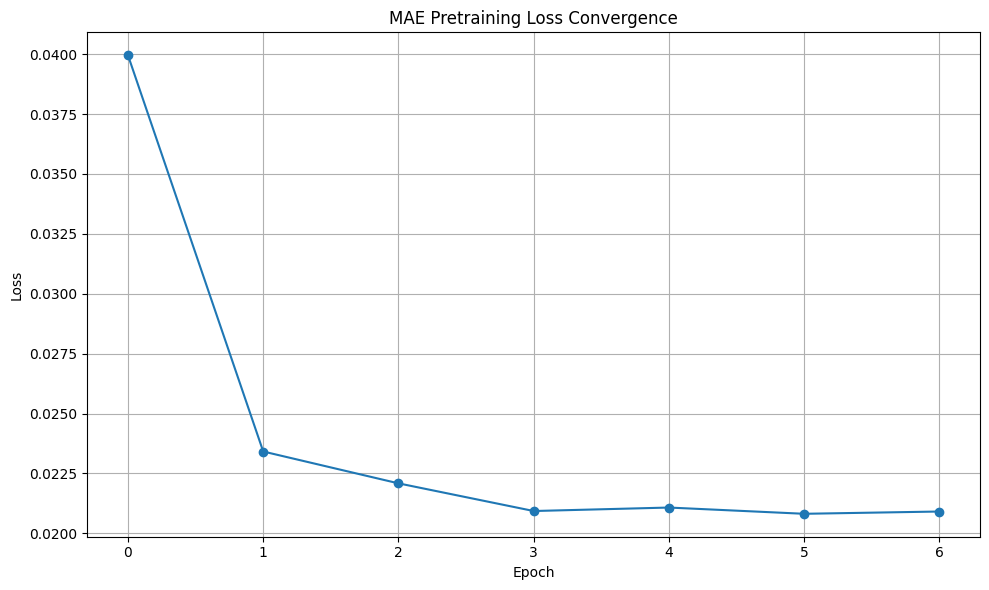

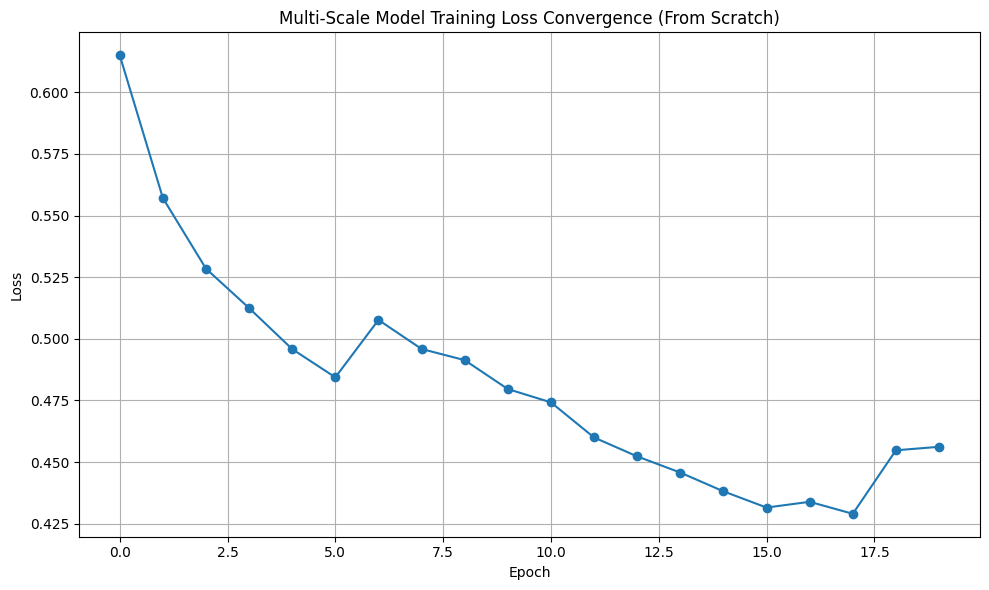

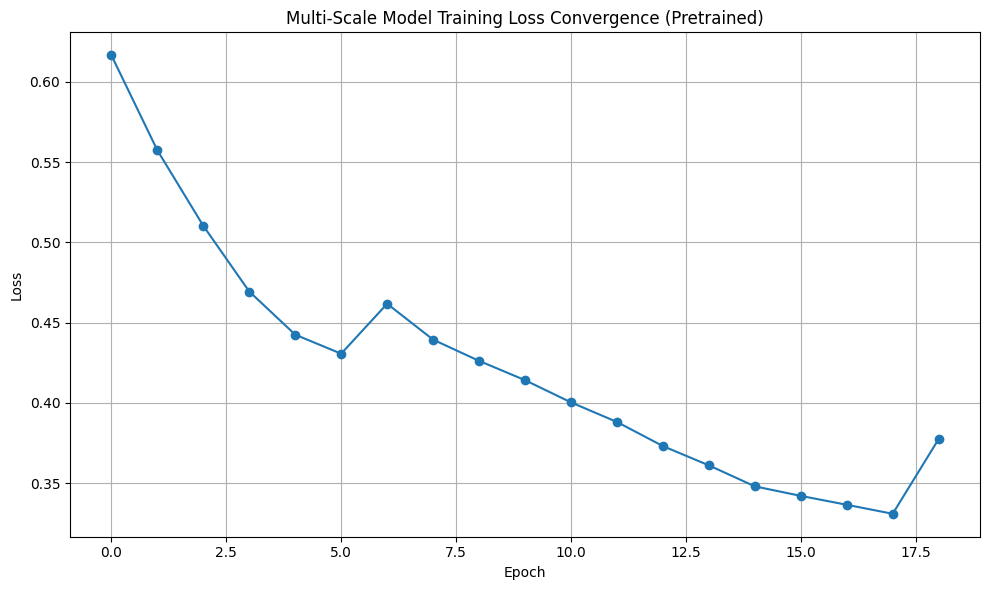

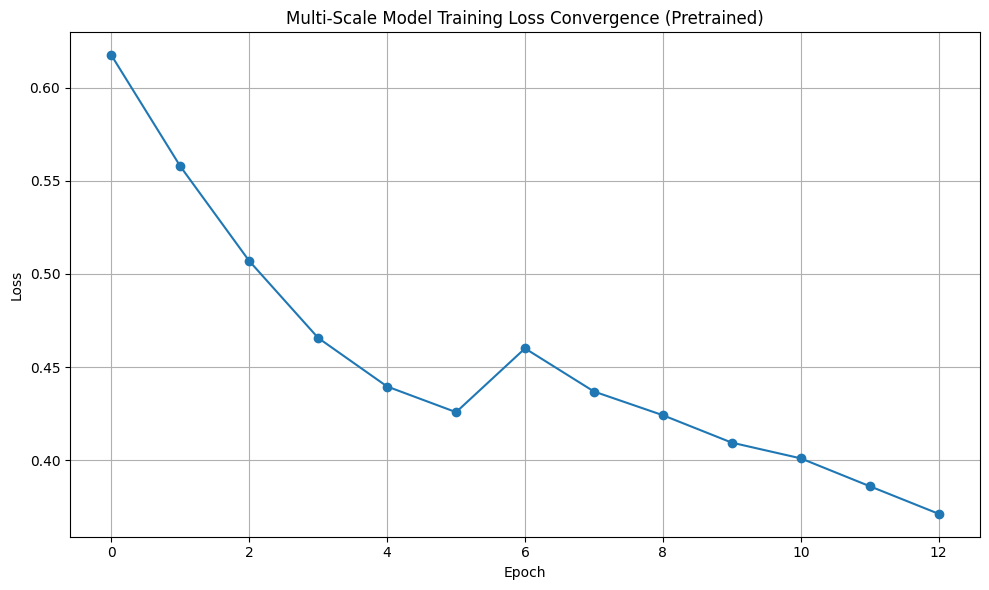

In [36]:
config = {
    'syn_to_real_ratio' : 0.05,
    'val_split'         : 0.12,
    'target_mi_ratio'   : 0.25,

    'mask_ratio'        : 0.25,
    'seg_len'           : 50,
    'augment_strength'  : 'strong',

    'd_model'           : 128,
    'n_heads'           : 8,
    'hidden_dim'        : 128,
    'n_layers_mae'      : 6,
    'n_layers_joint'    : 4,
    'kernel_sizes'      : [5, 9, 15, 25],
    'decoder_dim'       : 128,
    'emb_size'          : 24,

    'lr_mae'            : 3e-4,
    'wd_mae'            : 1e-5,
    'lr_joint'          : 1e-4,
    'wd_joint'          : 1e-3,
    'alpha_start'       : 0.5,
    'alpha_end'         : 1.0,
    'pretrain_epochs'   : 30,
    'warmup_ratio'      : 0.15,
    'learning_rate'     : 1e-4,
    'weight_decay'      : 5e-3,

    'dropout'           : 0.1,
    'encoder_dropout'   : 0.2,
    'gradient_clip_norm': 2.0,
    'early_stop_patience': 2,

    'scheduler_T0'      : 6,
    'scheduler_T_mult'  : 2,
    'eta_min'           : 0.0,

    'batch_size'        : 64,
    'eval_batch_size'   : 128,
    'syn_batch_size'    : 128,

    'seed'              : 42,
    'max_epochs'        : 25,
    'use_mae_pretraining'  : True,
    'use_joint_pretraining' : True,
    'l2_reg'            : 1e-3,
    'use_augmentation'  : True,

    'mae_pretrain_path'   : 'mae_pre.bin',
    'joint_pretrain_path' : 'joint_mae_classifier.bin',
    'base_model_path'     : 'multiscale_base.pt',
    'mae_model_path'      : 'multiscale_mae.pt',
    'joint_model_path'    : 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 0.05

Synthetic-to-real ratio: 0.05
Number of synthetic samples: 900
Target number of real samples: 18000
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 4529
Number of NORM samples to keep: 13470
Final real training subset sizes:
  Signals: (17441, 1000, 12)
  Numerical: (17441, 3)
  Categorical: (17441, 1)
  Label distribution:
MI
0    13052
1     4389
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 8/8 [00:00<00:00, 27.89it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.0, encoder dropout=0.2, L2 reg=0.001
Training: 30 epochs (max), alpha=0.5, augmentation=True, LR=0.0001
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 8/8 [00:00<00:00,  8.62it/s, loss=0.267, recon=0.0873, cls=0.9, alpha=0.2, lr=3.33e-5]


[Joint] Train Epoch 1  Total: 0.2673  Recon: 0.0873  Cls: 0.9002


...

Train Loss: 0.371219, LR: 0.000037


Validation: 100%|██████████| 18/18 [00:00<00:00, 32.50it/s]


Val Loss: 0.509943, Acc: 0.8144, AUC: 0.8892 (95% CI: 0.8742-0.9042)
Sensitivity: 0.7941, Specificity: 0.8211, Precision: 0.5942, F1: 0.6798
No improvement for 2/2 epochs
Early stopping at epoch 13

=== Testing best model from epoch 11 ===


Testing: 100%|██████████| 18/18 [00:00<00:00, 33.69it/s]



=== Test Results ===
Loss: 0.654659
Accuracy: 0.8162
AUC: 0.8844
Sensitivity: 0.7595
Specificity: 0.8352
Precision: 0.6069
F1 Score: 0.6747
Confusion Matrix: TN=1378, FP=272, FN=133, TP=420
FINAL RESULTS SUMMARY
Base model:   Acc: 0.7444, AUC: 0.8642
MAE model:    Acc: 0.8062, AUC: 0.8923
Joint model:  Acc: 0.8162, AUC: 0.8844


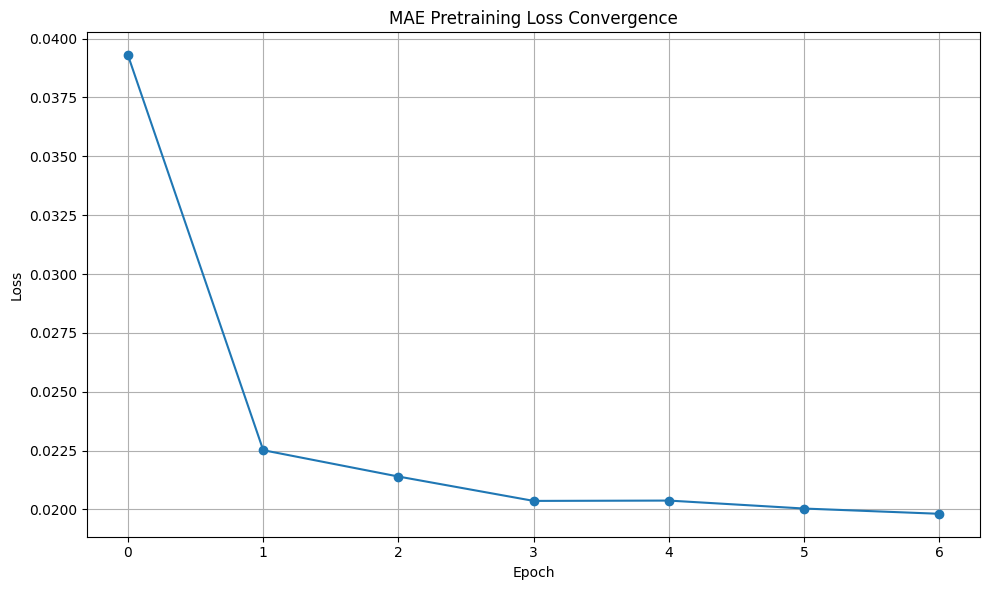

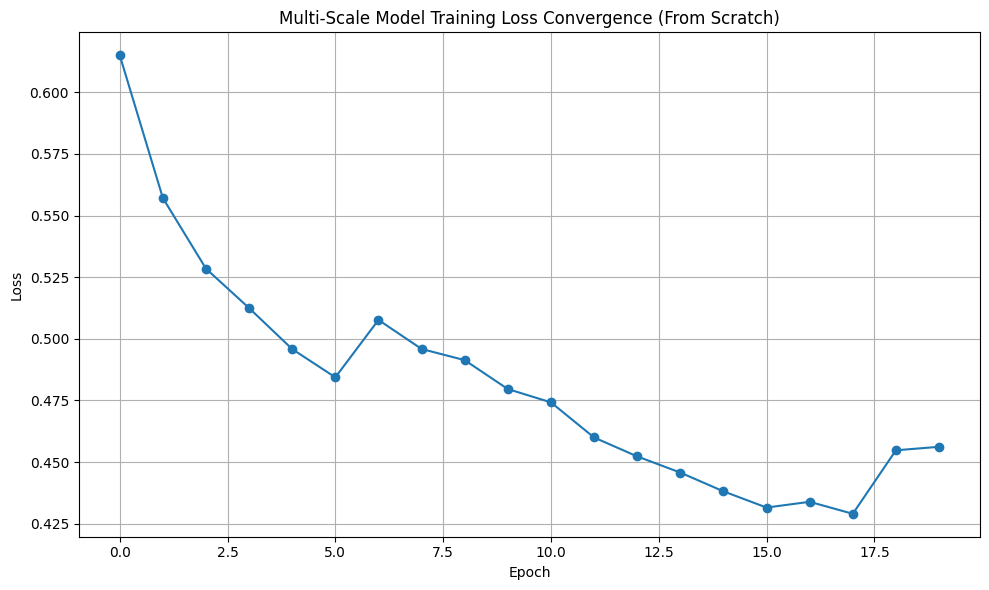

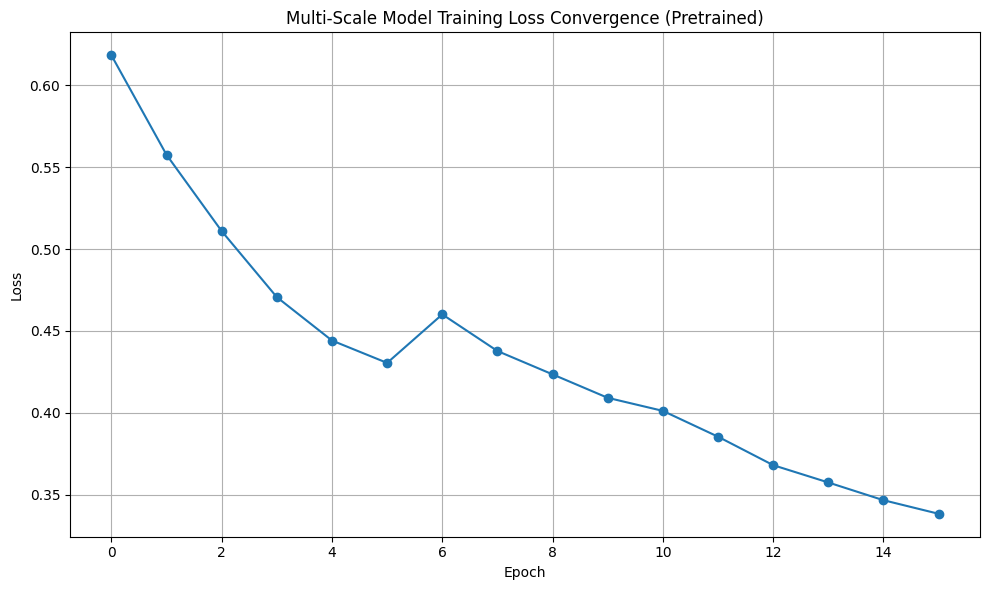

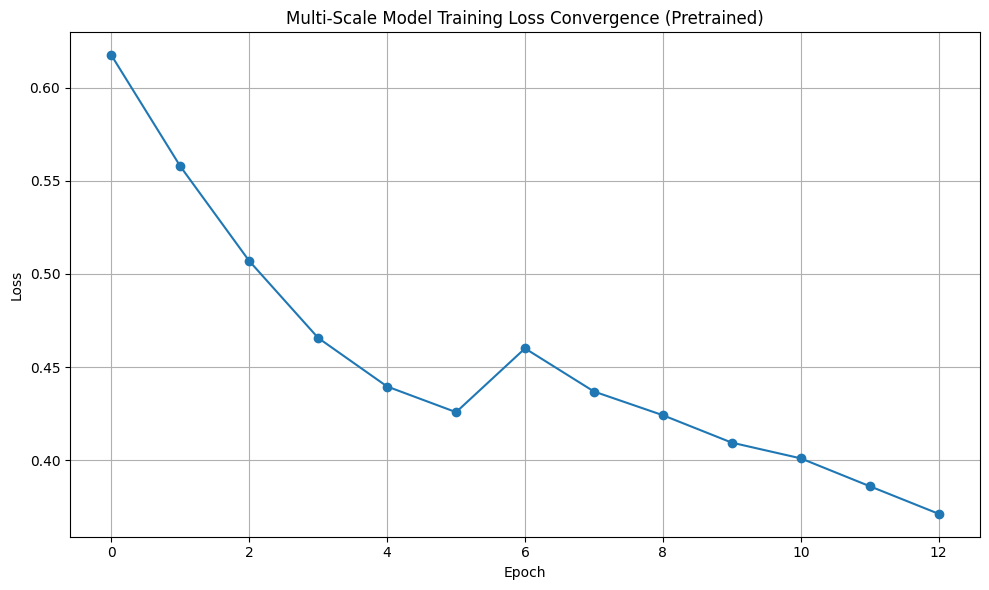

In [37]:
config = {
    'syn_to_real_ratio' : 0.05,
    'val_split'         : 0.12,
    'target_mi_ratio'   : 0.25,

    'mask_ratio'        : 0.25,
    'seg_len'           : 50,
    'augment_strength'  : 'mild',

    'd_model'           : 128,
    'n_heads'           : 8,
    'hidden_dim'        : 128,
    'n_layers_mae'      : 6,
    'n_layers_joint'    : 4,
    'kernel_sizes'      : [5, 9, 15, 25],
    'decoder_dim'       : 128,
    'emb_size'          : 24,

    'lr_mae'            : 3e-4,
    'wd_mae'            : 1e-5,
    'lr_joint'          : 1e-4,
    'wd_joint'          : 1e-3,
    'alpha_start'       : 0.5,
    'alpha_end'         : 1.0,
    'pretrain_epochs'   : 30,
    'warmup_ratio'      : 0.15,
    'learning_rate'     : 1e-4,
    'weight_decay'      : 5e-3,

    'dropout'           : 0.0,
    'encoder_dropout'   : 0.2,
    'gradient_clip_norm': 2.0,
    'early_stop_patience': 2,

    'scheduler_T0'      : 6,
    'scheduler_T_mult'  : 2,
    'eta_min'           : 0.0,

    'batch_size'        : 64,
    'eval_batch_size'   : 128,
    'syn_batch_size'    : 128,

    'seed'              : 42,
    'max_epochs'        : 20,
    'use_mae_pretraining'  : True,
    'use_joint_pretraining' : True,
    'l2_reg'            : 1e-3,
    'use_augmentation'  : True,

    'mae_pretrain_path'   : 'mae_pre.bin',
    'joint_pretrain_path' : 'joint_mae_classifier.bin',
    'base_model_path'     : 'multiscale_base.pt',
    'mae_model_path'      : 'multiscale_mae.pt',
    'joint_model_path'    : 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





### Transformer ratio = 0.05 with added calibration, boot strap and confidence intervals

In [38]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.utils import resample
from sklearn.calibration import calibration_curve
import math
import matplotlib.pyplot as plt

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)]

def create_weighted_loss(loader, device):
    print("Computing class weights for loss function...")
    y_counts = {0: 0, 1: 0}

    for _, _, _, y in tqdm(loader, desc="Counting classes"):
        y = y.squeeze(1).numpy()
        values, counts = np.unique(y, return_counts=True)
        for value, count in zip(values, counts):
            y_counts[value] += count

    total = sum(y_counts.values())
    pos_ratio = y_counts[1] / total
    neg_ratio = y_counts[0] / total

    gamma = 0.2

    print(f"Class distribution - Neg: {y_counts[0]}, Pos: {y_counts[1]}")
    print(f"Class ratios - Neg: {neg_ratio:.4f}, Pos: {pos_ratio:.4f}")

    pos_weight = torch.tensor([neg_ratio/pos_ratio], device=device)
    print(f"Using class weighted BCE with pos_weight={pos_weight.item():.4f}")
    print(f"Adding mild focal weighting (gamma={gamma})")

    def weighted_bce(logits, targets):
        return F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=pos_weight,
            reduction='mean'
        )

    def mild_focal_bce(logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=pos_weight,
            reduction='none'
        )

        if gamma > 0:
            p_t = torch.exp(-bce)
            focal_weight = (1-p_t)**gamma
            return (focal_weight * bce).mean()
        else:
            return bce.mean()

    return mild_focal_bce


def random_mask_segments(x, mask_ratio=0.15, seg_len=25):
    B, T, C = x.shape
    N_mask = int(mask_ratio * T / seg_len)
    mask = torch.zeros(B, T, dtype=torch.bool, device=x.device)

    for i in range(B):
        intervals = torch.randperm(T - seg_len)[:N_mask]
        for start in intervals:
            mask[i, start:start + seg_len] = True

    mask = mask.unsqueeze(-1).expand(-1, -1, C)
    x_masked = x.clone()
    x_masked[mask] = 0.0
    return x_masked, mask

def augment_ecg(signal, strength='mild', num_features=None, cat_features=None, labels=None):
    batch_size, time_steps, channels = signal.shape
    device = signal.device

    augmented = signal.clone()

    if strength == 'mild':
        amplitude_scale_range = (0.9, 1.1)
        time_mask_prob = 0.1
        time_mask_ratio = 0.03
        noise_std_range = (0.005, 0.005)
        add_wander = False
        lead_dropout_prob = 0

    elif strength == 'medium':
        amplitude_scale_range = (0.85, 1.15)
        time_mask_prob = 0.15
        time_mask_ratio = 0.05
        noise_std_range = (0.008, 0.02)
        add_wander = True
        lead_dropout_prob = 0.03

    else:
        amplitude_scale_range = (0.8, 1.2)
        time_mask_prob = 0
        time_mask_ratio = 0
        noise_std_range = (0.01, 0.03)
        add_wander = True
        lead_dropout_prob = 0.05

    amplitude_scale = torch.empty(batch_size, 1, 1, device=device).uniform_(*amplitude_scale_range)
    augmented = augmented * amplitude_scale

    if time_mask_prob > 0:
        mask_applied = torch.rand(batch_size, device=device) < time_mask_prob
        if mask_applied.any():
            mask_width = int(time_steps * time_mask_ratio)
            for i in range(batch_size):
                if mask_applied[i]:
                    start_idx = torch.randint(0, time_steps - mask_width, (1,), device=device)
                    augmented[i, start_idx:start_idx+mask_width, :] = 0

    if add_wander:
        wander_amplitude = torch.empty(batch_size, 1, 1, device=device).uniform_(0.0, 0.05)
        wander = torch.sin(torch.linspace(0, 6*np.pi, time_steps, device=device))
        wander = wander.reshape(1, -1, 1).repeat(batch_size, 1, channels)
        wander = wander * wander_amplitude
        augmented = augmented + wander

    if noise_std_range[1] > 0:
        if noise_std_range[0] == noise_std_range[1]:
            noise_std = noise_std_range[0]
        else:
            noise_std = torch.empty(batch_size, 1, 1, device=device).uniform_(*noise_std_range)
        noise = torch.randn_like(augmented) * noise_std
        augmented = augmented + noise

    if lead_dropout_prob > 0:
        lead_mask = torch.rand(batch_size, 1, channels, device=device) > lead_dropout_prob
        augmented = augmented * lead_mask

    if num_features is not None or cat_features is not None or labels is not None:
        return augmented, num_features, cat_features, labels
    else:
        return augmented

class MultiScaleMAE(nn.Module):
    def __init__(self, n_leads=12, hidden_dim=64, kernel_sizes=[3, 5, 9, 15, 25],
                 d_model=64, n_heads=4, n_layers=4, decoder_dim=64):
        super().__init__()
        self.input_proj = nn.Conv1d(n_leads, hidden_dim, kernel_size=1)
        self.conv_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=k, padding=k//2),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.1),
                nn.Dropout(0.2)
            ) for k in kernel_sizes
        ])
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.decoder = nn.Sequential(
            nn.Linear(d_model, decoder_dim),
            nn.ReLU(),
            nn.Linear(decoder_dim, n_leads)
        )
        self.fusion = nn.Linear(len(kernel_sizes) * hidden_dim * 2, d_model)
        self.kernel_sizes = kernel_sizes

    def forward(self, x, return_encoded=False):
        B, T, C = x.shape
        x = x.transpose(1, 2)
        x = self.input_proj(x)

        features = []
        for block in self.conv_blocks:
            out = block(x)
            maxp = F.adaptive_max_pool1d(out, 1).squeeze(-1)
            avgp = F.adaptive_avg_pool1d(out, 1).squeeze(-1)
            features.append(torch.cat([maxp, avgp], dim=1))

        feat = torch.cat(features, dim=1)
        z = self.fusion(feat).unsqueeze(1)
        z = self.pos_enc(z)
        encoded = self.encoder(z)
        encoded = encoded.expand(-1, T, -1)
        recon = self.decoder(encoded)

        if return_encoded:
            return recon, encoded
        return recon

class ECGMAEClassifier(nn.Module):
    def __init__(self, n_leads, d_model=64, n_heads=4, n_layers=2, decoder_dim=64,
                categorical_sizes=None, emb_size=16, numerical_size=0,
                dropout=0.3, encoder_dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_leads, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, batch_first=True,
            dropout=encoder_dropout
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.decoder = nn.Sequential(
            nn.Linear(d_model, decoder_dim),
            nn.Dropout(encoder_dropout),
            nn.ReLU(),
            nn.Linear(decoder_dim, n_leads)
        )
        self.embeddings = None
        self.dropout = nn.Dropout(dropout)
        if categorical_sizes:
            self.embeddings = nn.ModuleList([
                nn.Embedding(sz, emb_size) for sz in categorical_sizes
            ])
        cls_input_size = d_model
        if self.embeddings:
            cls_input_size += emb_size * len(categorical_sizes)
        if numerical_size > 0:
            cls_input_size += numerical_size

        self.classifier = nn.Sequential(
            nn.Linear(cls_input_size, cls_input_size // 2),
            nn.BatchNorm1d(cls_input_size // 2),
            nn.Dropout(dropout),
            nn.ReLU(),
            nn.Linear(cls_input_size // 2, 1)
        )

    def forward(self, x_masked, num=None, cat=None):
        x = self.input_proj(x_masked)
        x = self.pos_enc(x)
        z = self.encoder(x)
        recon = self.decoder(z)
        z_avg = z.mean(dim=1)
        z_avg = self.dropout(z_avg)

        if self.embeddings is not None and cat is not None:
            emb = torch.cat([e(cat[:,i]) for i,e in enumerate(self.embeddings)], dim=1)
            features = [z_avg, emb]
            if num is not None:
                features.append(num)
            combined = torch.cat(features, dim=1)
        else:
            combined = z_avg

        cls_logits = self.classifier(combined).squeeze(-1)
        return recon, cls_logits

def pretrain_mae(syn_train_loader: DataLoader, device, syn_val_loader=None, mask_ratio=0.15, seg_len=25,
                 epochs=4, lr=1e-4, save_path="mae_pre.bin", seed=42, strength='mild'):
    set_random_seed(seed)
    model = MultiScaleMAE(n_leads=12).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    scaler = GradScaler()
    best_loss = float('inf')
    best_model_state = None
    patience = 2
    patience_counter = 0
    train_losses = []

    print(f"\n=== Starting MAE Pretraining ===")
    print(f"Model: 4 layers")
    print(f"Training: {epochs} epochs (max), mask_ratio={mask_ratio}, segment_length={seg_len}")
    if syn_val_loader:
        print(f"Using separate validation set for early stopping")

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        total_samples = 0

        pbar = tqdm(syn_train_loader, desc=f"Epoch {epoch}")
        for sig, _, _, _ in pbar:
            sig = sig.to(device)
            batch_size = sig.size(0)
            total_samples += batch_size
            sig = augment_ecg(sig,
                             strength=strength,
                             num_features=None,
                             cat_features=None,
                             labels=None)

            sig_masked, mask = random_mask_segments(sig, mask_ratio, seg_len)

            optimizer.zero_grad()
            with autocast():
                recon = model(sig_masked)
                loss = loss_fn(recon[mask], sig[mask])
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * batch_size
            pbar.set_postfix({"loss": total_loss/total_samples})

        avg_loss = total_loss / total_samples
        train_losses.append(avg_loss)
        print(f"[MAE] Train Epoch {epoch}  Loss: {avg_loss:.6f}")

        if syn_val_loader:
            model.eval()
            val_loss = 0.0
            val_samples = 0

            with torch.no_grad():
                for sig, _, _, _ in tqdm(syn_val_loader, desc="Validation"):
                    sig = sig.to(device)
                    val_batch_size = sig.size(0)
                    val_samples += val_batch_size
                    sig_masked, mask = random_mask_segments(sig, mask_ratio, seg_len)
                    recon = model(sig_masked)
                    loss = loss_fn(recon[mask], sig[mask])
                    val_loss += loss.item() * val_batch_size

            val_avg_loss = val_loss / val_samples
            print(f"[MAE] Val Epoch {epoch}  Loss: {val_avg_loss:.6f}")
            if val_avg_loss < best_loss:
                best_loss = val_avg_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
                print(f"[MAE] New best model saved with validation loss: {val_avg_loss:.6f}")
            else:
                patience_counter += 1
                print(f"[MAE] No improvement for {patience_counter}/{patience} epochs")
            if patience_counter >= patience:
                print(f"[MAE] Early stopping triggered after {epoch} epochs")
                break
        else:
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
                print(f"[MAE] New best model saved with loss: {avg_loss:.6f}")
            else:
                patience_counter += 1
                print(f"[MAE] No improvement for {patience_counter}/{patience} epochs")
            if patience_counter >= patience:
                print(f"[MAE] Early stopping triggered after {epoch} epochs")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, marker='o')
    plt.title("MAE Pretraining Loss Convergence")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("mae_training_loss_curve.png")

    torch.save(model.state_dict(), save_path)
    return save_path

def pretrain_joint_mae(syn_loader_tuple, device, categorical_sizes=None, numerical_size=0,
                      mask_ratio=0.15, seg_len=25, alpha=0.2, epochs=4, lr=5e-5,
                      save_path="joint_mae_classifier.bin",
                      dropout=0.5, encoder_dropout=0.3, l2_reg=3e-3, use_augmentation=True, seed=42, strength='mild'):
    set_random_seed(seed)
    syn_train_loader, syn_val_loader = syn_loader_tuple
    n_layers = 2
    model = ECGMAEClassifier(
        n_leads=12,
        d_model=64,
        n_heads=4,
        n_layers=n_layers,
        decoder_dim=64,
        categorical_sizes=categorical_sizes,
        emb_size=16,
        numerical_size=numerical_size,
        dropout=dropout,
        encoder_dropout=encoder_dropout
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=l2_reg)
    num_steps = epochs * len(syn_train_loader)
    warmup_steps = int(0.1 * num_steps)
    train_losses = []

    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, num_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = GradScaler()
    cls_loss_fn = create_weighted_loss(syn_train_loader, device)
    recon_loss_fn = nn.MSELoss()

    print(f"\n=== Starting Joint MAE+Classification Training ===")
    print(f"Model: {n_layers} layers, head dropout={dropout}, encoder dropout={encoder_dropout}, L2 reg={l2_reg}")
    print(f"Training: {epochs} epochs (max), alpha={alpha}, augmentation={use_augmentation}, LR={lr}")
    print(f"Using separate validation set for early stopping")
    best_val_loss = float('inf')
    patience = 2
    patience_counter = 0
    best_model_state = None
    max_grad_norm = 1.0

    for epoch in range(1, epochs+1):
        current_alpha = min(0.2 + (epoch-1) * 0.4, 1.0)
        model.train()
        total_loss = 0.0
        recon_losses = 0.0
        cls_losses = 0.0
        total_samples = 0

        pbar = tqdm(syn_train_loader, desc=f"Epoch {epoch}")
        for sig, num, cat, y in pbar:
            sig = sig.to(device)
            y = y.to(device).float().squeeze(1)
            batch_size = sig.size(0)
            total_samples += batch_size
            if num is not None:
                num = num.to(device).float()
            if cat is not None:
                cat = cat.to(device).long()
            if use_augmentation:
                augmented_result = augment_ecg(sig,
                                 strength=strength,
                                 num_features=num,
                                 cat_features=cat,
                                 labels=y)
                if isinstance(augmented_result, tuple):
                    sig = augmented_result[0]
                    num = augmented_result[1]
                    cat = augmented_result[2]
                    y = augmented_result[3]
                else:
                    sig = augmented_result

            sig_masked, mask = random_mask_segments(sig, mask_ratio, seg_len)

            optimizer.zero_grad()
            with autocast():
                recon, logits = model(sig_masked, num, cat)
                loss_recon = recon_loss_fn(recon[mask], sig[mask])
                loss_cls = cls_loss_fn(logits, y)
                loss = loss_recon + current_alpha * loss_cls

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            recon_losses += loss_recon.item() * batch_size
            cls_losses += loss_cls.item() * batch_size
            total_loss += loss.item() * batch_size
            pbar.set_postfix({
                "loss": total_loss/total_samples,
                "recon": recon_losses/total_samples,
                "cls": cls_losses/total_samples,
                "alpha": current_alpha,
                "lr": scheduler.get_last_lr()[0]
            })

        avg_loss = total_loss / total_samples
        avg_recon = recon_losses / total_samples
        avg_cls = cls_losses / total_samples
        train_losses.append(avg_loss)

        print(f"[Joint] Train Epoch {epoch}  Total: {avg_loss:.4f}  Recon: {avg_recon:.4f}  Cls: {avg_cls:.4f}")
        model.eval()
        val_total_loss = 0.0
        val_recon_losses = 0.0
        val_cls_losses = 0.0
        val_samples = 0
        all_logits, all_y = [], []

        with torch.no_grad():
            for sig, num, cat, y in tqdm(syn_val_loader, desc="Validation"):
                sig = sig.to(device)
                y = y.to(device).float().squeeze(1)
                val_batch_size = sig.size(0)
                val_samples += val_batch_size
                if num is not None:
                    num = num.to(device).float()
                if cat is not None:
                    cat = cat.to(device).long()
                sig_masked, mask = random_mask_segments(sig, mask_ratio * 0.7, seg_len)
                recon, logits = model(sig_masked, num, cat)
                loss_recon = recon_loss_fn(recon[mask], sig[mask])
                loss_cls = cls_loss_fn(logits, y)
                loss = loss_recon + current_alpha * loss_cls
                val_recon_losses += loss_recon.item() * val_batch_size
                val_cls_losses += loss_cls.item() * val_batch_size
                val_total_loss += loss.item() * val_batch_size
                all_logits.append(logits.cpu())
                all_y.append(y.cpu())

        val_avg_loss = val_total_loss / val_samples
        val_avg_recon = val_recon_losses / val_samples
        val_avg_cls = val_cls_losses / val_samples

        logits = torch.cat(all_logits).sigmoid().numpy()
        y_gt = torch.cat(all_y).numpy()

        fpr, tpr, thresholds = roc_curve(y_gt, logits)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]

        preds = (logits >= optimal_threshold).astype(int)
        acc = (preds == y_gt).mean()

        try:
            auc = roc_auc_score(y_gt, logits)
        except ValueError:
            auc = 0.5

        tn, fp, fn, tp = confusion_matrix(y_gt, preds).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"[Joint] Val Epoch {epoch}  Loss: {val_avg_loss:.4f}  Recon: {val_avg_recon:.4f}  Cls: {val_avg_cls:.4f}")
        print(f"[Joint] Val Metrics - Acc: {acc:.4f}, AUC: {auc:.4f}, Sens: {sensitivity:.4f}, Spec: {specificity:.4f}")

        val_score = val_avg_loss - (auc * 0.1)

        if val_score < best_val_loss:
            best_val_loss = val_score
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"[Joint] New best model saved with validation score: {val_score:.4f}")
        else:
            patience_counter += 1
            print(f"[Joint] No improvement for {patience_counter}/{patience} epochs")

        if auc > 0.98 and (sensitivity > 0.95 and specificity > 0.95):
            print("[Joint] WARNING: Validation metrics appear too good, may indicate overfitting!")
            print("[Joint] Consider adding more regularization or reducing model capacity.")

        if patience_counter >= patience:
            print(f"[Joint] Early stopping triggered after {epoch} epochs")
            break

    print("Joint pretraining complete!")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, marker='o')
    plt.title("Joint MAE+Classification Training Loss Convergence")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("joint_training_loss_curve.png")

    torch.save(model.state_dict(), save_path)
    return save_path


def train_epoch_with_clipping(model, loader, optimizer, loss_fn, device, scheduler=None, clip_value=1.0):
    model.train()
    scaler = GradScaler()
    total = 0
    for sig, num, cat, y in tqdm(loader, desc="  Train"):
        sig, num, cat = sig.to(device), num.to(device), cat.to(device)
        y = y.to(device).float().squeeze(1)

        optimizer.zero_grad()
        with autocast():
            logits = model(sig, num, cat)   # (B,)
            loss   = loss_fn(logits, y)     # both are now (B,)
        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)

        scaler.step(optimizer)
        scaler.update()
        total += loss.item() * sig.size(0)
    return total / len(loader.dataset)

class MultiScaleECGClassifier(nn.Module):
    def __init__(self, n_leads=12, hidden_dim=64, numerical_size=0, categorical_sizes=None, emb_size=16, kernel_sizes=[3,5,9,15,25], d_model=64, n_heads=4, n_layers=4):
        super().__init__()

        self.kernel_sizes = kernel_sizes

        self.input_proj = nn.Conv1d(n_leads, hidden_dim, kernel_size=1)

        self.conv_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=k, padding=k//2),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.1),
                nn.Dropout(0.2)
            ) for k in [3, 5, 9, 15, 25]
        ])

        self.res_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.1)
            ) for _ in range(5)
        ])

        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        self.embeddings = None
        if categorical_sizes:
            self.embeddings = nn.ModuleList([
                nn.Embedding(sz, emb_size) for sz in categorical_sizes
            ])

        feature_dim = hidden_dim * 2 * 5
        if self.embeddings:
            feature_dim += emb_size * len(categorical_sizes)
        if numerical_size > 0:
            feature_dim += numerical_size

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.LayerNorm(feature_dim // 2),
            nn.Dropout(0.5),
            nn.LeakyReLU(0.1),
            nn.Linear(feature_dim // 2, feature_dim // 4),
            nn.LayerNorm(feature_dim // 4),
            nn.Dropout(0.3),
            nn.LeakyReLU(0.1),
            nn.Linear(feature_dim // 4, 1)
        )

        self.fusion   = nn.Linear(len(kernel_sizes)*hidden_dim*2, d_model)
        self.pos_enc  = PositionalEncoding(d_model)
        enc_layer     = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.decoder = nn.Linear(d_model, n_leads)


    def forward(self, sig, num=None, cat=None):
        x = sig.transpose(1, 2)

        x = self.input_proj(x)

        scale_features = []
        for i, (conv, res) in enumerate(zip(self.conv_blocks, self.res_blocks)):
            x_res = res(x)
            x_conv = conv(x)
            x_combined = x_conv + x_res

            max_feat = self.global_max_pool(x_combined).squeeze(-1)
            avg_feat = self.global_avg_pool(x_combined).squeeze(-1)

            scale_feat = torch.cat([max_feat, avg_feat], dim=1)
            scale_features.append(scale_feat)

        x = torch.cat(scale_features, dim=1)

        if self.embeddings is not None and cat is not None:
            emb = torch.cat([e(cat[:,i]) for i,e in enumerate(self.embeddings)], dim=1)
            features = [x, emb]

            if num is not None:
                features.append(num)

            combined = torch.cat(features, dim=1)
        else:
            combined = x

        return self.classifier(combined).squeeze(-1)

# def load_weights_for_multiscale_model(pretrain_path, model, device):
#     pretrained = torch.load(pretrain_path, map_location=device)
#     target_dict = model.state_dict()
#     transfer_dict = {}

#     if "input_proj.weight" in pretrained:
#         input_weight = pretrained["input_proj.weight"]
#         if "input_proj.weight" in target_dict and input_weight.shape == target_dict["input_proj.weight"].shape:
#             transfer_dict["input_proj.weight"] = input_weight

#     if "input_proj.bias" in pretrained and "input_proj.bias" in target_dict:
#         if pretrained["input_proj.bias"].shape == target_dict["input_proj.bias"].shape:
#             transfer_dict["input_proj.bias"] = pretrained["input_proj.bias"]

#     for k, v in pretrained.items():
#         if k.startswith("embeddings.") and k in target_dict:
#             transfer_dict[k] = v

#     target_dict.update(transfer_dict)
#     model.load_state_dict(target_dict)

#     return len(transfer_dict)


def load_weights_for_multiscale_model(pretrain_path, model, device):
    src = torch.load(pretrain_path, map_location=device)
    dst = model.state_dict()
    loaded = 0
    for k, v in src.items():
        if k in dst and v.shape == dst[k].shape:
            dst[k] = v
            loaded += 1
    model.load_state_dict(dst)
    print(f"transferred {loaded}/{len(dst)} tensors from {pretrain_path}")
    return loaded

def bootstrap_auc_ci(y_true, y_pred, n_bootstraps=1000, ci=0.95):

    bootstrapped_scores = []

    for i in range(n_bootstraps):
        indices = resample(range(len(y_true)), replace=True, n_samples=len(y_true))
        if len(np.unique(y_true[indices])) < 2:
            continue

        score = roc_auc_score(y_true[indices], y_pred[indices])
        bootstrapped_scores.append(score)

    alpha = (1.0 - ci) / 2.0
    lower_bound = max(0.0, np.percentile(bootstrapped_scores, alpha * 100))
    upper_bound = min(1.0, np.percentile(bootstrapped_scores, (1 - alpha) * 100))

    return np.mean(bootstrapped_scores), lower_bound, upper_bound

def plot_calibration(y_true, y_prob, n_bins=10, title="Calibration Plot", filename="calibration_plot.png"):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')

    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker='o', label='Model')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)

def compare_calibration_plots(base_results, pretrained_results, filename="calibration_comparison.png"):
    """
    Compare calibration curves between base and pretrained models.

    Parameters:
    -----------
    base_results : tuple
        (y_true, y_prob) for the base model
    pretrained_results : tuple
        (y_true, y_prob) for the pretrained model
    filename : str
        Output filename for the comparison plot
    """
    y_true_base, y_prob_base = base_results
    y_true_pre, y_prob_pre = pretrained_results

    prob_true_base, prob_pred_base = calibration_curve(y_true_base, y_prob_base, n_bins=10, strategy='uniform')
    prob_true_pre, prob_pred_pre = calibration_curve(y_true_pre, y_prob_pre, n_bins=10, strategy='uniform')

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(prob_pred_base, prob_true_base, marker='o', label='Base Model')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.title("Base Model Calibration")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(prob_pred_pre, prob_true_pre, marker='o', label='Pretrained Model')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.title("Pretrained Model Calibration")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(filename)

    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred_base, prob_true_base, marker='o', label='Base Model')
    plt.plot(prob_pred_pre, prob_true_pre, marker='s', label='Pretrained Model')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.title("Calibration Comparison")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("calibration_combined.png")

def train_multiscale_model(train_loader, valid_loader, test_loader,
                          categorical_sizes, numerical_size,
                          device, pretrain_path=None, seed=42,
                          learning_rate=3e-4, weight_decay=0.01,
                          max_epochs=12, early_stop_patience=4,
                          gradient_clip_norm=1.0,
                          scheduler_T0=5, scheduler_T_mult=1, eta_min=0.0):
    set_random_seed(seed)
    train_losses = []

    model = MultiScaleECGClassifier(
        n_leads=12,
        hidden_dim=64,
        numerical_size=numerical_size,
        categorical_sizes=categorical_sizes,
        emb_size=16
    ).to(device)

    if pretrain_path:
        num_loaded = load_weights_for_multiscale_model(pretrain_path, model, device)
        print(f" Loaded {num_loaded} tensors from pretrained model")

    print("Computing dataset statistics for balanced loss...")
    pos_count, neg_count = 0, 0
    for _, _, _, y in train_loader:
        y = y.squeeze(1).numpy()
        pos_count += (y == 1).sum()
        neg_count += (y == 0).sum()

    pos_weight = torch.tensor([neg_count / pos_count], device=device)
    print(f"Class counts - Pos: {pos_count}, Neg: {neg_count}, Pos weight: {pos_weight.item():.4f}")

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=scheduler_T0,
        T_mult=scheduler_T_mult,
        eta_min=eta_min
    )

    def weighted_focal_loss(logits, targets, gamma=1.0):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=pos_weight,
            reduction='none'
        )

        pt = torch.exp(-bce)
        focal_weight = (1 - pt) ** gamma
        return (focal_weight * bce).mean()

    best_auc = 0
    best_threshold = 0.5
    best_epoch = 0
    patience_counter = 0

    print(f"\n=== Training Multi-Scale Model {'with pretraining' if pretrain_path else 'from scratch'} ===")
    print(f"LR: {learning_rate}, Weight decay: {weight_decay}")

    freeze_epochs = 2                 # <-- new hyper-param if you like
    for p in model.input_proj.parameters(): p.requires_grad = False
    for p in model.conv_blocks.parameters(): p.requires_grad = False


    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0

        for sig, num, cat, y in tqdm(train_loader, desc=f"Epoch {epoch}"):
            sig = sig.to(device)
            num = num.to(device) if num is not None else None
            cat = cat.to(device) if cat is not None else None
            y = y.to(device).float().squeeze(1)

            batch_size = sig.size(0)

            if np.random.random() < 0.5 and pretrain_path is not None:
                scale_factor = torch.rand(batch_size, 1, 1, device=device) * 0.4 + 0.8
                sig = sig * scale_factor

                noise = torch.randn_like(sig) * 0.02
                sig = sig + noise

            optimizer.zero_grad()
            logits = model(sig, num, cat)
            loss = weighted_focal_loss(logits, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_norm)

            optimizer.step()
            train_loss += loss.item() * batch_size

        if epoch == freeze_epochs and pretrain_path is not None:
            for p in model.input_proj.parameters(): p.requires_grad = True
            for p in model.conv_blocks.parameters(): p.requires_grad = True

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        print(f"Train Loss: {avg_train_loss:.6f}, LR: {current_lr:.6f}")

        model.eval()
        val_loss = 0
        all_logits, all_y = [], []

        with torch.no_grad():
            for sig, num, cat, y in tqdm(valid_loader, desc="Validation"):
                sig = sig.to(device)
                num = num.to(device) if num is not None else None
                cat = cat.to(device) if cat is not None else None
                y = y.to(device).float().squeeze(1)

                logits = model(sig, num, cat)
                loss = weighted_focal_loss(logits, y, gamma=0.5)

                val_loss += loss.item() * sig.size(0)
                all_logits.append(logits.cpu())
                all_y.append(y.cpu())

        val_loss = val_loss / len(valid_loader.dataset)
        logits = torch.cat(all_logits).sigmoid().numpy()
        y_gt = torch.cat(all_y).numpy()

        auc = roc_auc_score(y_gt, logits)
        auc_mean, auc_lower, auc_upper = bootstrap_auc_ci(y_gt, logits, n_bootstraps=1000)

        fpr, tpr, thresholds = roc_curve(y_gt, logits)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]

        preds = (logits >= optimal_threshold).astype(int)
        acc = (preds == y_gt).mean()

        tn, fp, fn, tp = confusion_matrix(y_gt, preds).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = f1_score(y_gt, preds)

        print(f"Val Loss: {val_loss:.6f}, Acc: {acc:.4f}, AUC: {auc:.4f} (95% CI: {auc_lower:.4f}-{auc_upper:.4f})")
        print(f"Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}, Precision: {precision_val:.4f}, F1: {f1:.4f}")

        if auc > best_auc:
            best_auc = auc
            best_threshold = optimal_threshold
            best_epoch = epoch
            patience_counter = 0

            torch.save(model.state_dict(), "best_multiscale_model.pt")
            print(f"New best model saved with AUC: {best_auc:.4f}")
        else:
            patience_counter += 1
            print(f"No improvement for {patience_counter}/{early_stop_patience} epochs")

            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, marker='o')
    plt.title(f"Multi-Scale Model Training Loss Convergence {'(Pretrained)' if pretrain_path else '(From Scratch)'}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"multiscale_training_loss_{'pretrained' if pretrain_path else 'scratch'}.png")

    print(f"\n=== Testing best model from epoch {best_epoch} ===")
    model.load_state_dict(torch.load("best_multiscale_model.pt"))

    model.eval()
    test_loss = 0
    all_logits, all_y = [], []

    with torch.no_grad():
        for sig, num, cat, y in tqdm(test_loader, desc="Testing"):
            sig = sig.to(device)
            num = num.to(device) if num is not None else None
            cat = cat.to(device) if cat is not None else None
            y = y.to(device).float().squeeze(1)

            logits = model(sig, num, cat)
            loss = weighted_focal_loss(logits, y, gamma=0)

            test_loss += loss.item() * sig.size(0)
            all_logits.append(logits.cpu())
            all_y.append(y.cpu())

    test_loss = test_loss / len(test_loader.dataset)
    logits = torch.cat(all_logits).sigmoid().numpy()
    y_gt = torch.cat(all_y).numpy()

    # Calculate AUC and confidence intervals
    auc = roc_auc_score(y_gt, logits)
    auc_mean, auc_lower, auc_upper = bootstrap_auc_ci(y_gt, logits, n_bootstraps=1000)

    preds = (logits >= best_threshold).astype(int)
    acc = (preds == y_gt).mean()

    tn, fp, fn, tp = confusion_matrix(y_gt, preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = f1_score(y_gt, preds)

    print("\n=== Test Results ===")
    print(f"Loss: {test_loss:.6f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision_val:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    # Plot calibration curve
    model_type = "pretrained" if pretrain_path else "base"
    plot_calibration(
        y_gt,
        logits,
        n_bins=10,
        title=f"Calibration Plot ({model_type.capitalize()} Model)",
        filename=f"calibration_plot_{model_type}.png"
    )

    # Save the true labels and predictions for later comparison
    np.savez(f"{model_type}_calibration_data.npz", y_true=y_gt, y_prob=logits)

    return acc, auc, (auc_lower, auc_upper)

def sample_real_data(train_superclass, train_signals, train_numerical, train_categorical, syn_to_real_ratio, seed):
    y_train_bin = train_superclass[['MI']]
    num_syn_samples = len(syn_X)
    total_real_needed = int(num_syn_samples / syn_to_real_ratio)

    print("\nSynthetic-to-real ratio:", syn_to_real_ratio)
    print("Number of synthetic samples:", num_syn_samples)
    print("Target number of real samples:", total_real_needed)

    mi_mask = y_train_bin['MI'] == 1
    non_mi_mask = y_train_bin['MI'] == 0
    mi_indices = np.where(mi_mask)[0]
    non_mi_indices = np.where(non_mi_mask)[0]

    print("Original real MI samples:", len(mi_indices))
    print("Original real NORM samples:", len(non_mi_indices))

    mi_ratio = len(mi_indices) / (len(mi_indices) + len(non_mi_indices))
    non_mi_ratio = 1 - mi_ratio

    real_MI_keep = int(total_real_needed * mi_ratio)
    real_non_MI_keep = int(total_real_needed * non_mi_ratio)

    print("Number of MI samples to keep:", real_MI_keep)
    print("Number of NORM samples to keep:", real_non_MI_keep)

    rng = np.random.RandomState(seed)
    mi_sample_idx = rng.choice(mi_indices, size=min(real_MI_keep, len(mi_indices)), replace=False)
    non_mi_sample_idx = rng.choice(non_mi_indices, size=min(real_non_MI_keep, len(non_mi_indices)), replace=False)

    all_keep_idx = np.concatenate([mi_sample_idx, non_mi_sample_idx])

    train_signals_sub = train_signals[all_keep_idx]
    train_numerical_sub = train_numerical.iloc[all_keep_idx].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[all_keep_idx].reset_index(drop=True)
    y_train_bin_sub = y_train_bin.iloc[all_keep_idx].reset_index(drop=True)

    print("Final real training subset sizes:")
    print("  Signals:", train_signals_sub.shape)
    print("  Numerical:", train_numerical_sub.shape)
    print("  Categorical:", train_categorical_sub.shape)
    print("  Label distribution:")
    print(y_train_bin_sub['MI'].value_counts())

    return train_signals_sub, train_numerical_sub, train_categorical_sub, y_train_bin_sub


def run_transformer_pipeline(preprocessor, config,
                          train_signals, train_numerical, train_categorical, train_superclass,
                          valid_signals, valid_numerical, valid_categorical, valid_superclass,
                          test_signals, test_numerical, test_categorical, test_superclass,
                          syn_X, syn_num, syn_cat, syn_sup):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    set_random_seed(config['seed'])

    print("\n=== Preparing Training Data ===")
    print(f"Synthetic-to-real ratio: {config['syn_to_real_ratio']}")

    train_signals_sub, train_numerical_sub, train_categorical_sub, train_superclass_sub = sample_real_data(
        train_superclass, train_signals, train_numerical, train_categorical,
        config['syn_to_real_ratio'], config['seed']
    )

    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    numerical_size = train_numerical_sub.shape[1]

    print("\n=== Creating Data Loaders ===")
    syn_train_loader = create_dataloader(
        syn_X, syn_num, syn_cat, syn_sup[['MI']],
        None, batch_size=config['syn_batch_size']
    )

    syn_val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass[['MI']], None, batch_size=config['eval_batch_size']
    )

    train_loader = create_dataloader(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
        train_superclass_sub[['MI']], None, batch_size=config['batch_size']
    )

    valid_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass[['MI']], None, batch_size=config['eval_batch_size']
    )

    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass[['MI']], None, batch_size=config['eval_batch_size']
    )

    pretrain_results = {}

    if config['use_joint_pretraining']:
        print("\n=== Joint MAE+Classification Pretraining ===")
        joint_pre_path = pretrain_joint_mae(
            (syn_train_loader, syn_val_loader),
            device,
            categorical_sizes=categorical_sizes,
            numerical_size=numerical_size,
            mask_ratio=config['mask_ratio'],
            seg_len=config['seg_len'],
            alpha=config['alpha_start'],
            epochs=config['pretrain_epochs'],
            lr=config['lr_joint'],
            save_path=config['joint_pretrain_path'],
            dropout=config['dropout'],
            encoder_dropout=config['encoder_dropout'],
            l2_reg=config['wd_joint'],
            use_augmentation=config['use_augmentation'],
            seed=config['seed'],
            strength=config['augment_strength']
        )
        pretrain_results['joint'] = joint_pre_path

    if config['use_mae_pretraining']:
        print("\n=== Self-supervised MAE Pretraining ===")
        mae_pre_path = pretrain_mae(
            syn_train_loader,
            device,
            syn_val_loader=syn_val_loader,
            mask_ratio=config['mask_ratio'],
            seg_len=config['seg_len'],
            epochs=config['pretrain_epochs'],
            lr=config['lr_mae'],
            save_path=config['mae_pretrain_path'],
            seed=config['seed'],
            strength=config['augment_strength']
        )
        pretrain_results['mae'] = mae_pre_path

    models_results = {}

    print("\n=== Training Base Model (No Pretraining) ===")
    base_acc, base_auc, base_auc_ci = train_multiscale_model(
        train_loader, valid_loader, test_loader,
        categorical_sizes, numerical_size,
        device, pretrain_path=None,
        seed=config['seed'],
        learning_rate=config['learning_rate'],
        weight_decay=config['weight_decay'],
        max_epochs=config['max_epochs'],
        early_stop_patience=config['early_stop_patience'],
        gradient_clip_norm=config['gradient_clip_norm'],
        scheduler_T0=config['scheduler_T0'],
        scheduler_T_mult=config['scheduler_T_mult'],
        eta_min=config['eta_min']
    )
    models_results['base'] = {'acc': base_acc, 'auc': base_auc, 'auc_ci': base_auc_ci}

    if config['use_mae_pretraining']:
        print("\n=== Training Model with MAE Pretraining ===")
        mae_acc, mae_auc, mae_auc_ci = train_multiscale_model(
            train_loader, valid_loader, test_loader,
            categorical_sizes, numerical_size,
            device, pretrain_path=pretrain_results['mae'],
            seed=config['seed'],
            learning_rate=config['learning_rate'],
            weight_decay=config['weight_decay'],
            max_epochs=config['max_epochs'],
            early_stop_patience=config['early_stop_patience'],
            gradient_clip_norm=config['gradient_clip_norm'],
            scheduler_T0=config['scheduler_T0'],
            scheduler_T_mult=config['scheduler_T_mult'],
            eta_min=config['eta_min']
        )
        models_results['mae'] = {'acc': mae_acc, 'auc': mae_auc, 'auc_ci': mae_auc_ci}

    if config['use_joint_pretraining']:
        print("\n=== Training Model with Joint Pretraining ===")
        joint_acc, joint_auc, joint_auc_ci = train_multiscale_model(
            train_loader, valid_loader, test_loader,
            categorical_sizes, numerical_size,
            device, pretrain_path=pretrain_results['joint'],
            seed=config['seed'],
            learning_rate=config['learning_rate'],
            weight_decay=config['weight_decay'],
            max_epochs=config['max_epochs'],
            early_stop_patience=config['early_stop_patience'],
            gradient_clip_norm=config['gradient_clip_norm'],
            scheduler_T0=config['scheduler_T0'],
            scheduler_T_mult=config['scheduler_T_mult'],
            eta_min=config['eta_min']
        )
        models_results['joint'] = {'acc': joint_acc, 'auc': joint_auc, 'auc_ci': joint_auc_ci}

    if 'base' in models_results and any(k in models_results for k in ['mae', 'joint']):
        print("\n=== Comparing Model Calibration ===")
        pretrained_key = 'joint' if 'joint' in models_results else 'mae'
        if os.path.exists("base_calibration_data.npz") and os.path.exists(f"{pretrained_key}_calibration_data.npz"):
            base_data = np.load("base_calibration_data.npz")
            pre_data = np.load(f"{pretrained_key}_calibration_data.npz")
            compare_calibration_plots(
                (base_data['y_true'], base_data['y_prob']),
                (pre_data['y_true'], pre_data['y_prob']),
                f"calibration_comparison_{pretrained_key}_vs_base.png"
            )

    return {
        'pretrain_paths': pretrain_results,
        'models_results': models_results
    }


RUNNING ECG CLASSIFICATION PIPELINE
Using device: cuda

=== Preparing Training Data ===
Synthetic-to-real ratio: 0.05

Synthetic-to-real ratio: 0.05
Number of synthetic samples: 900
Target number of real samples: 18000
Original real MI samples: 4389
Original real NORM samples: 13052
Number of MI samples to keep: 4529
Number of NORM samples to keep: 13470
Final real training subset sizes:
  Signals: (17441, 1000, 12)
  Numerical: (17441, 3)
  Categorical: (17441, 1)
  Label distribution:
MI
0    13052
1     4389
Name: count, dtype: int64

=== Creating Data Loaders ===

=== Joint MAE+Classification Pretraining ===
Computing class weights for loss function...


Counting classes: 100%|██████████| 8/8 [00:00<00:00, 30.75it/s]


Class distribution - Neg: 600, Pos: 300
Class ratios - Neg: 0.6667, Pos: 0.3333
Using class weighted BCE with pos_weight=2.0000
Adding mild focal weighting (gamma=0.2)

=== Starting Joint MAE+Classification Training ===
Model: 2 layers, head dropout=0.0, encoder dropout=0.2, L2 reg=0.001
Training: 30 epochs (max), alpha=0.5, augmentation=True, LR=0.0001
Using separate validation set for early stopping


Epoch 1: 100%|██████████| 8/8 [00:00<00:00,  9.46it/s, loss=0.267, recon=0.0873, cls=0.9, alpha=0.2, lr=3.33e-5]


[Joint] Train Epoch 1  Total: 0.2673  Recon: 0.0873  Cls: 0.9002


...

Train Loss: 0.347191, LR: 0.000015


Validation: 100%|██████████| 18/18 [00:00<00:00, 32.47it/s]


Val Loss: 0.519605, Acc: 0.8267, AUC: 0.8927 (95% CI: 0.8775-0.9070)
Sensitivity: 0.7960, Specificity: 0.8369, Precision: 0.6168, F1: 0.6950
No improvement for 1/2 epochs

=== Testing best model from epoch 14 ===


Testing: 100%|██████████| 18/18 [00:00<00:00, 33.40it/s]



=== Test Results ===
Loss: 0.620546
Accuracy: 0.8271
AUC: 0.8952
Sensitivity: 0.7595
Specificity: 0.8497
Precision: 0.6287
F1 Score: 0.6880
Confusion Matrix: TN=1402, FP=248, FN=133, TP=420

=== Comparing Model Calibration ===
FINAL RESULTS SUMMARY
Base model:   Acc: 0.7676, AUC: 0.8621
MAE model:    Acc: 0.8062, AUC: 0.8923
Joint model:  Acc: 0.8271, AUC: 0.8952


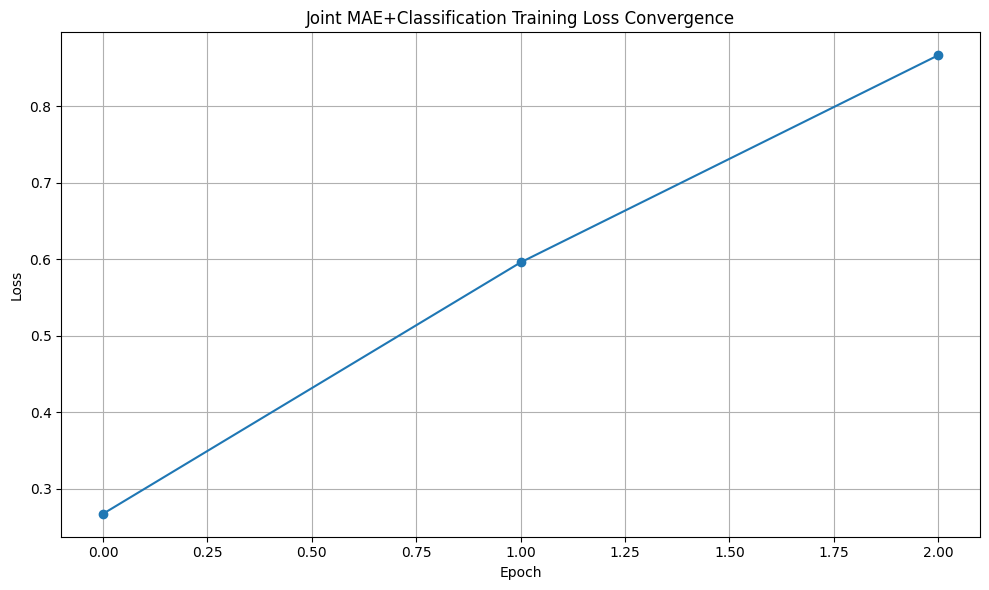

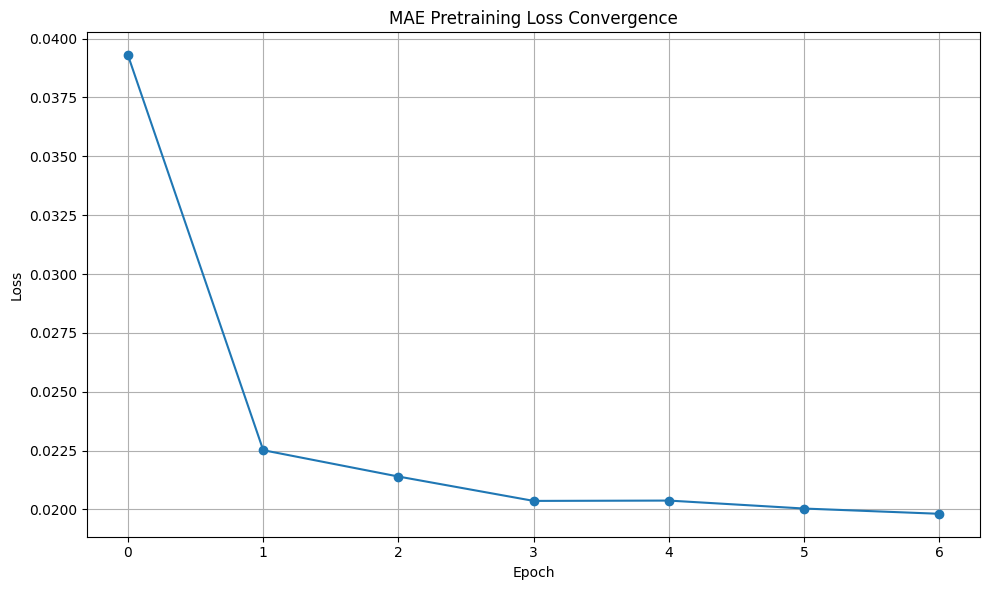

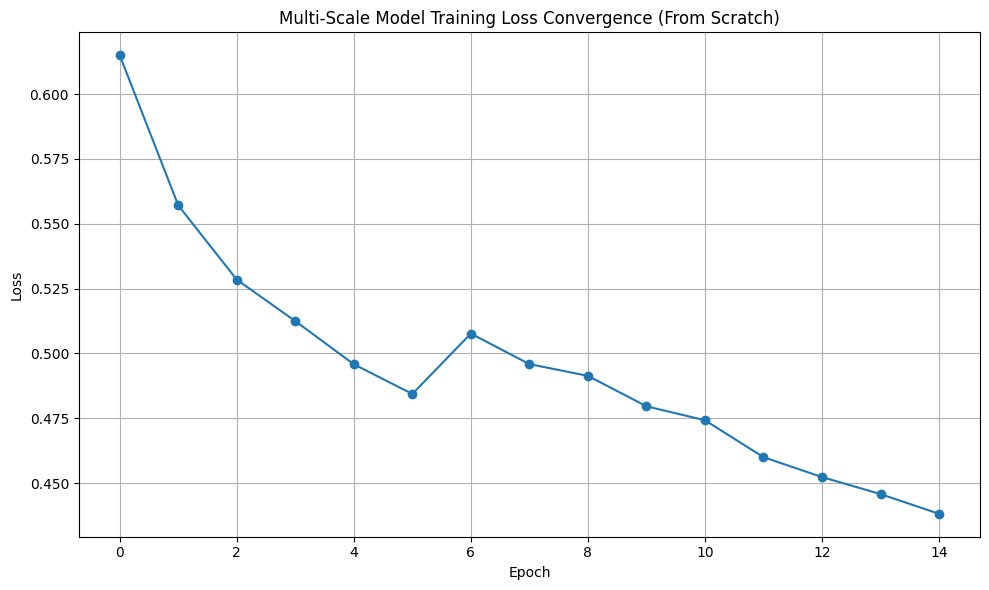

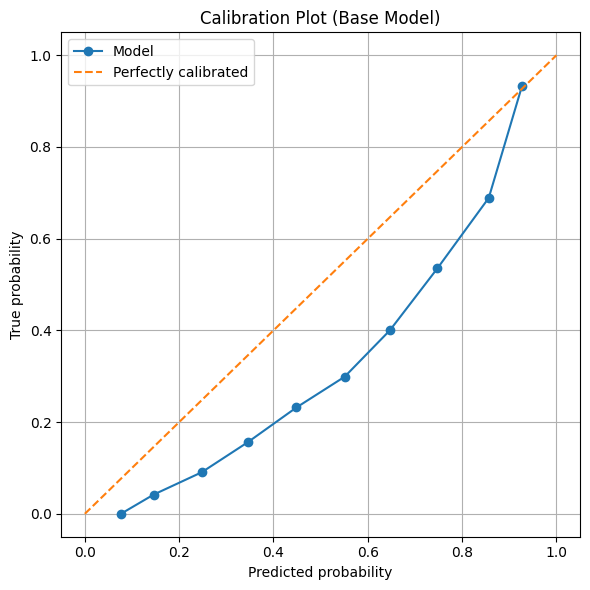

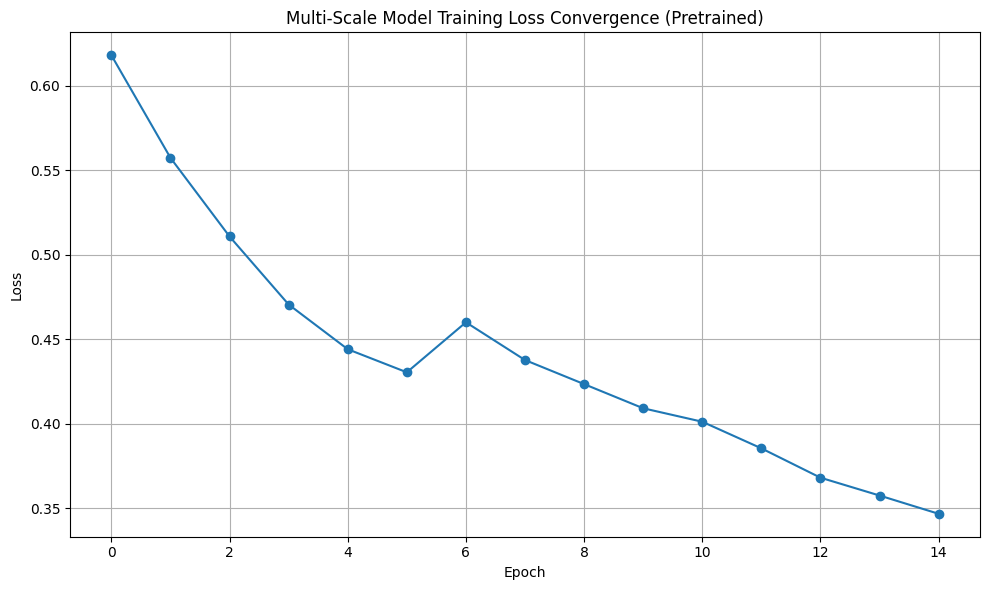

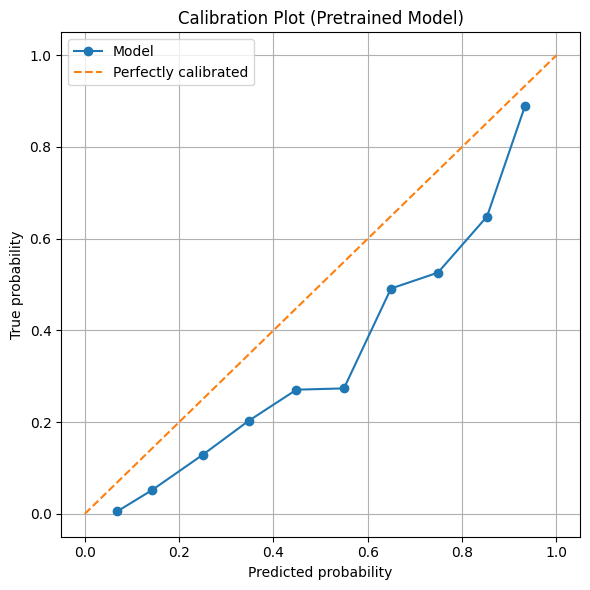

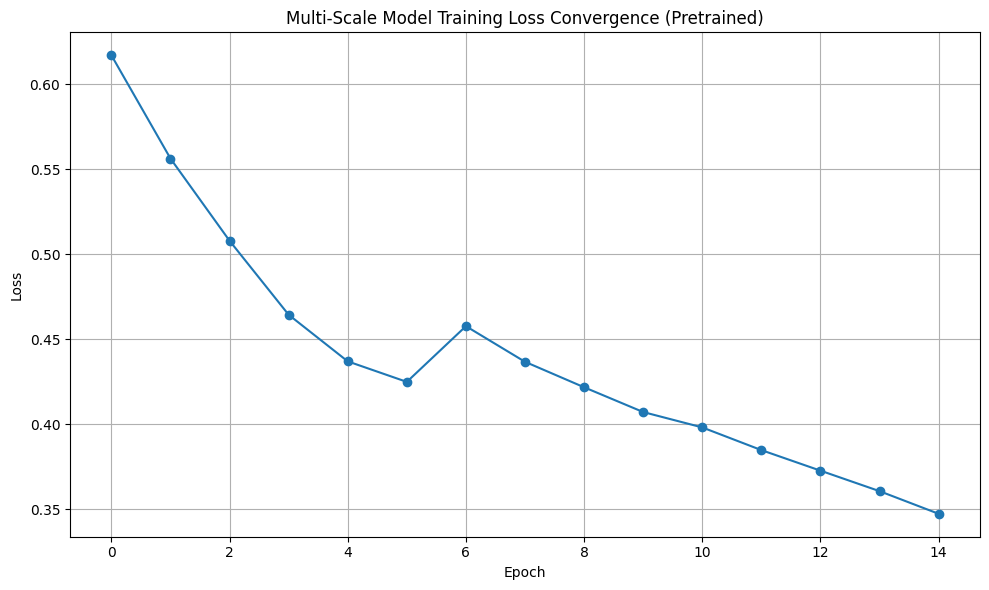

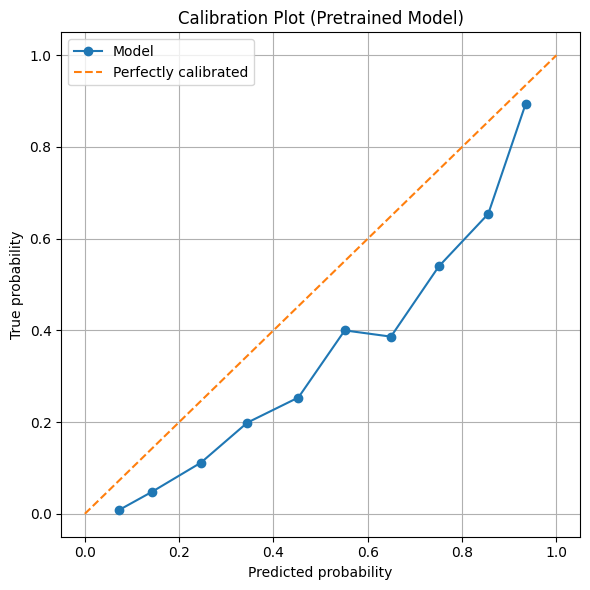

In [39]:
config = {
    'syn_to_real_ratio' : 0.05,
    'val_split'         : 0.12,
    'target_mi_ratio'   : 0.25,

    'mask_ratio'        : 0.25,
    'seg_len'           : 50,
    'augment_strength'  : 'mild',

    'd_model'           : 128,
    'n_heads'           : 8,
    'hidden_dim'        : 128,
    'n_layers_mae'      : 6,
    'n_layers_joint'    : 4,
    'kernel_sizes'      : [5, 9, 15, 25],
    'decoder_dim'       : 128,
    'emb_size'          : 24,

    'lr_mae'            : 3e-4,
    'wd_mae'            : 1e-5,
    'lr_joint'          : 1e-4,
    'wd_joint'          : 1e-3,
    'alpha_start'       : 0.5,
    'alpha_end'         : 1.0,
    'pretrain_epochs'   : 30,
    'warmup_ratio'      : 0.15,
    'learning_rate'     : 1e-4,
    'weight_decay'      : 5e-3,

    'dropout'           : 0.0,
    'encoder_dropout'   : 0.2,
    'gradient_clip_norm': 2.0,
    'early_stop_patience': 2,

    'scheduler_T0'      : 6,
    'scheduler_T_mult'  : 2,
    'eta_min'           : 0.0,

    'batch_size'        : 64,
    'eval_batch_size'   : 128,
    'syn_batch_size'    : 128,

    'seed'              : 42,
    'max_epochs'        : 15,
    'use_mae_pretraining'  : True,
    'use_joint_pretraining' : True,
    'l2_reg'            : 1e-3,
    'use_augmentation'  : True,

    'mae_pretrain_path'   : 'mae_pre.bin',
    'joint_pretrain_path' : 'joint_mae_classifier.bin',
    'base_model_path'     : 'multiscale_base.pt',
    'mae_model_path'      : 'multiscale_mae.pt',
    'joint_model_path'    : 'multiscale_joint.pt',
}

print("RUNNING ECG CLASSIFICATION PIPELINE")

results = run_transformer_pipeline(
    preprocessor, config,
    train_signals, train_numerical, train_categorical, train_superclass,
    valid_signals, valid_numerical, valid_categorical, valid_superclass,
    test_signals, test_numerical, test_categorical, test_superclass,
    syn_X, syn_num, syn_cat, syn_sup
)

print("FINAL RESULTS SUMMARY")

r = results['models_results']
print(f"Base model:   Acc: {r['base']['acc']:.4f}, AUC: {r['base']['auc']:.4f}")
if 'mae' in r:
    print(f"MAE model:    Acc: {r['mae']['acc']:.4f}, AUC: {r['mae']['auc']:.4f}")
if 'joint' in r:
    print(f"Joint model:  Acc: {r['joint']['acc']:.4f}, AUC: {r['joint']['auc']:.4f}")





### Enhanced Multi-Classification RNN

In [ ]:
set_random_seed(719)

#### frac = 0

In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
                train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
                valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
                valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str = None,
                frac: float = 0.1) -> nn.Module:
    """Train ECG classification model with optional pre-trained encoder and scaled encoder LR."""
    set_random_seed(config['seed'])

    # Create dataloaders
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k: v for k, v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

    # Define learning rate scheduler
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer,
    #     max_lr=config['learning_rate'],
    #     epochs=config['epochs'],
    #     steps_per_epoch=len(train_loader),
    #     pct_start=0.3,
    #     anneal_strategy='cos'
    # )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = 'ecg_classifier_base.pth' if pretrain_weights is None else 'ecg_classifier_pre_trained.pth'
            torch.save(model.state_dict(), save_path)

    return model


def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )

    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()

    for epoch in range(3):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 10,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 0.0

    all_idx   = np.arange(len(train_superclass))
    norm_idx  = all_idx[train_superclass['MI'] == 0]
    mi_idx    = all_idx[train_superclass['MI'] == 1]

    n_mi_keep = int(len(mi_idx) * frac)
    mi_keep   = np.random.choice(mi_idx, size=n_mi_keep, replace=False)

    idx_keep  = np.concatenate([norm_idx, mi_keep]).astype(int)

    train_signals_sub     = train_signals[idx_keep]
    train_numerical_sub   = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None, frac=frac)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin', frac=frac)

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 4/4 [00:00<00:00,  8.33it/s]


[pre train] epoch 1: loss=0.7326


100%|██████████| 4/4 [00:00<00:00,  8.29it/s]


[pre train] epoch 2: loss=0.6320


100%|██████████| 4/4 [00:00<00:00,  7.92it/s]


...

Validation superclass multi-label accuracy: 0.8409
Validation superclass multi-label AUC: 0.8548
Validation multi-label accuracy: 0.9339
Validation multi-label AUC: 0.8325
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 43.33it/s]


Test superclass multi-label accuracy: 0.8225
Test superclass multi-label AUC: 0.8311
Test multi-label accuracy: 0.9289
Test multi-label AUC: 0.7843
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 42.59it/s]


Test superclass multi-label accuracy: 0.8450
Test superclass multi-label AUC: 0.8664
Test multi-label accuracy: 0.9357
Test multi-label AUC: 0.8629


#### frac = 0.1

In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
                train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
                valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
                valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str = None,
                frac: float = 0.1) -> nn.Module:
    """Train ECG classification model with optional pre-trained encoder and scaled encoder LR."""
    set_random_seed(config['seed'])

    # Create dataloaders
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k: v for k, v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

    # Define learning rate scheduler
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer,
    #     max_lr=config['learning_rate'],
    #     epochs=config['epochs'],
    #     steps_per_epoch=len(train_loader),
    #     pct_start=0.3,
    #     anneal_strategy='cos'
    # )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = 'ecg_classifier_base.pth' if pretrain_weights is None else 'ecg_classifier_pre_trained.pth'
            torch.save(model.state_dict(), save_path)

    return model


def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )

    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()

    for epoch in range(3):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 10,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 0.1

    idx_keep = (train_superclass
            .assign(idx=np.arange(len(train_superclass)))
            .groupby(strat_col)['idx']
            .apply(lambda x: x.sample(frac=frac, random_state=719))) \
            .explode().values.astype(int)

    train_signals_sub   = train_signals[idx_keep]
    train_numerical_sub = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None, frac=frac)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin', frac=frac)

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )



100%|██████████| 4/4 [00:00<00:00,  8.27it/s]


[pre train] epoch 1: loss=0.6396


100%|██████████| 4/4 [00:00<00:00,  8.76it/s]


[pre train] epoch 2: loss=0.5498


100%|██████████| 4/4 [00:00<00:00,  8.61it/s]


...

Validation superclass multi-label accuracy: 0.8348
Validation superclass multi-label AUC: 0.9020
Validation multi-label accuracy: 0.9339
Validation multi-label AUC: 0.8776
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 45.32it/s]


Test superclass multi-label accuracy: 0.8523
Test superclass multi-label AUC: 0.8889
Test multi-label accuracy: 0.9399
Test multi-label AUC: 0.8624
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 46.33it/s]


Test superclass multi-label accuracy: 0.8610
Test superclass multi-label AUC: 0.9009
Test multi-label accuracy: 0.9417
Test multi-label AUC: 0.8753


#### frac = 0.5

In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
                train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
                valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
                valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str = None,
                frac: float = 0.1) -> nn.Module:
    """Train ECG classification model with optional pre-trained encoder and scaled encoder LR."""
    set_random_seed(config['seed'])

    # Create dataloaders
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k: v for k, v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

    # Define learning rate scheduler
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer,
    #     max_lr=config['learning_rate'],
    #     epochs=config['epochs'],
    #     steps_per_epoch=len(train_loader),
    #     pct_start=0.3,
    #     anneal_strategy='cos'
    # )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = 'ecg_classifier_base.pth' if pretrain_weights is None else 'ecg_classifier_pre_trained.pth'
            torch.save(model.state_dict(), save_path)

    return model


def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )

    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()

    for epoch in range(3):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 12,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 0.5

    idx_keep = (train_superclass
            .assign(idx=np.arange(len(train_superclass)))
            .groupby(strat_col)['idx']
            .apply(lambda x: x.sample(frac=frac, random_state=719))) \
            .explode().values.astype(int)

    train_signals_sub   = train_signals[idx_keep]
    train_numerical_sub = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None, frac=frac)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin', frac=frac)

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 4/4 [00:00<00:00,  8.44it/s]


[pre train] epoch 1: loss=0.6970


100%|██████████| 4/4 [00:00<00:00,  8.43it/s]


[pre train] epoch 2: loss=0.5905


100%|██████████| 4/4 [00:00<00:00,  8.11it/s]


...

Validation superclass multi-label accuracy: 0.8749
Validation superclass multi-label AUC: 0.9157
Validation multi-label accuracy: 0.9473
Validation multi-label AUC: 0.8880
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 46.40it/s]


Test superclass multi-label accuracy: 0.8517
Test superclass multi-label AUC: 0.8897
Test multi-label accuracy: 0.9393
Test multi-label AUC: 0.8530
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 46.07it/s]


Test superclass multi-label accuracy: 0.8787
Test superclass multi-label AUC: 0.9151
Test multi-label accuracy: 0.9488
Test multi-label AUC: 0.9031


#### frac = 1

In [ ]:
class ECGClassifier(nn.Module):

    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):

        super().__init__()

        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)

        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])

        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size, momentum=0.05),
            nn.ReLU()
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:

        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)

        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)

        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)

        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)

        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:

    model.train()
    running_loss = None
    scaler = GradScaler()

    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:

        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()

        labels = torch.cat([superclass_labels, subclass_labels], 1).float()

        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)

        scaler.scale(loss).backward()

        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()

        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')

    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()

    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:

    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []

    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:

        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)

        labels = torch.cat([superclass_labels, subclass_labels], 1).float()

        predictions = model(signals, numerical_features, categorical_features)

        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())

        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]

        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))

    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()

    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
               train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
               valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
               valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str=None) -> nn.Module:

    set_random_seed(config['seed'])

    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k:v for k,v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'],
                          weight_decay=0.01)


    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config['learning_rate'],
        epochs=config['epochs'],
        steps_per_epoch=len(train_loader),
        pct_start=0.3,
        anneal_strategy='cos'
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):


        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            if pretrain_weights is None:
              torch.save(model.state_dict(), 'ecg_classifier_base.pth')
            else:
              torch.save(model.state_dict(), 'ecg_classifier_pre_trained.pth')

    return model

def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):

    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:

            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)

            labels = torch.cat([superclass_labels, subclass_labels], 1).float()

            predictions = model(signals, numerical_features, categorical_features)

            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics


def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):

    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )


    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics


def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()


    for epoch in range(2):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre‑train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin


if __name__ == '__main__':

    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 10,
        'batch_size': 128,
        'learning_rate': 5e-3,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 1

    idx_keep = (train_superclass
            .assign(idx=np.arange(len(train_superclass)))
            .groupby(strat_col)['idx']
            .apply(lambda x: x.sample(frac=frac, random_state=719))) \
            .explode().values.astype(int)

    train_signals_sub   = train_signals[idx_keep]
    train_numerical_sub = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin')

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 3/3 [00:00<00:00,  6.48it/s]


[pre‑train] epoch 1: loss=0.7501


100%|██████████| 3/3 [00:00<00:00,  6.07it/s]


[pre‑train] epoch 2: loss=0.6711


epoch 0 loss: 0.2136: 100%|██████████| 18/18 [00:00<00:00, 38.08it/s]


...

Validation superclass multi-label accuracy: 0.8858
Validation superclass multi-label AUC: 0.9290
Validation multi-label accuracy: 0.9508
Validation multi-label AUC: 0.9038
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 44.74it/s]


Test superclass multi-label accuracy: 0.8841
Test superclass multi-label AUC: 0.9268
Test multi-label accuracy: 0.9507
Test multi-label AUC: 0.9159
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 43.38it/s]


Test superclass multi-label accuracy: 0.8882
Test superclass multi-label AUC: 0.9263
Test multi-label accuracy: 0.9519
Test multi-label AUC: 0.9167


#### others

In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
                train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
                valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
                valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str = None,
                frac: float = 0.1) -> nn.Module:
    """Train ECG classification model with optional pre-trained encoder and scaled encoder LR."""
    set_random_seed(config['seed'])

    # Create dataloaders
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k: v for k, v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

    # Define learning rate scheduler
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer,
    #     max_lr=config['learning_rate'],
    #     epochs=config['epochs'],
    #     steps_per_epoch=len(train_loader),
    #     pct_start=0.3,
    #     anneal_strategy='cos'
    # )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = 'ecg_classifier_base.pth' if pretrain_weights is None else 'ecg_classifier_pre_trained.pth'
            torch.save(model.state_dict(), save_path)

    return model


def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )

    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()

    for epoch in range(3):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 10,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 0.5

    all_idx   = np.arange(len(train_superclass))
    norm_idx  = all_idx[train_superclass['MI'] == 0]
    mi_idx    = all_idx[train_superclass['MI'] == 1]

    n_mi_keep = int(len(mi_idx) * frac)
    mi_keep   = np.random.choice(mi_idx, size=n_mi_keep, replace=False)

    idx_keep  = np.concatenate([norm_idx, mi_keep]).astype(int)

    train_signals_sub     = train_signals[idx_keep]
    train_numerical_sub   = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None, frac=frac)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin', frac=frac)

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 4/4 [00:00<00:00,  7.64it/s]


[pre train] epoch 1: loss=0.7047


100%|██████████| 4/4 [00:00<00:00,  8.02it/s]


[pre train] epoch 2: loss=0.6066


100%|██████████| 4/4 [00:00<00:00,  7.65it/s]


...

Validation superclass multi-label accuracy: 0.8789
Validation superclass multi-label AUC: 0.9191
Validation multi-label accuracy: 0.9476
Validation multi-label AUC: 0.8922
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 42.75it/s]


Test superclass multi-label accuracy: 0.8544
Test superclass multi-label AUC: 0.8968
Test multi-label accuracy: 0.9402
Test multi-label AUC: 0.8756
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 41.19it/s]


Test superclass multi-label accuracy: 0.8749
Test superclass multi-label AUC: 0.9095
Test multi-label accuracy: 0.9473
Test multi-label AUC: 0.8973


In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
                train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
                valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
                valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str = None,
                frac: float = 0.1) -> nn.Module:
    """Train ECG classification model with optional pre-trained encoder and scaled encoder LR."""
    set_random_seed(config['seed'])

    # Create dataloaders
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k: v for k, v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

    # Define learning rate scheduler
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer,
    #     max_lr=config['learning_rate'],
    #     epochs=config['epochs'],
    #     steps_per_epoch=len(train_loader),
    #     pct_start=0.3,
    #     anneal_strategy='cos'
    # )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = 'ecg_classifier_base.pth' if pretrain_weights is None else 'ecg_classifier_pre_trained.pth'
            torch.save(model.state_dict(), save_path)

    return model


def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )

    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()

    for epoch in range(3):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 12,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 1

    idx_keep = (train_superclass
            .assign(idx=np.arange(len(train_superclass)))
            .groupby(strat_col)['idx']
            .apply(lambda x: x.sample(frac=frac, random_state=719))) \
            .explode().values.astype(int)

    train_signals_sub   = train_signals[idx_keep]
    train_numerical_sub = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None, frac=frac)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin', frac=frac)

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 4/4 [00:00<00:00,  7.14it/s]


[pre train] epoch 1: loss=0.6934


100%|██████████| 4/4 [00:00<00:00,  7.90it/s]


[pre train] epoch 2: loss=0.5901


100%|██████████| 4/4 [00:00<00:00,  7.64it/s]


...

Validation superclass multi-label accuracy: 0.8796
Validation superclass multi-label AUC: 0.9249
Validation multi-label accuracy: 0.9481
Validation multi-label AUC: 0.9131
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 42.08it/s]


Test superclass multi-label accuracy: 0.8774
Test superclass multi-label AUC: 0.9201
Test multi-label accuracy: 0.9486
Test multi-label AUC: 0.9123
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 41.93it/s]


Test superclass multi-label accuracy: 0.8757
Test superclass multi-label AUC: 0.9174
Test multi-label accuracy: 0.9479
Test multi-label AUC: 0.9142


In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
                train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
                valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
                valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str = None,
                frac: float = 0.1) -> nn.Module:
    """Train ECG classification model with optional pre-trained encoder and scaled encoder LR."""
    set_random_seed(config['seed'])

    # Create dataloaders
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k: v for k, v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer,
    #     max_lr=config['learning_rate'],
    #     epochs=config['epochs'],
    #     steps_per_epoch=len(train_loader),
    #     pct_start=0.3,
    #     anneal_strategy='cos'
    # )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = 'ecg_classifier_base.pth' if pretrain_weights is None else 'ecg_classifier_pre_trained.pth'
            torch.save(model.state_dict(), save_path)

    return model


def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )

    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()

    for epoch in range(3):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 12,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 0.5

    idx_keep = (train_superclass
            .assign(idx=np.arange(len(train_superclass)))
            .groupby(strat_col)['idx']
            .apply(lambda x: x.sample(frac=frac, random_state=719))) \
            .explode().values.astype(int)

    train_signals_sub   = train_signals[idx_keep]
    train_numerical_sub = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None, frac=frac)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin', frac=frac)

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 4/4 [00:00<00:00,  8.37it/s]


[pre train] epoch 1: loss=0.6970


100%|██████████| 4/4 [00:00<00:00,  8.29it/s]


[pre train] epoch 2: loss=0.5905


100%|██████████| 4/4 [00:00<00:00,  8.34it/s]


...

Validation superclass multi-label accuracy: 0.8749
Validation superclass multi-label AUC: 0.9157
Validation multi-label accuracy: 0.9473
Validation multi-label AUC: 0.8880
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 40.01it/s]


Test superclass multi-label accuracy: 0.8517
Test superclass multi-label AUC: 0.8897
Test multi-label accuracy: 0.9393
Test multi-label AUC: 0.8530
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 41.67it/s]


Test superclass multi-label accuracy: 0.8787
Test superclass multi-label AUC: 0.9151
Test multi-label accuracy: 0.9488
Test multi-label AUC: 0.9031


In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
                train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
                valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
                valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str = None,
                frac: float = 0.1) -> nn.Module:
    """Train ECG classification model with optional pre-trained encoder and scaled encoder LR."""
    set_random_seed(config['seed'])

    # Create dataloaders
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k: v for k, v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

    # Define learning rate scheduler
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer,
    #     max_lr=config['learning_rate'],
    #     epochs=config['epochs'],
    #     steps_per_epoch=len(train_loader),
    #     pct_start=0.3,
    #     anneal_strategy='cos'
    # )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = 'ecg_classifier_base.pth' if pretrain_weights is None else 'ecg_classifier_pre_trained.pth'
            torch.save(model.state_dict(), save_path)

    return model


def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )

    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()

    for epoch in range(15):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 10,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 0.1

    idx_keep = (train_superclass
            .assign(idx=np.arange(len(train_superclass)))
            .groupby(strat_col)['idx']
            .apply(lambda x: x.sample(frac=frac, random_state=719))) \
            .explode().values.astype(int)

    train_signals_sub   = train_signals[idx_keep]
    train_numerical_sub = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None, frac=frac)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin', frac=frac)

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 3/3 [00:00<00:00,  7.24it/s]


[pre train] epoch 1: loss=0.5063


100%|██████████| 3/3 [00:00<00:00,  7.17it/s]


[pre train] epoch 2: loss=0.4291


100%|██████████| 3/3 [00:00<00:00,  7.36it/s]


...

Validation superclass multi-label accuracy: 0.8209
Validation superclass multi-label AUC: 0.8803
Validation multi-label accuracy: 0.9285
Validation multi-label AUC: 0.8265
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 45.93it/s]


Test superclass multi-label accuracy: 0.8384
Test superclass multi-label AUC: 0.8729
Test multi-label accuracy: 0.9352
Test multi-label AUC: 0.8130
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 45.57it/s]


Test superclass multi-label accuracy: 0.8291
Test superclass multi-label AUC: 0.8786
Test multi-label accuracy: 0.9309
Test multi-label AUC: 0.8329


In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
                train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
                valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
                valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str = None,
                frac: float = 0.1) -> nn.Module:
    """Train ECG classification model with optional pre-trained encoder and scaled encoder LR."""
    set_random_seed(config['seed'])

    # Create dataloaders
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)

    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k: v for k, v in state.items() if "output" not in k},
                              strict=False)

    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

    # Define learning rate scheduler
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer,
    #     max_lr=config['learning_rate'],
    #     epochs=config['epochs'],
    #     steps_per_epoch=len(train_loader),
    #     pct_start=0.3,
    #     anneal_strategy='cos'
    # )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )

    loss_fn = nn.BCEWithLogitsLoss().to(device)

    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )

        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = 'ecg_classifier_base.pth' if pretrain_weights is None else 'ecg_classifier_pre_trained.pth'
            torch.save(model.state_dict(), save_path)

    return model


def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )

    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]

    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }

    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))

    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )

    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )

    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)

    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()

    for epoch in range(5):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)

    config = {
        'seed': 719,
        'epochs': 10,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }

    strat_col = 'MI'
    frac = 0.1

    idx_keep = (train_superclass
            .assign(idx=np.arange(len(train_superclass)))
            .groupby(strat_col)['idx']
            .apply(lambda x: x.sample(frac=frac, random_state=719))) \
            .explode().values.astype(int)

    train_signals_sub   = train_signals[idx_keep]
    train_numerical_sub = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)

    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None, frac=frac)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin', frac=frac)

    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()

    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 4/4 [00:00<00:00,  8.25it/s]


[pre train] epoch 1: loss=0.6934


100%|██████████| 4/4 [00:00<00:00,  7.92it/s]


[pre train] epoch 2: loss=0.5901


100%|██████████| 4/4 [00:00<00:00,  7.91it/s]


...

Validation superclass multi-label accuracy: 0.8434
Validation superclass multi-label AUC: 0.8816
Validation multi-label accuracy: 0.9360
Validation multi-label AUC: 0.8142
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 43.19it/s]


Test superclass multi-label accuracy: 0.8384
Test superclass multi-label AUC: 0.8729
Test multi-label accuracy: 0.9352
Test multi-label AUC: 0.8130
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 47.09it/s]


Test superclass multi-label accuracy: 0.8464
Test superclass multi-label AUC: 0.8842
Test multi-label accuracy: 0.9377
Test multi-label AUC: 0.8410


In [ ]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        subclass_labels = subclass_labels.to(device).long()
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels, subclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        subclass_labels = subclass_labels.to(device)
        labels = torch.cat([superclass_labels, subclass_labels], 1).float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    print('Validation superclass multi-label accuracy: {:.4f}'.format(
        (all_targets[:, :superclass_count] == (all_predictions[:, :superclass_count] >= 0.5)).mean()
    ))
    print('Validation superclass multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets[:, :superclass_count],
                     all_predictions[:, :superclass_count],
                     average='macro')
    ))
    print('Validation multi-label accuracy: {:.4f}'.format(
        (all_targets == (all_predictions >= 0.5)).mean()
    ))
    print('Validation multi-label AUC: {:.4f}'.format(
        roc_auc_score(all_targets, all_predictions, average='macro')
    ))
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
               train_superclass: np.ndarray, train_subclass: np.ndarray, valid_signals: np.ndarray,
               valid_numerical: np.ndarray, valid_categorical: np.ndarray, valid_superclass: np.ndarray,
               valid_subclass: np.ndarray, preprocessor, config: dict, pretrain_weights: str=None) -> nn.Module:
    set_random_seed(config['seed'])
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, train_subclass, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, valid_subclass, config['batch_size']
    )
    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        train_superclass.shape[1] + train_subclass.shape[1]
    ).to(device)
    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k:v for k,v in state.items() if "output" not in k},
                              strict=False)
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'],
                          weight_decay=0.01)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config['learning_rate'],
        epochs=config['epochs'],
        steps_per_epoch=len(train_loader),
        pct_start=0.3,
        anneal_strategy='cos'
    )
    loss_fn = nn.BCEWithLogitsLoss().to(device)
    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )
        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            if pretrain_weights is None:
              torch.save(model.state_dict(), 'ecg_classifier_base.pth')
            else:
              torch.save(model.state_dict(), 'ecg_classifier_pre_trained.pth')
    return model

def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier_base.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass
    )
    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        test_superclass.shape[1] + test_subclass.shape[1]
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels, subclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            subclass_labels = subclass_labels.to(device)
            labels = torch.cat([superclass_labels, subclass_labels], 1).float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    superclass_count = superclass_labels.shape[1]
    metrics = {
        'superclass_accuracy': (all_targets[:, :superclass_count] ==
                              (all_predictions[:, :superclass_count] >= 0.5)).mean(),
        'superclass_auc': roc_auc_score(
            all_targets[:, :superclass_count],
            all_predictions[:, :superclass_count],
            average='macro'
        ),
        'overall_accuracy': (all_targets == (all_predictions >= 0.5)).mean(),
        'overall_auc': roc_auc_score(all_targets, all_predictions, average='macro')
    }
    print('Test superclass multi-label accuracy: {:.4f}'.format(metrics['superclass_accuracy']))
    print('Test superclass multi-label AUC: {:.4f}'.format(metrics['superclass_auc']))
    print('Test multi-label accuracy: {:.4f}'.format(metrics['overall_accuracy']))
    print('Test multi-label AUC: {:.4f}'.format(metrics['overall_auc']))
    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, test_subclass, model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, model_path
    )
    plot_confusion_matrices(
        predictions, targets, preprocessor,
        save_path='confusion_matrices.png' if save_plots else None
    )
    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)
    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()
    for epoch in range(25):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre‑train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    syn_sup_bin = syn_sup[["MI"]]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)
    config = {
        'seed': 719,
        'epochs': 6,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }
    strat_col = 'MI'
    frac = 0.1
    idx_keep = (train_superclass
            .assign(idx=np.arange(len(train_superclass)))
            .groupby(strat_col)['idx']
            .apply(lambda x: x.sample(frac=frac, random_state=719))) \
            .explode().values.astype(int)
    train_signals_sub   = train_signals[idx_keep]
    train_numerical_sub = train_numerical.iloc[idx_keep].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[idx_keep].reset_index(drop=True)
    train_superclass_sub  = train_superclass.iloc[idx_keep].reset_index(drop=True)
    train_subclass_sub    = train_subclass.iloc[idx_keep].reset_index(drop=True)
    model_base = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights=None)
    model_pre_trained = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
    train_superclass_sub, train_subclass_sub, valid_signals, valid_numerical,
    valid_categorical, valid_superclass, valid_subclass, preprocessor, config,
        pretrain_weights='ecg_encoder_pre.bin')
    del model_base
    del model_pre_trained
    torch.cuda.empty_cache()
    print('Running evaluation with the base model ... ')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_base.pth'
    )
    print('Running evaluation with pre-trained model...')
    predictions, targets, metrics = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, test_subclass, save_plots=True, model_path='ecg_classifier_pre_trained.pth'
    )




100%|██████████| 2/2 [00:00<00:00,  5.17it/s]


[pre‑train] epoch 1: loss=0.7141


100%|██████████| 2/2 [00:00<00:00,  5.08it/s]


[pre‑train] epoch 2: loss=0.6620


100%|██████████| 2/2 [00:00<00:00,  5.10it/s]


...

Validation superclass multi-label accuracy: 0.8391
Validation superclass multi-label AUC: 0.8765
Validation multi-label accuracy: 0.9333
Validation multi-label AUC: 0.8264
Running evaluation with the base model ... 


100%|██████████| 18/18 [00:00<00:00, 43.30it/s]


Test superclass multi-label accuracy: 0.8337
Test superclass multi-label AUC: 0.8606
Test multi-label accuracy: 0.9327
Test multi-label AUC: 0.8081
Running evaluation with pre-trained model...


100%|██████████| 18/18 [00:00<00:00, 45.59it/s]


Test superclass multi-label accuracy: 0.8438
Test superclass multi-label AUC: 0.8710
Test multi-label accuracy: 0.9352
Test multi-label AUC: 0.8247


### Binary preperation

In [20]:
def get_binary_MI_vs_NORM(df):
    df_bin = df.copy()
    is_mi_only = (df_bin['MI'] == 1) & (df_bin.drop(columns='MI') == 0).all(axis=1)
    is_norm_only = (df_bin['NORM'] == 1) & (df_bin.drop(columns='NORM') == 0).all(axis=1)
    binary_df = df_bin[is_mi_only | is_norm_only].copy()
    return binary_df.reset_index(drop=True)


In [21]:
train_superclass_bin = get_binary_MI_vs_NORM(train_superclass)
valid_superclass_bin = get_binary_MI_vs_NORM(valid_superclass)
test_superclass_bin  = get_binary_MI_vs_NORM(test_superclass)

train_signals_bin     = train_signals[train_superclass_bin.index]
train_numerical_bin   = train_numerical.iloc[train_superclass_bin.index].reset_index(drop=True)
train_categorical_bin = train_categorical.iloc[train_superclass_bin.index].reset_index(drop=True)

valid_signals_bin     = valid_signals[valid_superclass_bin.index]
valid_numerical_bin   = valid_numerical.iloc[valid_superclass_bin.index].reset_index(drop=True)
valid_categorical_bin = valid_categorical.iloc[valid_superclass_bin.index].reset_index(drop=True)

test_signals_bin      = test_signals[test_superclass_bin.index]
test_numerical_bin    = test_numerical.iloc[test_superclass_bin.index].reset_index(drop=True)
test_categorical_bin  = test_categorical.iloc[test_superclass_bin.index].reset_index(drop=True)


### Binary RNN

In [ ]:
class ECGClassifier(nn.Module):

    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int):
        super().__init__()

        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)

        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])

        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:

        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        labels = superclass_labels.float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        labels = superclass_labels.float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    probs = torch.sigmoid(torch.from_numpy(all_predictions)).numpy().squeeze()
    truth = all_targets.squeeze()
    acc = ((probs >= 0.5) == truth).mean()
    auc = roc_auc_score(truth, probs)
    print(f"Validation Binary MI accuracy: {acc:.4f}, AUC: {auc:.4f}")
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
               train_superclass: np.ndarray,
               valid_signals: np.ndarray,
               valid_numerical: np.ndarray, valid_categorical: np.ndarray,
               valid_superclass: np.ndarray,
               preprocessor, config: dict, pretrain_weights: str=None) -> nn.Module:
    set_random_seed(config['seed'])
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, None, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, None, config['batch_size']
    )
    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        1
    ).to(device)
    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k:v for k,v in state.items() if "output" not in k},
                              strict=False)
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'],
                          weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config['epochs'],
        eta_min=config['learning_rate'] * 0.01  # minimum LR 100x smaller
    )
    loss_fn = nn.BCEWithLogitsLoss().to(device)
    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )
        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            if pretrain_weights is None:
              torch.save(model.state_dict(), 'ecg_classifier_base.pth')
            else:
              torch.save(model.state_dict(), 'ecg_classifier_pre_trained.pth')
    return model

def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass,
                  model_path='ecg_classifier.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, None
    )
    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], 128, categorical_sizes, 30,
        test_numerical.shape[1], 128,
        1
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            labels = superclass_labels.float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    probs = torch.sigmoid(torch.from_numpy(all_predictions)).numpy().squeeze()
    truth = all_targets.squeeze()
    acc = ((probs >= 0.5) == truth).mean()
    auc = roc_auc_score(truth, probs)
    metrics = {
        'binary_accuracy': acc,
        'binary_auc': auc
    }
    print(f'Test Binary MI accuracy: {acc:.4f}')
    print(f'Test Binary MI AUC: {auc:.4f}')
    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass,
                  model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass,
        model_path
    )
    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = 128,
        categorical_sizes = categorical_sizes,
        embedding_size = 30,
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = 128,
        num_outputs = 1
    ).to(device)
    loss_fn   = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()
    for epoch in range(3):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre‑train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), "ecg_encoder_pre.bin")
    return model_bin

if __name__ == '__main__':
    print("\nStarting synthetic pre-training...")
    syn_sup_bin = syn_sup[['MI']]
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    pretrain_on_synthetic(syn_loader, categorical_sizes, device)
    print("Synthetic pre-training finished. Weights saved to ecg_encoder_pre.bin")
    pretrain_weights_path = 'ecg_encoder_pre.bin'
    y_train_bin = train_superclass[['MI']]
    y_valid_bin = valid_superclass[['MI']]
    y_test_bin  = test_superclass[['MI']]
    strat_col = 'MI'
    frac = 0.1
    print(f"\nStratifying training data based on '{strat_col}', keeping {frac*100}%...")
    config = {
        'seed': 719,
        'epochs': 10,
        'batch_size': 128,
        'learning_rate': 1e-2,
        'step_size': 2,
        'gamma': 0.1,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128
    }
    train_superclass = train_superclass.reset_index(drop=True)
    pos_idx = train_superclass.index[train_superclass['MI'] == 1].to_numpy()
    neg_idx = train_superclass.index[train_superclass['MI'] == 0].to_numpy()
    rng = np.random.default_rng(config['seed'])
    n_keep = max(1, int(len(pos_idx) * frac))
    keep_pos = rng.choice(pos_idx, size=n_keep, replace=False)
    keep_idx = np.concatenate([neg_idx, keep_pos])
    keep_idx.sort()
    train_signals_sub     = train_signals[keep_idx]
    train_numerical_sub   = train_numerical.iloc[keep_idx].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[keep_idx].reset_index(drop=True)
    y_train_bin_sub       = y_train_bin.iloc[keep_idx].reset_index(drop=True)
    print(f"Original training size: {len(train_signals)}, Subsampled size: {len(train_signals_sub)}")
    print("\nTraining base binary model on subset...")
    model_base_binary = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
        y_train_bin_sub,
        valid_signals, valid_numerical, valid_categorical,
        y_valid_bin,
        preprocessor, config,
        pretrain_weights=None
    )
    torch.save(model_base_binary.state_dict(), 'ecg_classifier_binary_base.pth')
    del model_base_binary
    print("\nTraining pre-trained binary model on subset...")
    model_pre_trained_binary = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
        y_train_bin_sub,
        valid_signals, valid_numerical, valid_categorical,
        y_valid_bin,
        preprocessor, config,
        pretrain_weights=pretrain_weights_path
    )
    torch.save(model_pre_trained_binary.state_dict(), 'ecg_classifier_binary_pre_trained.pth')
    del model_pre_trained_binary
    torch.cuda.empty_cache()
    print('\nRunning evaluation with the base binary model...')
    predictions_base, targets_base, metrics_base = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        y_test_bin,
        save_plots=False,
        model_path='ecg_classifier_binary_base.pth'
    )
    print('\nRunning evaluation with pre-trained binary model...')
    predictions_pre, targets_pre, metrics_pre = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        y_test_bin,
        save_plots=False,
        model_path='ecg_classifier_binary_pre_trained.pth'
    )





Starting synthetic pre-training...


100%|██████████| 4/4 [00:00<00:00,  7.80it/s]


[pre‑train] epoch 1: loss=0.6400


100%|██████████| 4/4 [00:00<00:00,  7.87it/s]


[pre‑train] epoch 2: loss=0.5548


...

Validation Binary MI accuracy: 0.7779, AUC: 0.8758

Running evaluation with the base binary model...


100%|██████████| 18/18 [00:00<00:00, 41.99it/s]

Test Binary MI accuracy: 0.7599
Test Binary MI AUC: 0.8446

Running evaluation with pre-trained binary model...



100%|██████████| 18/18 [00:00<00:00, 41.67it/s]

Test Binary MI accuracy: 0.7798
Test Binary MI AUC: 0.8818


### Binary RNN with Ratio

In [18]:
class ECGClassifier(nn.Module):
    def __init__(self, signal_channels: int, gru_hidden_size: int, categorical_sizes: list,
                 embedding_size: int, numerical_size: int, hidden_size: int, num_outputs: int,
                 dropout_rate: float = 0.5):
        super().__init__()
        self.gru = nn.GRU(signal_channels, gru_hidden_size,
                         batch_first=True, bidirectional=True)
        self.embeddings = nn.ModuleList([
            nn.Embedding(size, embedding_size)
            for size in categorical_sizes
        ])
        self.dense = nn.Sequential(
            nn.Linear(
                gru_hidden_size * 4 + embedding_size * len(categorical_sizes) + numerical_size,
                hidden_size
            ),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        self.output = nn.Linear(hidden_size, num_outputs)

    def forward(self, signal: torch.Tensor, numerical_features: torch.Tensor,
                categorical_features: torch.Tensor) -> torch.Tensor:
        signal = signal.view(signal.shape[0], signal.shape[1], -1)
        signal, _ = self.gru(signal)
        avg_pool = torch.mean(signal, 1)
        max_pool, _ = torch.max(signal, 1)
        categorical_embeddings = []
        for i, embed in enumerate(self.embeddings):
            categorical_embeddings.append(embed(categorical_features[:, i].long()))
        categorical_embeddings = torch.cat(categorical_embeddings, 1)
        features = torch.cat([avg_pool, max_pool, categorical_embeddings, numerical_features], 1)
        x = self.dense(features)
        x = self.output(x)
        return x

def train_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
               train_loader: DataLoader, device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
               update_scheduler_per_batch: bool = False) -> float:
    model.train()
    running_loss = None
    scaler = GradScaler()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device).long()
        labels = superclass_labels.float()
        with autocast():
            predictions = model(signals, numerical_features, categorical_features)
            loss = loss_fn(predictions, labels)
        scaler.scale(loss).backward()
        if running_loss is None:
            running_loss = loss.item()
        else:
            running_loss = running_loss * 0.99 + loss.item() * 0.01
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        if scheduler is not None and update_scheduler_per_batch:
            scheduler.step()
        pbar.set_description(f'epoch {epoch} loss: {running_loss:.4f}')
    if scheduler is not None and not update_scheduler_per_batch:
        scheduler.step()
    return running_loss

def validate_epoch(epoch: int, model: nn.Module, loss_fn: nn.Module, val_loader: DataLoader,
                 device: torch.device, scheduler: optim.lr_scheduler._LRScheduler = None,
                 update_scheduler_on_loss: bool = False) -> tuple:
    model.eval()
    loss_sum = 0
    sample_count = 0
    all_predictions = []
    all_targets = []
    pbar = tqdm(enumerate(val_loader), total=len(val_loader))
    for step, (signals, numerical_features, categorical_features,
               superclass_labels) in pbar:
        signals = signals.to(device).float()
        numerical_features = numerical_features.to(device).float()
        categorical_features = categorical_features.to(device).long()
        superclass_labels = superclass_labels.to(device)
        labels = superclass_labels.float()
        predictions = model(signals, numerical_features, categorical_features)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_targets.append(labels.detach().cpu().numpy())
        loss = loss_fn(predictions, labels)
        loss_sum += loss.item() * labels.shape[0]
        sample_count += labels.shape[0]
        pbar.set_description(f'epoch {epoch} loss: {loss_sum/sample_count:.4f}')
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    probs = torch.sigmoid(torch.from_numpy(all_predictions)).numpy().squeeze()
    truth = all_targets.squeeze()
    acc = ((probs >= 0.5) == truth).mean()
    auc = roc_auc_score(truth, probs)
    print(f"Validation Binary MI accuracy: {acc:.4f}, AUC: {auc:.4f}")
    if scheduler is not None:
        if update_scheduler_on_loss:
            scheduler.step(loss_sum/sample_count)
        else:
            scheduler.step()
    return all_targets, all_predictions, loss_sum/sample_count

def train_model(train_signals: np.ndarray, train_numerical: np.ndarray, train_categorical: np.ndarray,
               train_superclass: np.ndarray,
               valid_signals: np.ndarray,
               valid_numerical: np.ndarray, valid_categorical: np.ndarray,
               valid_superclass: np.ndarray,
               preprocessor, config: dict, pretrain_weights: str=None) -> nn.Module:
    set_random_seed(config['seed'])
    train_loader = create_dataloader(
        train_signals, train_numerical, train_categorical,
        train_superclass, None, config['batch_size']
    )
    val_loader = create_dataloader(
        valid_signals, valid_numerical, valid_categorical,
        valid_superclass, None, config['batch_size']
    )
    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        train_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], train_numerical.shape[1], config['hidden_size'],
        1, dropout_rate=config.get('dropout_rate', 0.5)
    ).to(device)
    if pretrain_weights is not None:
        state = torch.load(pretrain_weights, map_location=device)
        model.load_state_dict({k:v for k,v in state.items() if "output" not in k},
                              strict=False)
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'],
                          weight_decay=config.get('weight_decay', 0.01))
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config['learning_rate'],
        epochs=config['epochs'],
        steps_per_epoch=len(train_loader),
        pct_start=0.3,
        anneal_strategy='cos'
    )
    loss_fn = nn.BCEWithLogitsLoss().to(device)
    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        train_loss = train_epoch(
            epoch, model, loss_fn, optimizer, train_loader, device,
            scheduler=scheduler, update_scheduler_per_batch=True
        )
        with torch.no_grad():
            val_targets, val_predictions, val_loss = validate_epoch(
                epoch, model, loss_fn, val_loader, device,
                scheduler=None, update_scheduler_on_loss=False
            )
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            if pretrain_weights is None:
              torch.save(model.state_dict(), 'ecg_classifier_base.pth')
            else:
              torch.save(model.state_dict(), 'ecg_classifier_pre_trained.pth')
    return model

def evaluate_model(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, config,
                  model_path='ecg_classifier.pth'):
    test_loader = create_dataloader(
        test_signals, test_numerical, test_categorical,
        test_superclass, None
    )
    categorical_sizes = [len(encoder.classes_) for encoder in preprocessor.label_encoders]
    model = ECGClassifier(
        test_signals.shape[2], config['gru_hidden_size'], categorical_sizes,
        config['embedding_size'], test_numerical.shape[1], config['hidden_size'],
        1, dropout_rate=config['dropout_rate']
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader))
        for step, (signals, numerical_features, categorical_features,
                   superclass_labels) in pbar:
            signals = signals.to(device).float()
            numerical_features = numerical_features.to(device).float()
            categorical_features = categorical_features.to(device).long()
            superclass_labels = superclass_labels.to(device)
            labels = superclass_labels.float()
            predictions = model(signals, numerical_features, categorical_features)
            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(labels.detach().cpu().numpy())
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    probs = torch.sigmoid(torch.from_numpy(all_predictions)).numpy().squeeze()
    truth = all_targets.squeeze()
    acc = ((probs >= 0.5) == truth).mean()
    auc = roc_auc_score(truth, probs)
    metrics = {
        'binary_accuracy': acc,
        'binary_auc': auc
    }
    print(f'Test Binary MI accuracy: {acc:.4f}')
    print(f'Test Binary MI AUC: {auc:.4f}')
    return all_predictions, all_targets, metrics

def run_evaluation(preprocessor, test_signals, test_numerical, test_categorical,
                  test_superclass, config,
                  model_path='ecg_classifier.pth',
                  save_plots=False):
    predictions, targets, metrics = evaluate_model(
        preprocessor, test_signals, test_numerical, test_categorical,
        test_superclass, config,
        model_path
    )
    return predictions, targets, metrics

def pretrain_on_synthetic(syn_loader, categorical_sizes, config, device='cuda'):
    model_bin = ECGClassifier(
        signal_channels = 12,
        gru_hidden_size = config['gru_hidden_size'],
        categorical_sizes = categorical_sizes,
        embedding_size = config['embedding_size'],
        numerical_size = next(iter(syn_loader))[1].shape[1],
        hidden_size = config['hidden_size'],
        num_outputs = 1,
        dropout_rate = config['dropout_rate']
    ).to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    optimiser = optim.AdamW(model_bin.parameters(), lr=1e-4)
    model_bin.train()
    for epoch in range(config['pretrain_epochs']):
        epoch_loss = 0
        for X, num, cat, y in tqdm(syn_loader):
            X, num, cat, y = X.to(device), num.to(device), cat.to(device), y.to(device)
            optimiser.zero_grad()
            pred = model_bin(X, num, cat)
            loss = loss_fn(pred, y)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * y.size(0)
        print(f"[pre‑train] epoch {epoch+1}: loss={epoch_loss/len(syn_loader.dataset):.4f}")
    torch.save(model_bin.state_dict(), config['pretrain_save_path'])
    return model_bin

def prepare_synthetic_data(syn_X, syn_num, syn_cat, syn_sup, preprocessor, config, device):
    print("\nStarting synthetic pre-training...")
    syn_sup_bin = syn_sup[['MI']]
    categorical_sizes = [len(enc.classes_) for enc in preprocessor.label_encoders]
    syn_loader = create_dataloader(syn_X, syn_num, syn_cat, syn_sup_bin, None, batch_size=256)
    pretrain_on_synthetic(syn_loader, categorical_sizes, config, device)
    print("Synthetic pre-training finished. Weights saved to", config['pretrain_save_path'])
    return config['pretrain_save_path'], categorical_sizes

def sample_real_data(train_superclass, train_signals, train_numerical, train_categorical, config):
    y_train_bin = train_superclass[['MI']]
    num_syn_samples = len(syn_X)
    total_real_needed = int(num_syn_samples / config['syn_to_real_ratio'])
    print("\nSynthetic-to-real ratio:", config['syn_to_real_ratio'])
    print("Number of synthetic samples:", num_syn_samples)
    print("Target number of real samples:", total_real_needed)
    mi_mask = y_train_bin['MI'] == 1
    non_mi_mask = y_train_bin['MI'] == 0
    mi_indices = np.where(mi_mask)[0]
    non_mi_indices = np.where(non_mi_mask)[0]
    print("Original real MI samples:", len(mi_indices))
    print("Original real NORM samples:", len(non_mi_indices))
    mi_ratio = len(mi_indices) / (len(mi_indices) + len(non_mi_indices))
    non_mi_ratio = 1 - mi_ratio
    real_MI_keep = int(total_real_needed * mi_ratio)
    real_non_MI_keep = int(total_real_needed * non_mi_ratio)
    print("Number of MI samples to keep:", real_MI_keep)
    print("Number of NORM samples to keep:", real_non_MI_keep)
    rng = np.random.RandomState(config['random_seed'])
    mi_sample_idx = rng.choice(mi_indices, size=min(real_MI_keep, len(mi_indices)), replace=False)
    non_mi_sample_idx = rng.choice(non_mi_indices, size=min(real_non_MI_keep, len(non_mi_indices)), replace=False)
    all_keep_idx = np.concatenate([mi_sample_idx, non_mi_sample_idx])
    train_signals_sub = train_signals[all_keep_idx]
    train_numerical_sub = train_numerical.iloc[all_keep_idx].reset_index(drop=True)
    train_categorical_sub = train_categorical.iloc[all_keep_idx].reset_index(drop=True)
    y_train_bin_sub = y_train_bin.iloc[all_keep_idx].reset_index(drop=True)
    return train_signals_sub, train_numerical_sub, train_categorical_sub, y_train_bin_sub, y_train_bin

def run_training_pipeline(preprocessor, config,
                        train_signals, train_numerical, train_categorical, train_superclass,
                        valid_signals, valid_numerical, valid_categorical, valid_superclass,
                        test_signals, test_numerical, test_categorical, test_superclass):
    pretrain_weights_path, categorical_sizes = prepare_synthetic_data(
        syn_X, syn_num, syn_cat, syn_sup, preprocessor, config, device)
    train_signals_sub, train_numerical_sub, train_categorical_sub, y_train_bin_sub, y_train_bin = sample_real_data(
        train_superclass, train_signals, train_numerical, train_categorical, config)
    y_valid_bin = valid_superclass[['MI']]
    y_test_bin = test_superclass[['MI']]
    training_config = {
        'seed': config['seed'],
        'epochs': config['epochs'],
        'batch_size': config['batch_size'],
        'learning_rate': config['learning_rate'],
        'gru_hidden_size': config['gru_hidden_size'],
        'embedding_size': config['embedding_size'],
        'hidden_size': config['hidden_size'],
        'dropout_rate': config['dropout_rate']
    }
    print("\nTraining base binary model on subset...")
    model_base_binary = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
        y_train_bin_sub,
        valid_signals, valid_numerical, valid_categorical,
        y_valid_bin,
        preprocessor, training_config,
        pretrain_weights=None
    )
    torch.save(model_base_binary.state_dict(), config['base_model_save_path'])
    del model_base_binary
    print("\nTraining pre-trained binary model on subset...")
    model_pre_trained_binary = train_model(
        train_signals_sub, train_numerical_sub, train_categorical_sub,
        y_train_bin_sub,
        valid_signals, valid_numerical, valid_categorical,
        y_valid_bin,
        preprocessor, training_config,
        pretrain_weights=pretrain_weights_path
    )
    torch.save(model_pre_trained_binary.state_dict(), config['pretrained_model_save_path'])
    del model_pre_trained_binary
    torch.cuda.empty_cache()
    print('\nRunning evaluation with the base binary model...')
    predictions_base, targets_base, metrics_base = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        y_test_bin, config,
        save_plots=False,
        model_path=config['base_model_save_path']
    )
    print('\nRunning evaluation with pre-trained binary model...')
    predictions_pre, targets_pre, metrics_pre = run_evaluation(
        preprocessor, test_signals, test_numerical, test_categorical,
        y_test_bin, config,
        save_plots=False,
        model_path=config['pretrained_model_save_path']
    )
    print(f"\nEvaluation results with syn_to_real_ratio={config['syn_to_real_ratio']}")
    print("\n=== Final Comparison ===")
    print(f"Base model   →  Acc: {metrics_base['binary_accuracy']:.4f}, AUC: {metrics_base['binary_auc']:.4f}")
    print(f"Pre-trained  →  Acc: {metrics_pre['binary_accuracy']:.4f}, AUC: {metrics_pre['binary_auc']:.4f}")
    return {
        'base_model': {
            'metrics': metrics_base,
            'predictions': predictions_base,
            'targets': targets_base
        },
        'pretrained_model': {
            'metrics': metrics_pre,
            'predictions': predictions_pre,
            'targets': targets_pre
        }
    }




#### frac = 0.05

In [19]:

if __name__ == '__main__':
    config = {
        'syn_to_real_ratio': 0.05,
        'random_seed': 42,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128,
        'dropout_rate': 0.25,
        'seed': 719,
        'epochs': 20,
        'pretrain_epochs': 3,  # Number of epochs for pretraining
        'batch_size': 128,
        'learning_rate': 5e-4,
        'weight_decay': 0.01,
        'pretrain_save_path': 'ecg_encoder_pre.bin',
        'base_model_save_path': 'ecg_classifier_binary_base.pth',
        'pretrained_model_save_path': 'ecg_classifier_binary_pre_trained.pth'
    }
    results = run_training_pipeline(
        preprocessor, config,
        train_signals, train_numerical, train_categorical, train_superclass,
        valid_signals, valid_numerical, valid_categorical, valid_superclass,
        test_signals, test_numerical, test_categorical, test_superclass
    )


Starting synthetic pre-training...


100%|██████████| 4/4 [00:01<00:00,  2.95it/s]


[pre‑train] epoch 1: loss=0.6349


100%|██████████| 4/4 [00:00<00:00,  9.52it/s]


[pre‑train] epoch 2: loss=0.5511


...

Validation Binary MI accuracy: 0.8714, AUC: 0.9183

Running evaluation with the base binary model...


100%|██████████| 18/18 [00:00<00:00, 49.17it/s]

Test Binary MI accuracy: 0.8670
Test Binary MI AUC: 0.9212

Running evaluation with pre-trained binary model...



100%|██████████| 18/18 [00:00<00:00, 50.11it/s]

Test Binary MI accuracy: 0.8529
Test Binary MI AUC: 0.9154

Evaluation results with syn_to_real_ratio=0.05

=== Final Comparison ===
Base model   →  Acc: 0.8670, AUC: 0.9212
Pre-trained  →  Acc: 0.8529, AUC: 0.9154


#### ratio = 0.1

In [43]:

if __name__ == '__main__':
    config = {
        'syn_to_real_ratio': 0.1,
        'random_seed': 42,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128,
        'dropout_rate': 0.25,
        'seed': 719,
        'epochs': 20,
        'pretrain_epochs': 3,  # Number of epochs for pretraining
        'batch_size': 128,
        'learning_rate': 5e-4,
        'weight_decay': 0.01,
        'pretrain_save_path': 'ecg_encoder_pre.bin',
        'base_model_save_path': 'ecg_classifier_binary_base.pth',
        'pretrained_model_save_path': 'ecg_classifier_binary_pre_trained.pth'
    }
    results = run_training_pipeline(
        preprocessor, config,
        train_signals, train_numerical, train_categorical, train_superclass,
        valid_signals, valid_numerical, valid_categorical, valid_superclass,
        test_signals, test_numerical, test_categorical, test_superclass
    )


Starting synthetic pre-training...


100%|██████████| 4/4 [00:00<00:00,  8.45it/s]


[pre‑train] epoch 1: loss=0.5527


100%|██████████| 4/4 [00:00<00:00,  8.93it/s]


[pre‑train] epoch 2: loss=0.4720


...

Validation Binary MI accuracy: 0.8491, AUC: 0.8910

Running evaluation with the base binary model...


100%|██████████| 18/18 [00:00<00:00, 46.95it/s]

Test Binary MI accuracy: 0.8479
Test Binary MI AUC: 0.8986

Running evaluation with pre-trained binary model...



100%|██████████| 18/18 [00:00<00:00, 48.20it/s]

Test Binary MI accuracy: 0.8484
Test Binary MI AUC: 0.8988

Evaluation results with syn_to_real_ratio=0.1

=== Final Comparison ===
Base model   →  Acc: 0.8479, AUC: 0.8986
Pre-trained  →  Acc: 0.8484, AUC: 0.8988


#### ratio = 0.5

In [34]:

if __name__ == '__main__':
    config = {
        'syn_to_real_ratio': 0.5,
        'random_seed': 42,
        'gru_hidden_size': 128,
        'embedding_size': 30,
        'hidden_size': 128,
        'dropout_rate': 0.1,
        'seed': 719,
        'epochs': 20,
        'pretrain_epochs': 3,  # Number of epochs for pretraining
        'batch_size': 128,
        'learning_rate': 5e-4,
        'weight_decay': 0.01,
        'pretrain_save_path': 'ecg_encoder_pre.bin',
        'base_model_save_path': 'ecg_classifier_binary_base.pth',
        'pretrained_model_save_path': 'ecg_classifier_binary_pre_trained.pth'
    }
    results = run_training_pipeline(
        preprocessor, config,
        train_signals, train_numerical, train_categorical, train_superclass,
        valid_signals, valid_numerical, valid_categorical, valid_superclass,
        test_signals, test_numerical, test_categorical, test_superclass
    )


Starting synthetic pre-training...


100%|██████████| 4/4 [00:00<00:00,  8.66it/s]


[pre‑train] epoch 1: loss=0.5433


100%|██████████| 4/4 [00:00<00:00,  8.93it/s]


[pre‑train] epoch 2: loss=0.4627


...

Validation Binary MI accuracy: 0.8208, AUC: 0.8414

Running evaluation with the base binary model...


100%|██████████| 18/18 [00:00<00:00, 45.89it/s]

Test Binary MI accuracy: 0.8075
Test Binary MI AUC: 0.8279

Running evaluation with pre-trained binary model...



100%|██████████| 18/18 [00:00<00:00, 47.82it/s]

Test Binary MI accuracy: 0.8084
Test Binary MI AUC: 0.8341

Evaluation results with syn_to_real_ratio=0.5

=== Final Comparison ===
Base model   →  Acc: 0.8075, AUC: 0.8279
Pre-trained  →  Acc: 0.8084, AUC: 0.8341


#### ratio = 1

In [55]:

if __name__ == '__main__':
    config = {
        'syn_to_real_ratio': 1,
        'random_seed': 42,
        'gru_hidden_size': 64,
        'embedding_size': 30,
        'hidden_size': 128,
        'dropout_rate': 0.0,
        'seed': 719,
        'epochs': 20,
        'pretrain_epochs': 3,  # Number of epochs for pretraining
        'batch_size': 128,
        'learning_rate': 5e-4,
        'weight_decay': 0.01,
        'pretrain_save_path': 'ecg_encoder_pre.bin',
        'base_model_save_path': 'ecg_classifier_binary_base.pth',
        'pretrained_model_save_path': 'ecg_classifier_binary_pre_trained.pth'
    }
    results = run_training_pipeline(
        preprocessor, config,
        train_signals, train_numerical, train_categorical, train_superclass,
        valid_signals, valid_numerical, valid_categorical, valid_superclass,
        test_signals, test_numerical, test_categorical, test_superclass
    )


Starting synthetic pre-training...


100%|██████████| 4/4 [00:00<00:00, 11.43it/s]


[pre‑train] epoch 1: loss=0.6462


100%|██████████| 4/4 [00:00<00:00, 11.67it/s]


[pre‑train] epoch 2: loss=0.5860


...

Validation Binary MI accuracy: 0.8062, AUC: 0.8114

Running evaluation with the base binary model...


100%|██████████| 18/18 [00:00<00:00, 57.15it/s]


Test Binary MI accuracy: 0.7930
Test Binary MI AUC: 0.8063

Running evaluation with pre-trained binary model...


100%|██████████| 18/18 [00:00<00:00, 59.08it/s]

Test Binary MI accuracy: 0.7975
Test Binary MI AUC: 0.8166

Evaluation results with syn_to_real_ratio=1

=== Final Comparison ===
Base model   →  Acc: 0.7930, AUC: 0.8063
Pre-trained  →  Acc: 0.7975, AUC: 0.8166
